# 15. 自适应Saliency遮蔽攻击对抗性训练

## 15.0 主要内容介绍

本实验实现基于Saliency（简单梯度）的**自适应遮蔽攻击**对抗性训练：

1. **Saliency遮蔽攻击**: 使用简单梯度计算像素重要性，选择最重要的区域进行遮蔽
2. **自适应遮蔽攻击 (Adaptive)**: 
   - 渐进式增加遮蔽区域数量(n=1..N)和遮蔽半径(r=1..R)
   - 逐样本早停：攻击成功即停止，使用最小遮蔽量
   - 保留数字的语义可辨识性
3. **对抗性训练**: 使用自适应遮蔽攻击生成对抗样本进行训练

### 与固定遮蔽攻击的区别
- **固定攻击**: 直接遮蔽top_k个最重要区域，可能破坏数字语义
- **自适应攻击**: 使用最小遮蔽量达成攻击，数字语义更清晰

### 与IntegratedGradients版本的区别
- Saliency使用简单梯度 `|∂F/∂x|`，计算更快
- IntegratedGradients需要积分近似，更精确但计算慢

## 15.1 导入相关模块

In [5]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import pandas as pd
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import logging
import copy
from tqdm import tqdm

from occlusion_attack import SaliencyOcclusionAttack, AdaptiveSaliencyOcclusionAttack
from pgd import LinfPGD
from loss import CWLoss
from models import LeNet5
from utils import load_mnist_test
import test
test_fn = test.test

logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)
formatter = logging.Formatter(fmt='%(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print(f'Device: {device}')

Device: cuda


## 15.2 Saliency遮蔽攻击演示

使用简单梯度计算每个像素对预测的重要性，然后遮蔽最重要的区域。

In [6]:
# 加载标准模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', map_location=device, weights_only=False)
std_lenet = LeNet5().to(device)
std_lenet.load_state_dict(std_state['net'])
std_lenet.eval()
print('标准LeNet5模型加载完成')

# 加载测试集
imgs, lbls = load_mnist_test()
print(f'测试集大小: {imgs.shape[0]}')

标准LeNet5模型加载完成
测试集大小: 10000


In [7]:
# 测试干净样本准确率
clean_acc, _ = test_fn(std_lenet, imgs, lbls, bs=250, mode='clean')
logger.info(f'标准模型 - 干净样本准确率: {clean_acc:.2f}%')

20260411 15:18:10 标准模型 - 干净样本准确率: 99.00%


### 15.2.1 固定遮蔽攻击测试

In [8]:
# 测试不同top_k参数
top_k_values = [3, 5, 9, 15]
fixed_results = {}

for top_k in top_k_values:
    attack = SaliencyOcclusionAttack(std_lenet, top_k=top_k, kernel_size=3, occlu_color=0.0)
    acc, preds = test_fn(nn.Sequential(attack, std_lenet), imgs, lbls, bs=250, mode='attack')
    fixed_results[top_k] = {'acc': acc, 'preds': preds}
    logger.info(f'Fixed遮蔽攻击 (top_k={top_k}): 准确率={acc:.2f}%')

20260411 15:18:22 Fixed遮蔽攻击 (top_k=3): 准确率=86.82%
20260411 15:18:39 Fixed遮蔽攻击 (top_k=5): 准确率=80.99%
20260411 15:19:09 Fixed遮蔽攻击 (top_k=9): 准确率=71.19%
20260411 15:20:01 Fixed遮蔽攻击 (top_k=15): 准确率=59.78%


### 15.2.2 自适应遮蔽攻击测试

In [5]:
# 测试不同N参数
N_values = [1, 3, 5, 7,9, 10,15]
adaptive_results = {}
R_test=1
for N in N_values:
    attack = AdaptiveSaliencyOcclusionAttack(std_lenet, N=N, R=R_test, c=0.0)
    acc, preds = test_fn(nn.Sequential(attack, std_lenet), imgs, lbls, bs=250, mode='attack')
    adaptive_results[N] = {'acc': acc, 'preds': preds}
    logger.info(f'Adaptive遮蔽攻击 (N={N}, R={R_test}): 准确率={acc:.2f}%')

20260410 13:20:48 Adaptive遮蔽攻击 (N=1, R=1): 准确率=94.21%
20260410 13:20:52 Adaptive遮蔽攻击 (N=3, R=1): 准确率=82.51%
20260410 13:20:58 Adaptive遮蔽攻击 (N=5, R=1): 准确率=71.66%
20260410 13:21:05 Adaptive遮蔽攻击 (N=7, R=1): 准确率=62.45%
20260410 13:21:16 Adaptive遮蔽攻击 (N=9, R=1): 准确率=54.85%
20260410 13:21:27 Adaptive遮蔽攻击 (N=10, R=1): 准确率=51.28%
20260410 13:21:43 Adaptive遮蔽攻击 (N=15, R=1): 准确率=37.85%


### 15.2.3 可视化攻击效果（含真实值和预测）

In [6]:
def imshow_with_pred(img, model, true_label, ax=None, title_prefix=''):
    """显示图像并标注真实标签和预测结果"""
    npimg = img.cpu().squeeze().numpy()
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(dim=1).item()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))
    
    ax.imshow(npimg, cmap='gray')
    correct_str = 'OK' if pred == true_label else 'X'
    ax.set_title(f'{title_prefix}\n真实:{true_label} 预测:{pred} {correct_str}', fontsize=10)
    ax.axis('off')
    return pred == true_label

# 选择展示的样本（每个数字一个）
sample_indices = []
shown = set()
for i in range(len(lbls)):
    label = int(lbls[i].item())
    if label not in shown:
        shown.add(label)
        sample_indices.append(i)
    if len(shown) == 10:
        break

print(f'展示样本索引: {sample_indices}')

展示样本索引: [0, 1, 2, 3, 4, 6, 8, 12, 13, 18]


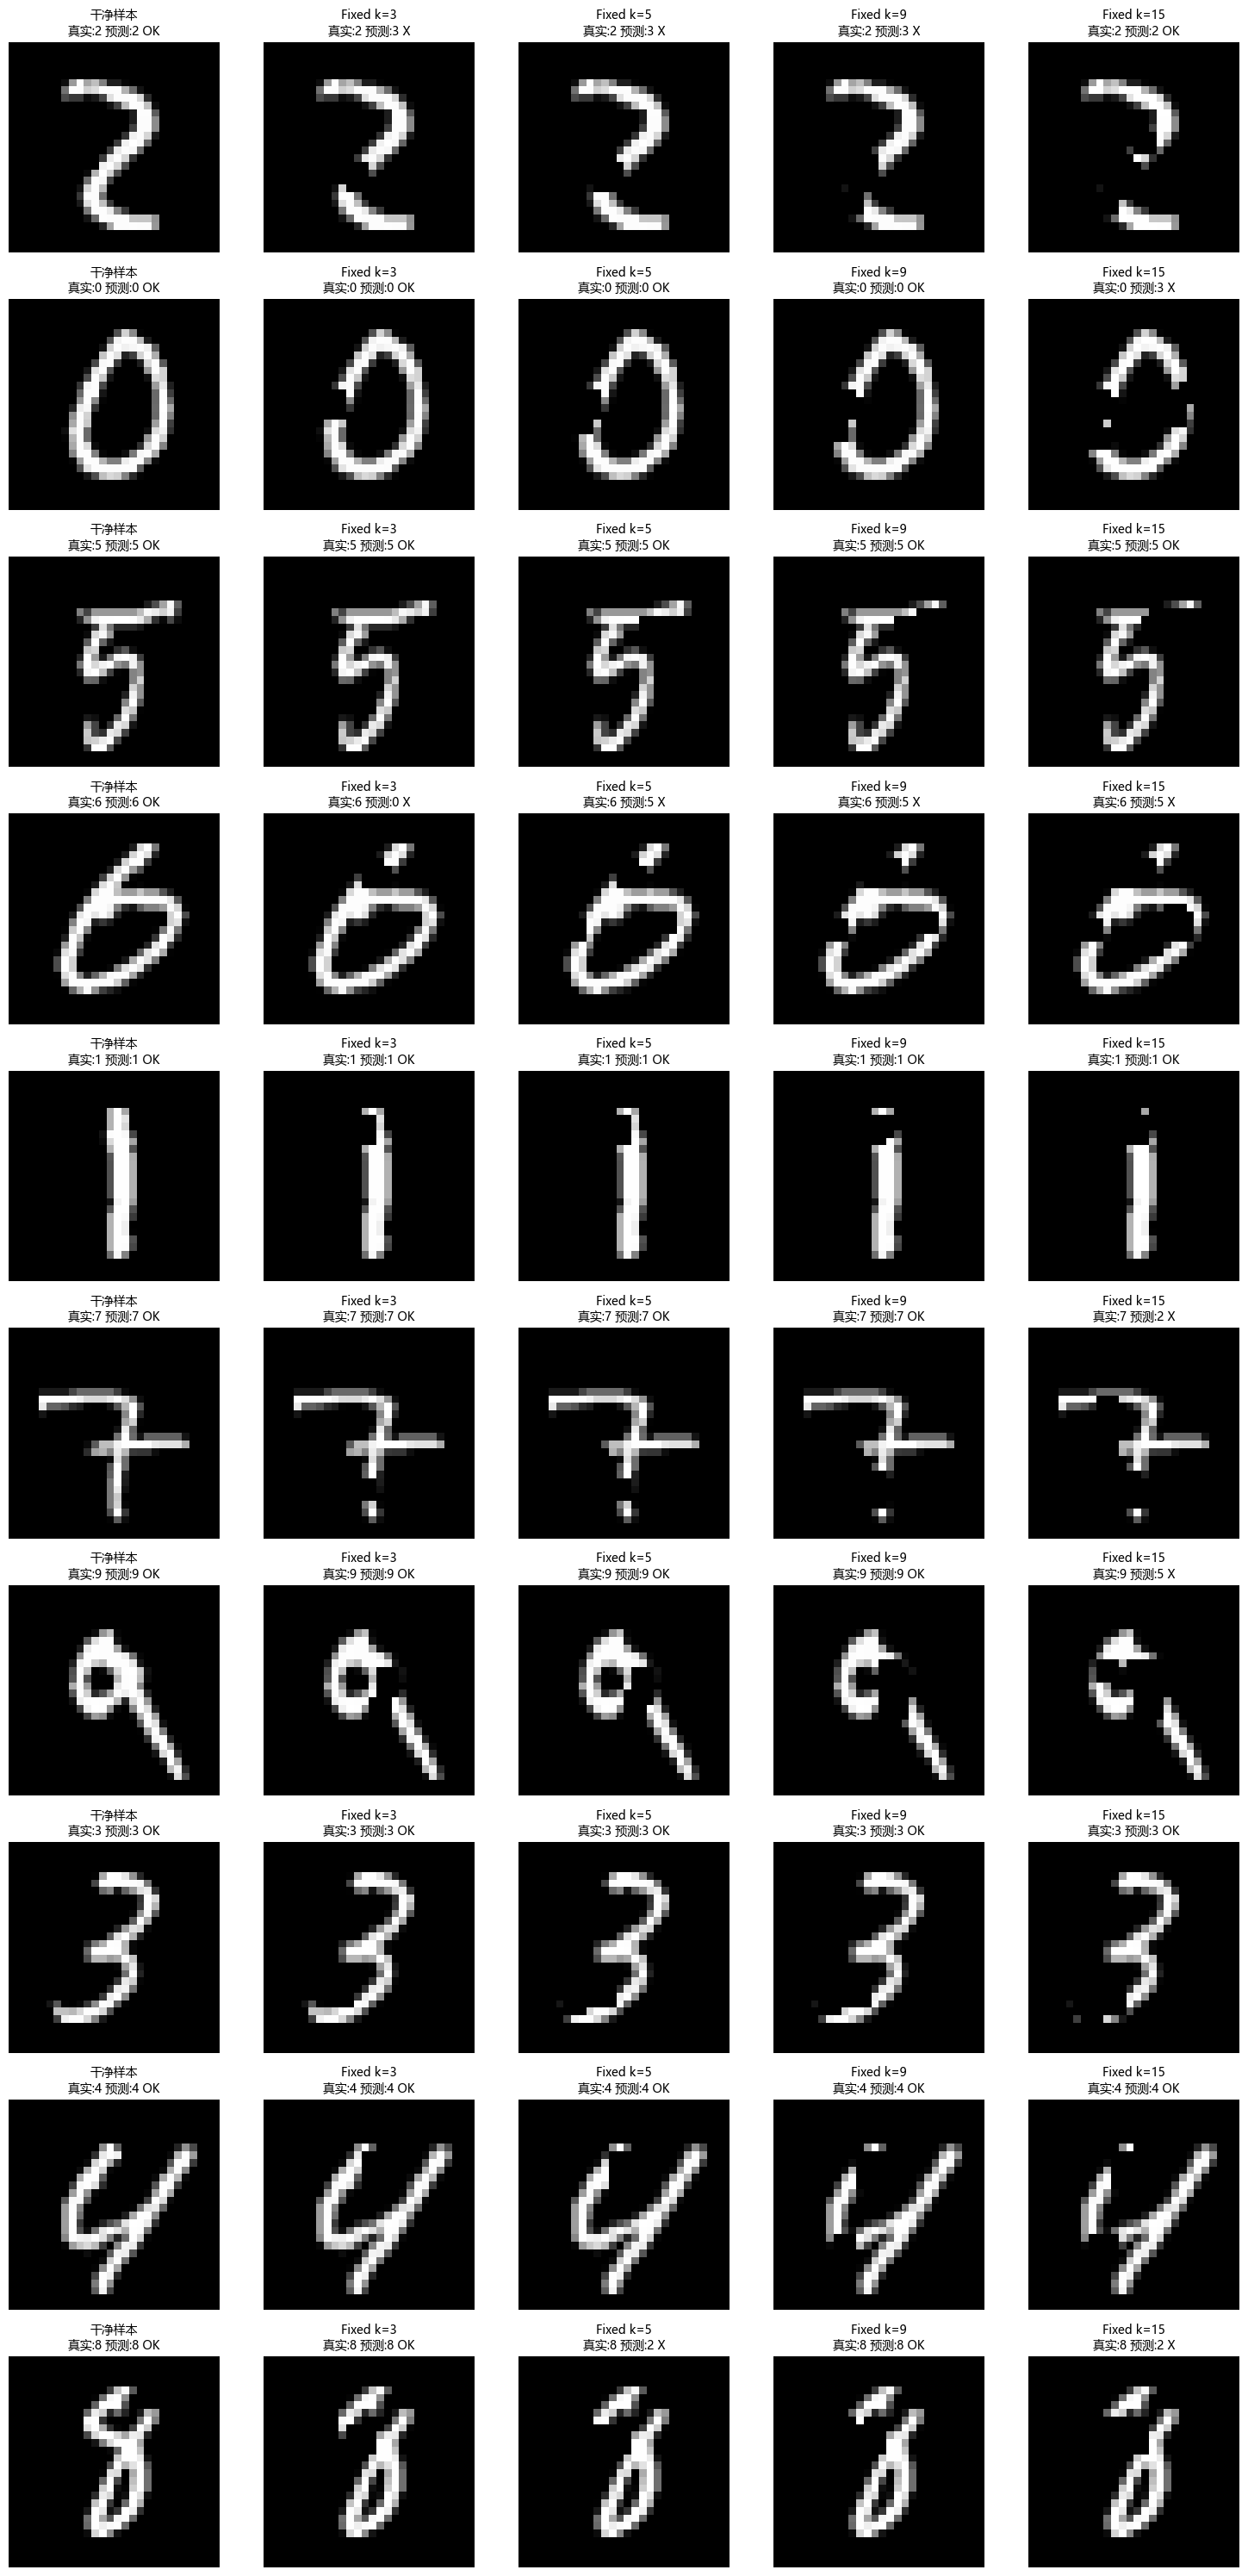

固定遮蔽攻击可视化已保存


In [9]:
# 可视化固定遮蔽攻击效果
fig, axes = plt.subplots(10, 5, figsize=(15, 30))
kernel_size_test=3
for row, idx in enumerate(sample_indices):
    x = imgs[idx:idx+1].to(device)
    y = lbls[idx:idx+1].to(device)
    true_label = int(y.item())
    
    # 干净样本
    imshow_with_pred(x.squeeze(0), std_lenet, true_label, ax=axes[row, 0], title_prefix='干净样本')
    
    # 不同top_k的遮蔽攻击
    for col, top_k in enumerate(top_k_values):
        attack = SaliencyOcclusionAttack(std_lenet, top_k=top_k, kernel_size=kernel_size_test, occlu_color=0.0)
        x_adv = attack((x, y))
        imshow_with_pred(x_adv.squeeze(0), std_lenet, true_label, 
                        ax=axes[row, col+1], title_prefix=f'Fixed k={top_k}')

plt.tight_layout()
plt.savefig(f'./results_figures/saliency_fixed_attack_visualization_{N}_{kernel_size_test}.png', dpi=150, bbox_inches='tight')
plt.show()
print('固定遮蔽攻击可视化已保存')


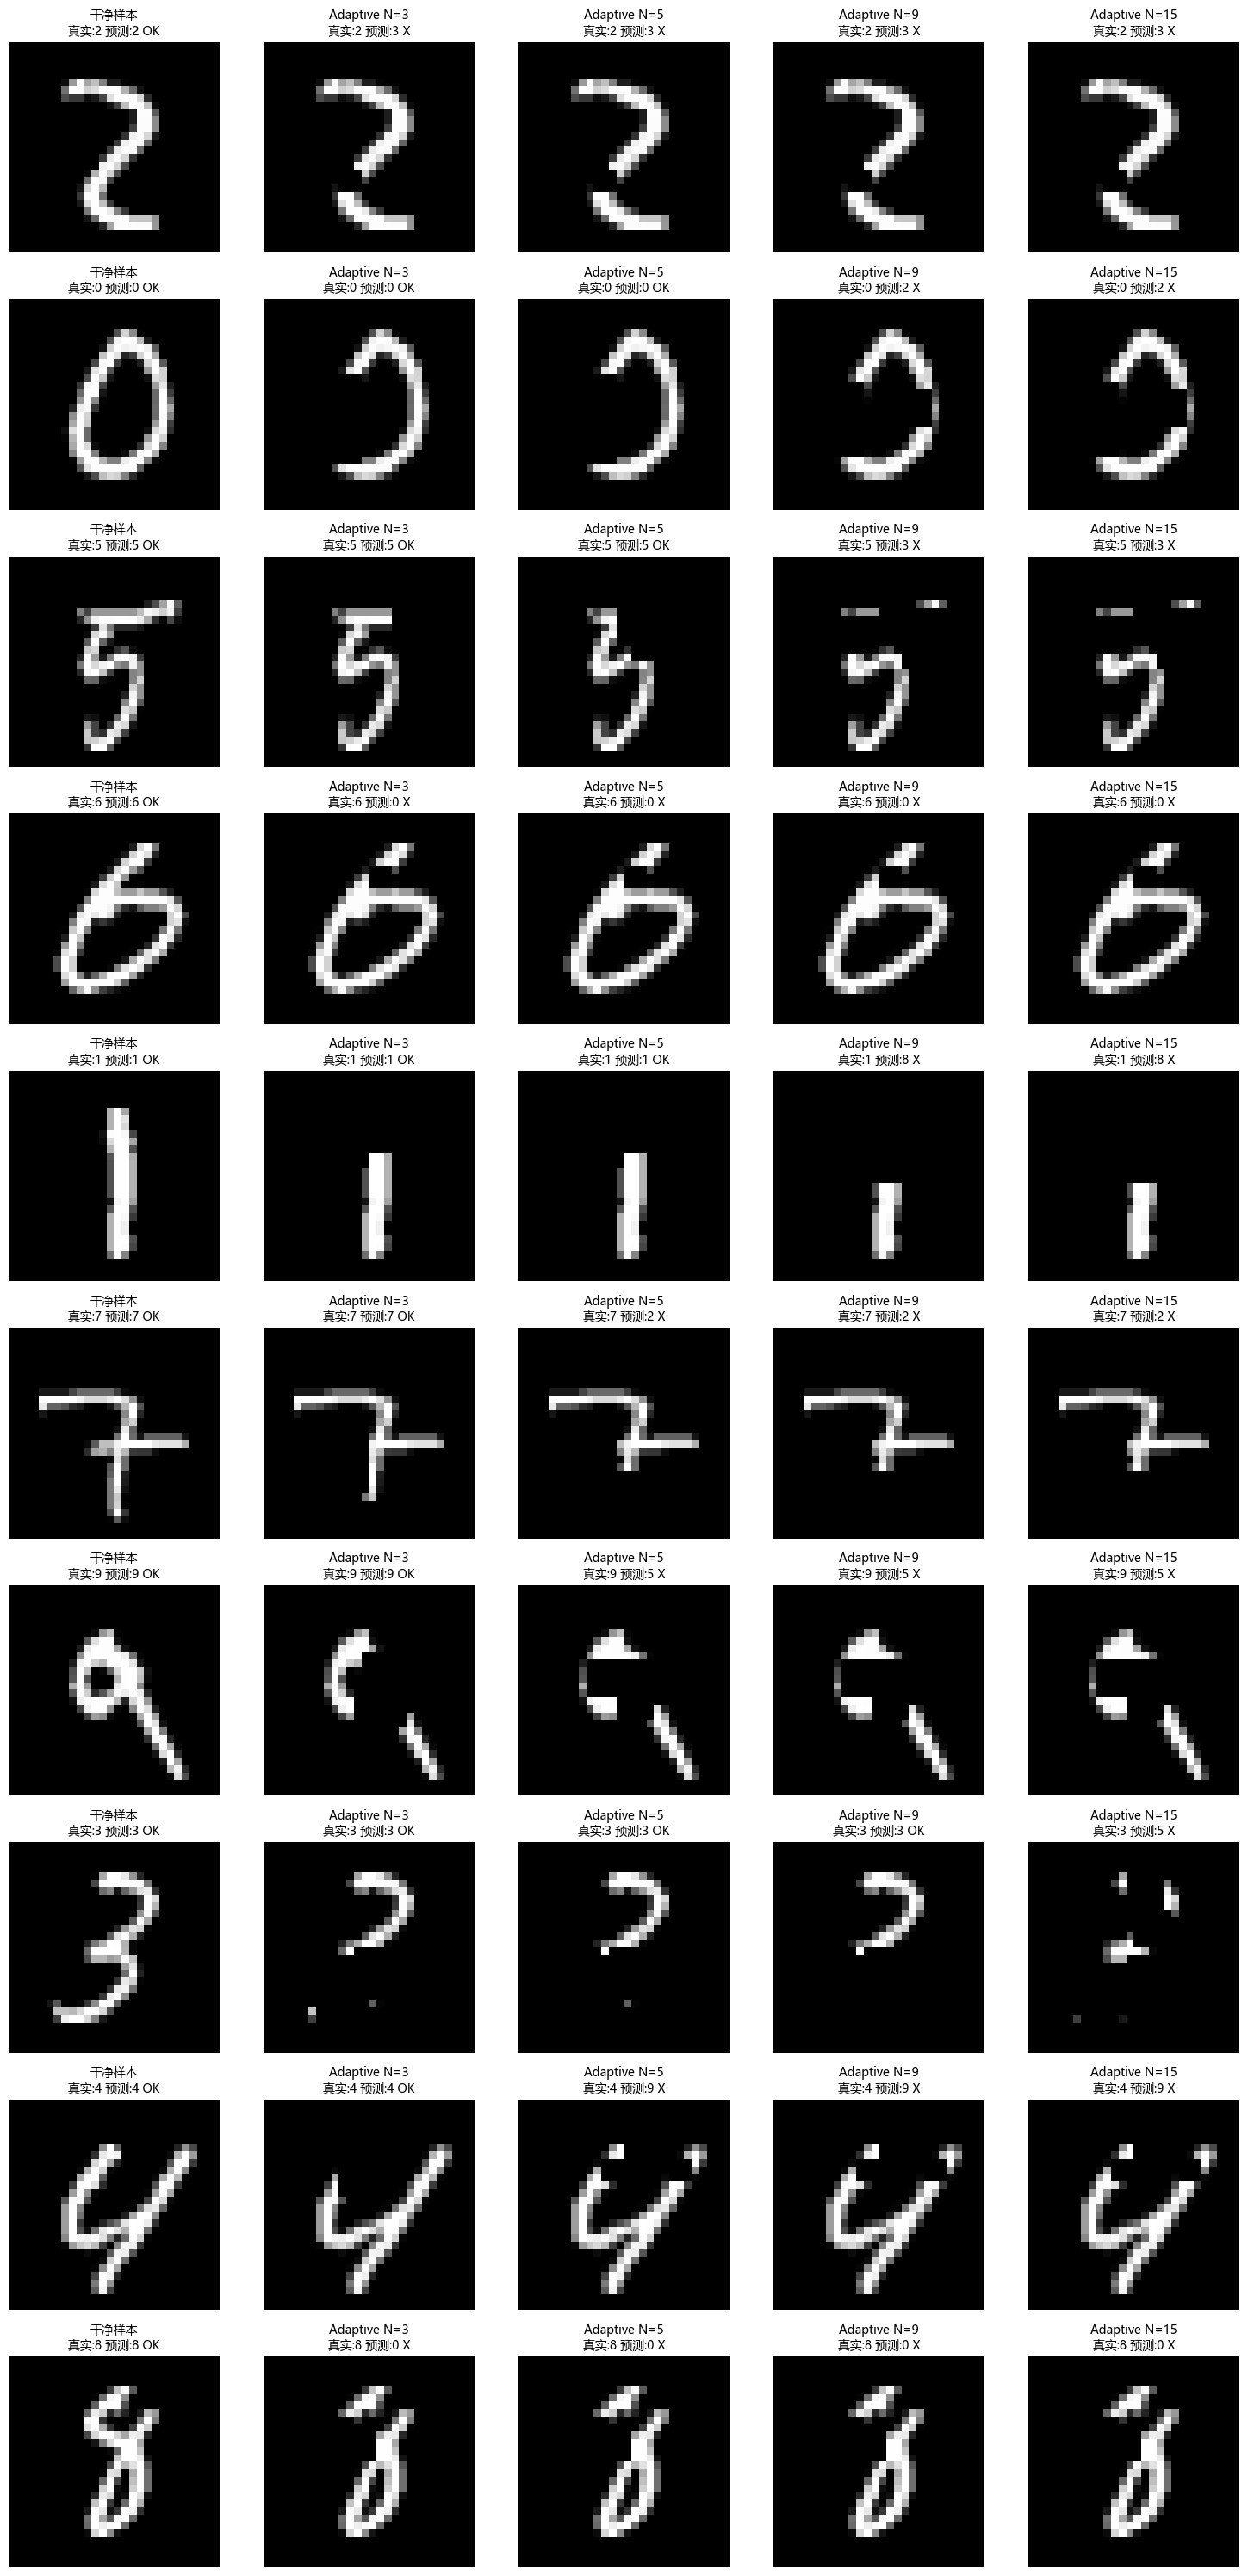

自适应遮蔽攻击可视化已保存


In [10]:
# 可视化自适应遮蔽攻击效果
fig, axes = plt.subplots(10, 5, figsize=(15, 30))

for row, idx in enumerate(sample_indices):
    x = imgs[idx:idx+1].to(device)
    y = lbls[idx:idx+1].to(device)
    true_label = int(y.item())
    
    # 干净样本
    imshow_with_pred(x.squeeze(0), std_lenet, true_label, ax=axes[row, 0], title_prefix='干净样本')
    
    # 不同N参数的自适应遮蔽攻击
    for col, N_val in enumerate([3, 5, 9, 15]):
        attack = AdaptiveSaliencyOcclusionAttack(std_lenet, N=N_val, R=3, c=0.0)
        x_adv = attack((x, y))
        imshow_with_pred(x_adv.squeeze(0), std_lenet, true_label, 
                        ax=axes[row, col+1], title_prefix=f'Adaptive N={N_val}')

plt.tight_layout()
plt.savefig(f'./results_figures/saliency_Adaptive_attack_visualization_R=3_{N}.png', dpi=150, bbox_inches='tight')
plt.show()
print('自适应遮蔽攻击可视化已保存')


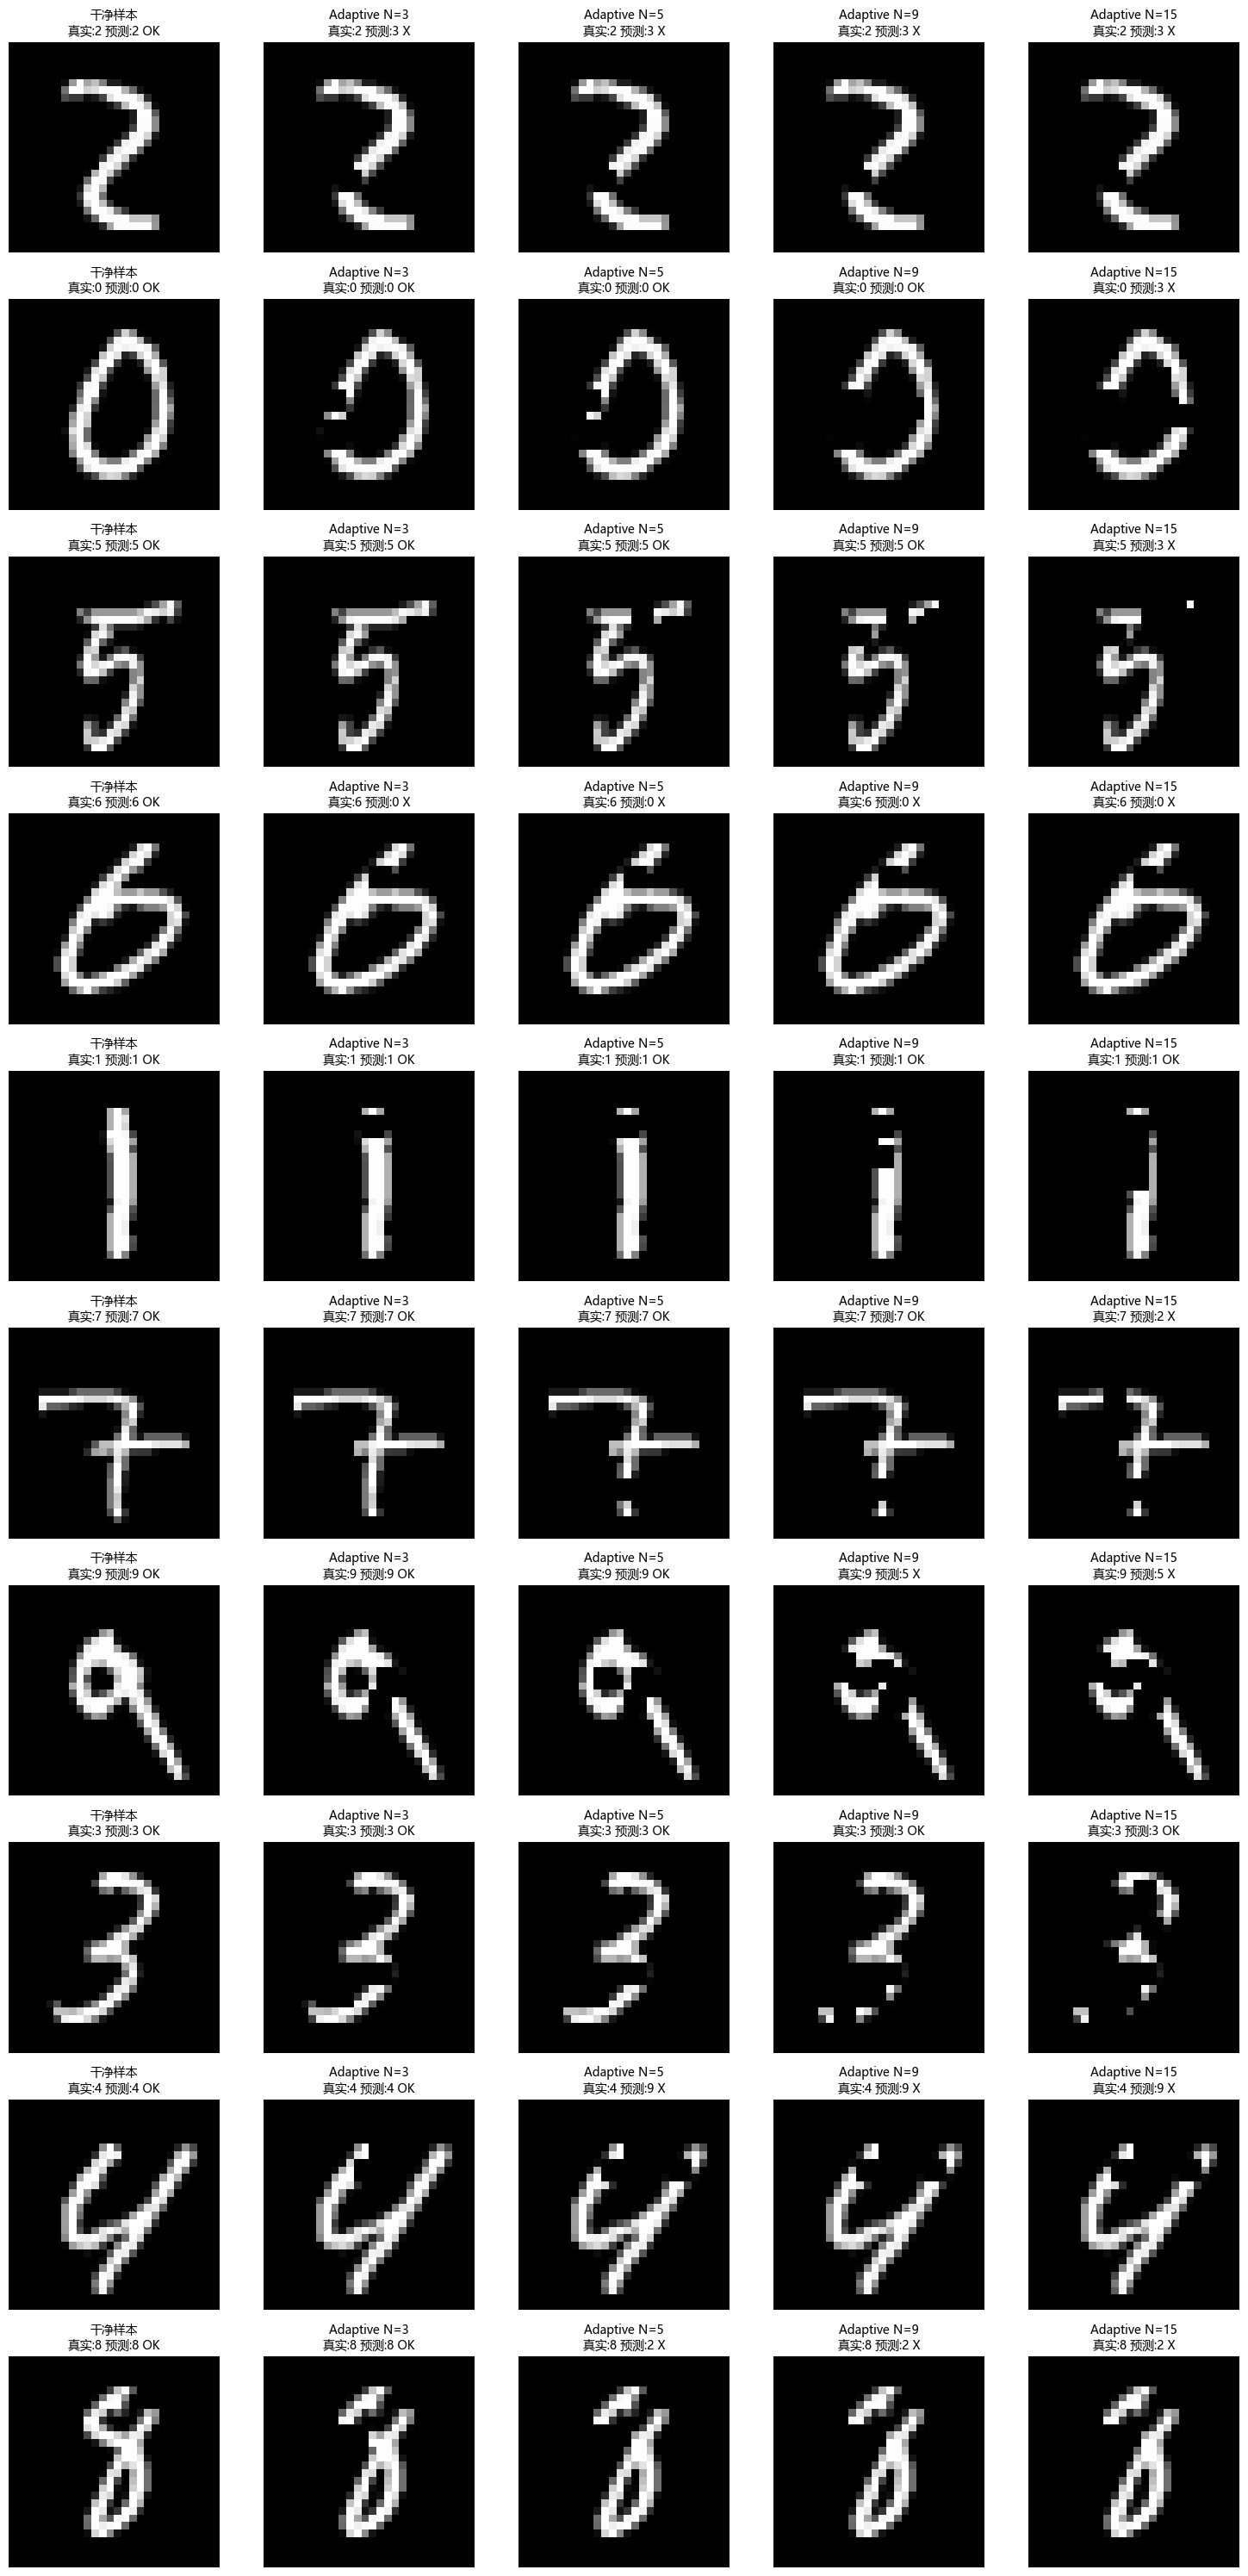

自适应遮蔽攻击可视化已保存


In [11]:
# 可视化自适应遮蔽攻击效果
fig, axes = plt.subplots(10, 5, figsize=(15, 30))

for row, idx in enumerate(sample_indices):
    x = imgs[idx:idx+1].to(device)
    y = lbls[idx:idx+1].to(device)
    true_label = int(y.item())
    
    # 干净样本
    imshow_with_pred(x.squeeze(0), std_lenet, true_label, ax=axes[row, 0], title_prefix='干净样本')
    
    # 不同N参数的自适应遮蔽攻击
    for col, N_val in enumerate([3, 5, 9, 15]):
        attack = AdaptiveSaliencyOcclusionAttack(std_lenet, N=N_val, R=1, c=0.0)
        x_adv = attack((x, y))
        imshow_with_pred(x_adv.squeeze(0), std_lenet, true_label, 
                        ax=axes[row, col+1], title_prefix=f'Adaptive N={N_val}')

plt.tight_layout()
plt.savefig(f'./results_figures/saliency_Adaptive_attack_visualization_R=1_{N}.png', dpi=150, bbox_inches='tight')
plt.show()
print('自适应遮蔽攻击可视化已保存')

## 15.3 基于自适应Saliency遮蔽攻击的对抗性训练

与固定遮蔽攻击对抗性训练不同，自适应遮蔽攻击：
1. 渐进式增加遮蔽区域数量和半径
2. 逐样本早停：一旦攻击成功（预测改变）即停止该样本的遮蔽
3. 使用最小遮蔽量，保留数字的语义可辨识性

In [6]:
# 超参数
EPOCH = 50
BATCH_SIZE = 256
LR = 0.001

# 自适应遮蔽攻击参数
N = 5              # 最大遮蔽区域数量
R = 1              # 最大遮蔽半径
C_COLOR = 0.0      # 黑色遮蔽

print(f'训练参数: EPOCH={EPOCH}, BATCH_SIZE={BATCH_SIZE}, LR={LR}')
print(f'自适应遮蔽参数: N={N}, R={R}, C_COLOR={C_COLOR}')

# 加载数据集
train_dataset = torchvision.datasets.MNIST(
    root="./data/", train=True, download=False, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(
    root="./data/", train=False, download=False, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f'训练集: {len(train_dataset)}, 测试集: {len(test_dataset)}')

训练参数: EPOCH=50, BATCH_SIZE=256, LR=0.001
自适应遮蔽参数: N=5, R=1, C_COLOR=0.0
训练集: 60000, 测试集: 10000


In [7]:
# 定义自适应Saliency遮蔽攻击对抗性训练模块
class AdaptiveSaliencyOcclusionAT(nn.Module):
    """基于自适应Saliency遮蔽攻击的对抗性训练
    
    与固定遮蔽攻击的区别：
    - 渐进式增加遮蔽区域数量(n=1..N)和遮蔽半径(r=1..R)
    - 逐样本早停：攻击成功即停止，使用最小遮蔽量
    """
    
    def __init__(self, model, N=5, R=3, c=0.0):
        super().__init__()
        self.model = model
        self.attack = AdaptiveSaliencyOcclusionAttack(model, N=N, R=R, c=c)
    
    def forward(self, x, y=None):
        if y is None:
            return self.model(x)
        
        # 生成对抗样本
        training = self.model.training
        self.model.eval()
        x_adv = self.attack((x, y))
        if training:
            self.model.train()
        
        return self.model(x_adv)

# 初始化模型
cnn = LeNet5().to(device)
cnn_at = AdaptiveSaliencyOcclusionAT(cnn, N=N, R=R, c=C_COLOR)

optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f'模型参数量: {num_params}')
print(f'使用自适应遮蔽攻击: N={N}, R={R}')

模型参数量: 61706
使用自适应遮蔽攻击: N=5, R=1


In [20]:
# 训练循环
train_accs, train_losses = [], []
test_accs, test_losses = [], []
test_clean_accs = []
best_acc = 0
best_state = None

for epoch in range(EPOCH):
    # 训练
    cnn_at.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCH}'):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = cnn_at(inputs, labels)
        loss = loss_fn(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred = outputs.argmax(dim=1)
        train_correct += (pred == labels).sum().item()
        train_total += n
        train_loss += loss.item() * n
    
    train_acc = train_correct / train_total
    train_loss_avg = train_loss / train_total
    train_accs.append(train_acc)
    train_losses.append(train_loss_avg)
    
    # 测试（对抗样本）
    cnn_at.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    test_clean_correct = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            n = labels.size(0)
            inputs, labels = inputs.to(device), labels.to(device)
            
            # 干净样本测试
            pred_clean = cnn(inputs).argmax(dim=1)
            test_clean_correct += (pred_clean == labels).sum().item()
            
            # 对抗样本测试
            outputs = cnn_at(inputs, labels)
            loss = loss_fn(outputs, labels)
            pred = outputs.argmax(dim=1)
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.item() * n
    
    test_acc = test_correct / test_total
    test_loss_avg = test_loss / test_total
    test_clean_acc = test_clean_correct / test_total
    
    test_accs.append(test_acc)
    test_losses.append(test_loss_avg)
    test_clean_accs.append(test_clean_acc)
    
    logger.info(f'Epoch {epoch+1}: Train Loss={train_loss_avg:.4f}, Train Acc={100*train_acc:.2f}%, '
                f'Test(Robust)={100*test_acc:.2f}%, Test(Clean)={100*test_clean_acc:.2f}%')
    
    # 保存最佳模型
    if test_acc > best_acc:
        best_acc = test_acc
        best_state = copy.deepcopy(cnn.state_dict())

# 加载最佳模型
if best_state is not None:
    cnn.load_state_dict(best_state)
    print(f'加载最佳模型，鲁棒准确率: {100*best_acc:.2f}%')

20260409 23:50:50 Epoch 1: Train Loss=0.0354, Train Acc=98.33%, Test(Robust)=97.28%, Test(Clean)=98.98%
20260409 23:51:34 Epoch 2: Train Loss=0.0356, Train Acc=98.30%, Test(Robust)=96.92%, Test(Clean)=98.76%
20260409 23:52:20 Epoch 3: Train Loss=0.0345, Train Acc=98.36%, Test(Robust)=97.11%, Test(Clean)=98.83%
20260409 23:53:05 Epoch 4: Train Loss=0.0346, Train Acc=98.32%, Test(Robust)=97.53%, Test(Clean)=98.86%
20260409 23:58:04 Epoch 11: Train Loss=0.0286, Train Acc=98.65%, Test(Robust)=97.58%, Test(Clean)=98.91%
20260409 23:58:46 Epoch 12: Train Loss=0.0279, Train Acc=98.72%, Test(Robust)=97.46%, Test(Clean)=99.00%
20260409 23:59:28 Epoch 13: Train Loss=0.0256, Train Acc=98.76%, Test(Robust)=97.30%, Test(Clean)=98.85%
20260410 00:00:11 Epoch 14: Train Loss=0.0256, Train Acc=98.76%, Test(Robust)=97.45%, Test(Clean)=98.84%
20260410 00:00:55 Epoch 15: Train Loss=0.0237, Train Acc=98.88%, Test(Robust)=97.45%, Test(Clean)=98.86%
20260410 00:01:38 Epoch 16: Train Loss=0.0242, Train Acc=98

加载最佳模型，鲁棒准确率: 97.80%


In [21]:
# 保存模型
state = {
    'net': cnn.state_dict(),
    'epoch': EPOCH,
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs,
    'test_clean_accs': test_clean_accs,
    'params': {'N': N, 'R': R, 'c': C_COLOR}
}

save_dir = f'./save_model/{EPOCH}epoch'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f'mnist_lenet5_AdaptiveSaliencyOcclusionAT_{N}_{R}.pth')
torch.save(state, save_path)
print(f'模型已保存: {save_path}')

模型已保存: ./save_model/50epoch\mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_1.pth


训练曲线数据已保存: ./results_figures/adaptive_saliency_at_training_history_5_1.csv


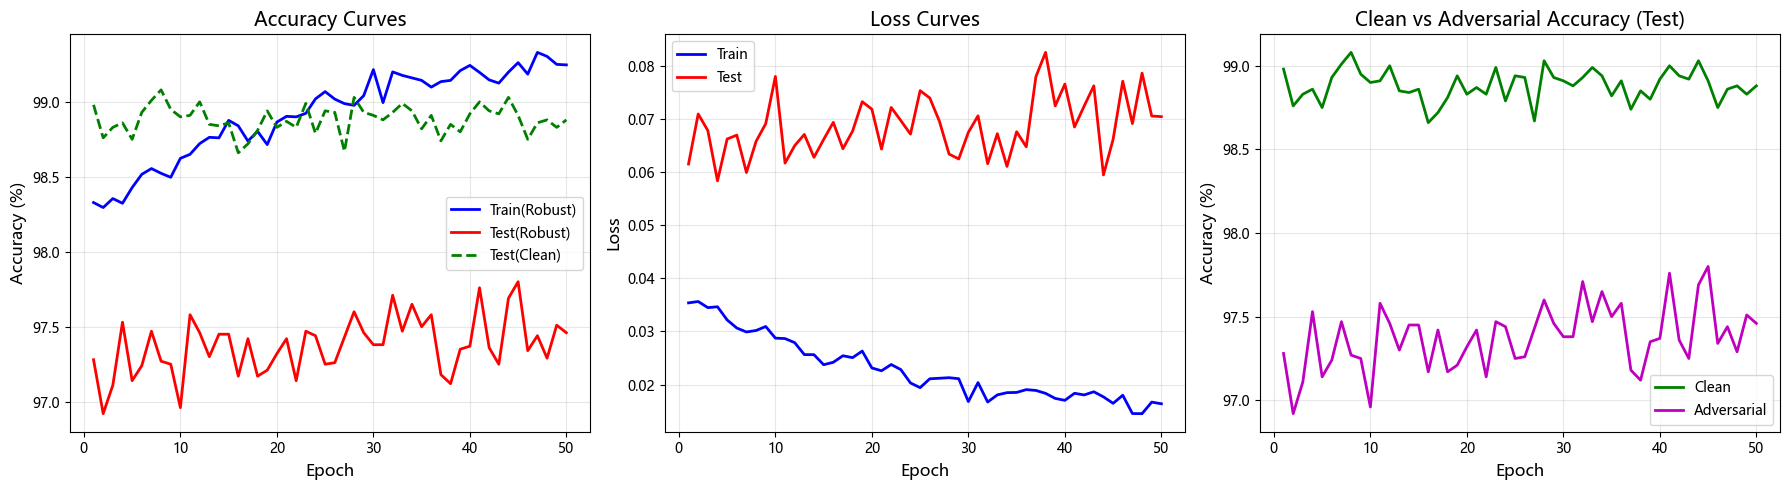

训练完成: 最终测试准确率 - 干净=98.88%, 对抗=97.46%


In [22]:
# 保存训练曲线数据到CSV
df_training_history = pd.DataFrame({
    'epoch': list(range(1, EPOCH+1)),
    'train_loss': train_losses,
    'train_acc': [100*a for a in train_accs],
    'test_loss': test_losses,
    'test_acc': [100*a for a in test_accs],
    'test_clean_acc': [100*a for a in test_clean_accs]
})
csv_path = f'./results_figures/adaptive_saliency_at_training_history_{N}_{R}.csv'
df_training_history.to_csv(csv_path, index=False)
print(f'训练曲线数据已保存: {csv_path}')

# 绘制训练曲线
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = list(range(1, EPOCH+1))

# 准确率曲线
axes[0].plot(epochs, [100*a for a in train_accs], 'b-', label='Train(Robust)', linewidth=2)
axes[0].plot(epochs, [100*a for a in test_accs], 'r-', label='Test(Robust)', linewidth=2)
axes[0].plot(epochs, [100*a for a in test_clean_accs], 'g--', label='Test(Clean)', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Accuracy Curves', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 损失曲线
axes[1].plot(epochs, train_losses, 'b-', label='Train', linewidth=2)
axes[1].plot(epochs, test_losses, 'r-', label='Test', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss Curves', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 干净 vs 对抗准确率
axes[2].plot(epochs, [100*a for a in test_clean_accs], 'g-', label='Clean', linewidth=2)
axes[2].plot(epochs, [100*a for a in test_accs], 'm-', label='Adversarial', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Accuracy (%)', fontsize=12)
axes[2].set_title('Clean vs Adversarial Accuracy (Test)', fontsize=14)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'./results_figures/saliency_at_training_curves_{N}_{R}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'训练完成: 最终测试准确率 - 干净={100*test_clean_accs[-1]:.2f}%, 对抗={100*test_accs[-1]:.2f}%')

加载 checkpoint: ./save_model/50epoch/mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_1.pth
训练轮数: 50 epochs
最终训练准确率: 0.99%
最终测试准确率: 0.97%


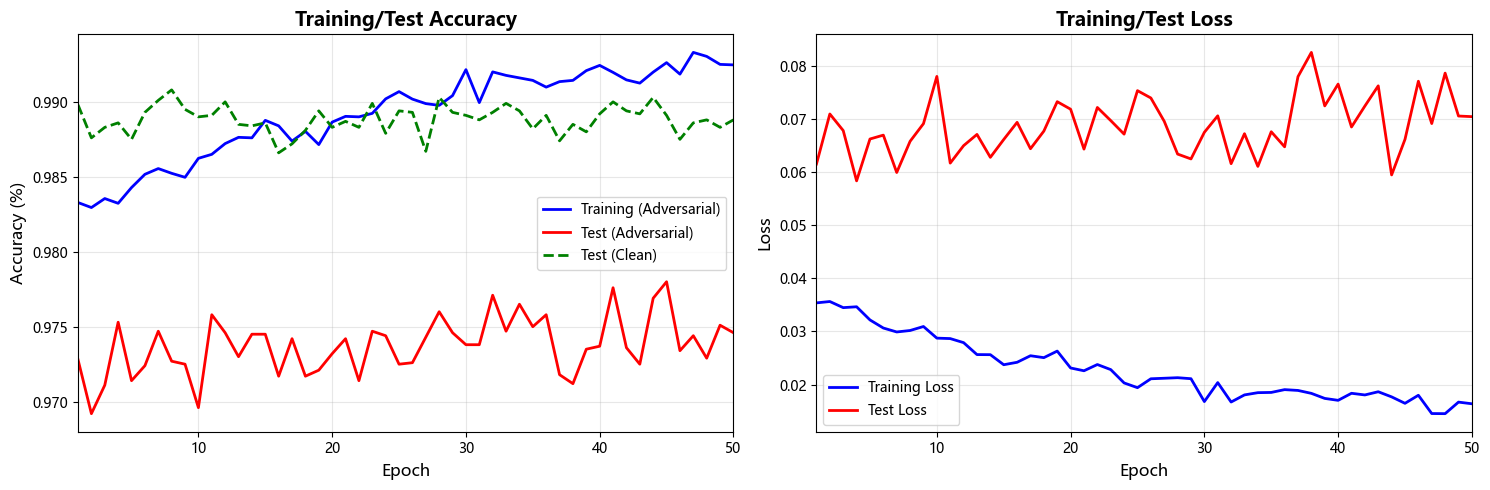

[SAVED] 训练曲线已保存: ./results_figures/training_curve_AdaptiveSaliencyAT_5_1.png
训练参数:
  N: 5
  R: 1
  c: 0.0


In [10]:
# ========== 训练曲线可视化（修复版 - 从checkpoint加载历史数据） ==========
"""
从checkpoint中加载训练历史数据并绘制训练曲线
内核重启后也可直接运行
"""

import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1.代码')

import torch
import matplotlib.pyplot as plt
from models import LeNet5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 加载模型和训练历史
checkpoint_path = './save_model/50epoch/mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_1.pth'

print(f'加载 checkpoint: {checkpoint_path}')
test_state = torch.load(checkpoint_path, map_location=device, weights_only=False)

# 加载模型
test_model = LeNet5().to(device)
test_model.load_state_dict(test_state['net'])
test_model.eval()

# 从 checkpoint 加载训练历史数据
train_accs = test_state.get('train_accs', [])
test_accs = test_state.get('test_accs', [])
train_losses = test_state.get('train_losses', [])
test_losses = test_state.get('test_losses', [])
test_clean_accs = test_state.get('test_clean_accs', [])

print(f'训练轮数: {len(train_accs)} epochs')
print(f'最终训练准确率: {train_accs[-1]:.2f}%' if train_accs else 'N/A')
print(f'最终测试准确率: {test_accs[-1]:.2f}%' if test_accs else 'N/A')

# 绘制训练曲线
plt.figure(figsize=(15, 5))

# 准确率曲线
plt.subplot(1, 2, 1)
epochs = list(range(1, len(train_accs) + 1))
plt.plot(epochs, train_accs, 'b-', linewidth=2, label='Training (Adversarial)')
plt.plot(epochs, test_accs, 'r-', linewidth=2, label='Test (Adversarial)')
if test_clean_accs:
    plt.plot(epochs, test_clean_accs, 'g--', linewidth=2, label='Test (Clean)')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Training/Test Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(1, len(train_accs))

# 损失曲线
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, 'b-', linewidth=2, label='Training Loss')
plt.plot(epochs, test_losses, 'r-', linewidth=2, label='Test Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training/Test Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(1, len(train_losses))

plt.tight_layout()
plt.savefig('./results_figures/training_curve_AdaptiveSaliencyAT_5_1.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] 训练曲线已保存: ./results_figures/training_curve_AdaptiveSaliencyAT_5_1.png')

# 打印训练参数
if 'params' in test_state:
    print('训练参数:')
    params = test_state['params']
    for k, v in params.items():
        print(f'  {k}: {v}')

## 15.4 鲁棒性评测

对训练好的模型进行多角度评测，包括：
1. 不同参数的固定遮蔽攻击
2. 不同参数的自适应遮蔽攻击

In [11]:
# 加载测试集
imgs, lbls = load_mnist_test()

# 干净样本准确率
test_model.eval()
clean_acc, clean_preds = test_fn(test_model, imgs, lbls, bs=250, mode='clean')
logger.info(f'Saliency-AT模型 - 干净样本准确率: {clean_acc:.2f}%')

20260411 16:46:37 Saliency-AT模型 - 干净样本准确率: 98.91%


### 15.4.1 自适应遮蔽攻击评测（不同N和R）

In [11]:
# 测试不同N和R参数组合
N_test = [3, 5, 7, 10]
R_test = [2, 3, 4]
adaptive_eval_results = []
cnn=test_model
# 测试不同N（固定R=3）
for N_val in N_test:
    attack = AdaptiveSaliencyOcclusionAttack(cnn, N=N_val, R=3, c=0.0)
    acc, preds = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    adaptive_eval_results.append({
        'attack': 'Adaptive',
        'param': f'N={N_val},R=3',
        'N': N_val,
        'R': 3,
        'accuracy': acc
    })
    logger.info(f'Adaptive遮蔽攻击 (N={N_val}, R=3): {acc:.2f}%')

# 测试不同R（固定N=5）
for R_val in R_test:
    attack = AdaptiveSaliencyOcclusionAttack(cnn, N=5, R=R_val, c=0.0)
    acc, preds = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    adaptive_eval_results.append({
        'attack': 'Adaptive',
        'param': f'N=5,R={R_val}',
        'N': 5,
        'R': R_val,
        'accuracy': acc
    })
    logger.info(f'Adaptive遮蔽攻击 (N=5, R={R_val}): {acc:.2f}%')

20260411 15:20:43 Adaptive遮蔽攻击 (N=3, R=3): 85.22%
20260411 15:21:01 Adaptive遮蔽攻击 (N=5, R=3): 72.59%
20260411 15:21:25 Adaptive遮蔽攻击 (N=7, R=3): 61.29%
20260411 15:21:59 Adaptive遮蔽攻击 (N=10, R=3): 46.49%
20260411 15:22:12 Adaptive遮蔽攻击 (N=5, R=2): 91.02%
20260411 15:22:29 Adaptive遮蔽攻击 (N=5, R=3): 72.59%
20260411 15:22:53 Adaptive遮蔽攻击 (N=5, R=4): 51.03%


### 15.4.2 固定遮蔽攻击评测（不同top_k）

作为对比，也测试固定遮蔽攻击的效果。

In [ ]:
# 测试不同top_k（固定攻击，作为对比）
top_k_test = [3, 5, 7, 9, 12, 15]
fixed_eval_results = []

for top_k in top_k_test:
    attack = SaliencyOcclusionAttack(cnn, top_k=top_k, kernel_size=3, occlu_color=0.0)
    acc, preds = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    fixed_eval_results.append({
        'attack': 'Fixed',
        'param': f'top_k={top_k}',
        'top_k': top_k,
        'accuracy': acc
    })
    logger.info(f'Fixed遮蔽攻击 (top_k={top_k}): {acc:.2f}%')

20260410 00:33:49 Fixed遮蔽攻击 (top_k=3): 98.71%
20260410 00:34:06 Fixed遮蔽攻击 (top_k=5): 98.41%
20260410 00:34:29 Fixed遮蔽攻击 (top_k=7): 98.35%
20260410 00:34:59 Fixed遮蔽攻击 (top_k=9): 97.95%
20260410 00:35:38 Fixed遮蔽攻击 (top_k=12): 97.48%
20260410 00:36:28 Fixed遮蔽攻击 (top_k=15): 96.75%


### 15.4.3 不同遮蔽颜色评测

In [ ]:
# 测试不同遮蔽颜色（使用Adaptive攻击）
colors = [0.0, 0.5, 1.0]
color_names = ['黑色', '灰色', '白色']
color_eval_results = []

for c, name in zip(colors, color_names):
    attack = AdaptiveSaliencyOcclusionAttack(cnn, N=5, R=3, c=c)
    acc, preds = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    color_eval_results.append({
        'attack': 'Adaptive',
        'param': f'color={name}',
        'accuracy': acc
    })
    logger.info(f'Adaptive遮蔽攻击 (颜色={name}): {acc:.2f}%')

20260410 00:36:45 Adaptive遮蔽攻击 (颜色=黑色): 72.59%
20260410 00:36:59 Adaptive遮蔽攻击 (颜色=灰色): 50.98%
20260410 00:37:13 Adaptive遮蔽攻击 (颜色=白色): 19.93%


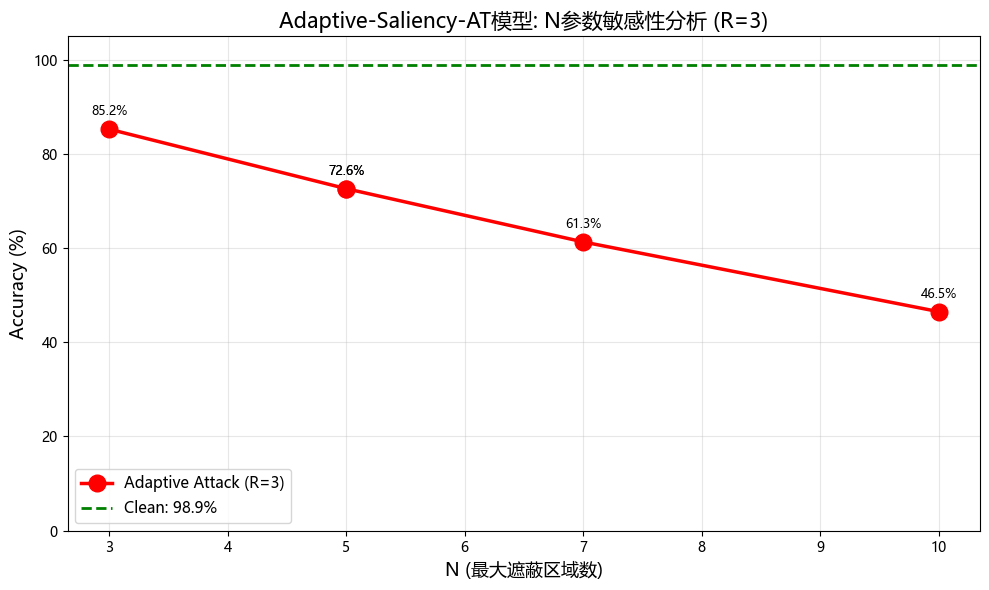

图1已保存: ./results_figures/eval_adaptive_n_param_5_1.png


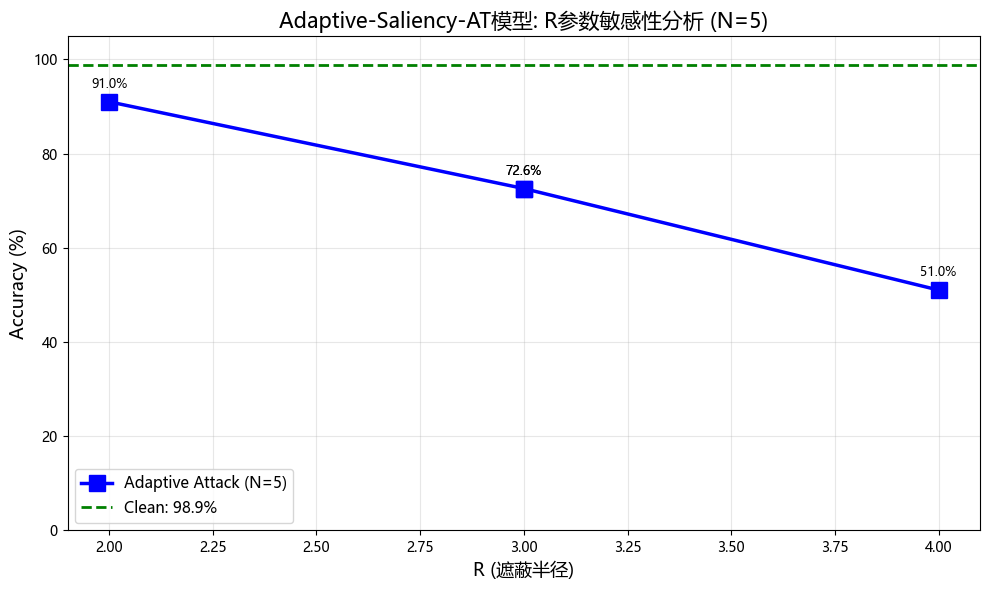

图2已保存: ./results_figures/eval_adaptive_r_param_5_1.png


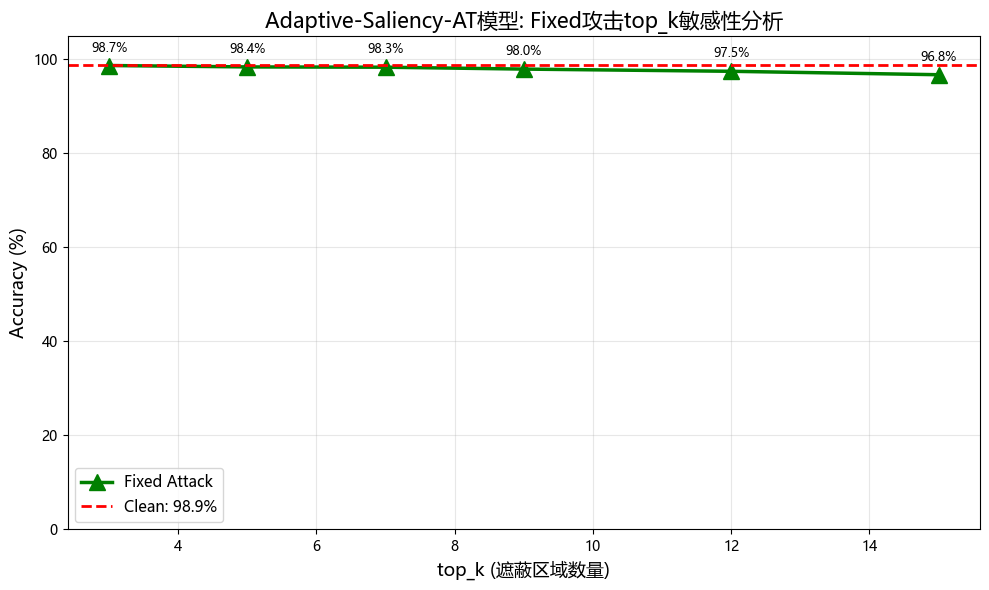

图3已保存: ./results_figures/eval_fixed_topk_param_5_1.png


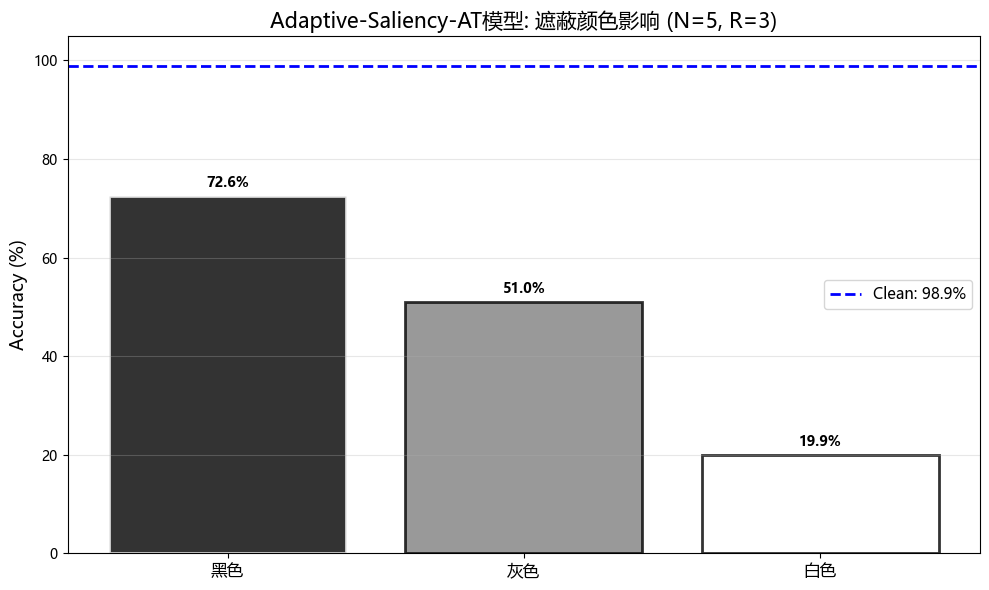

图4已保存: ./results_figures/eval_color_param_5_1.png


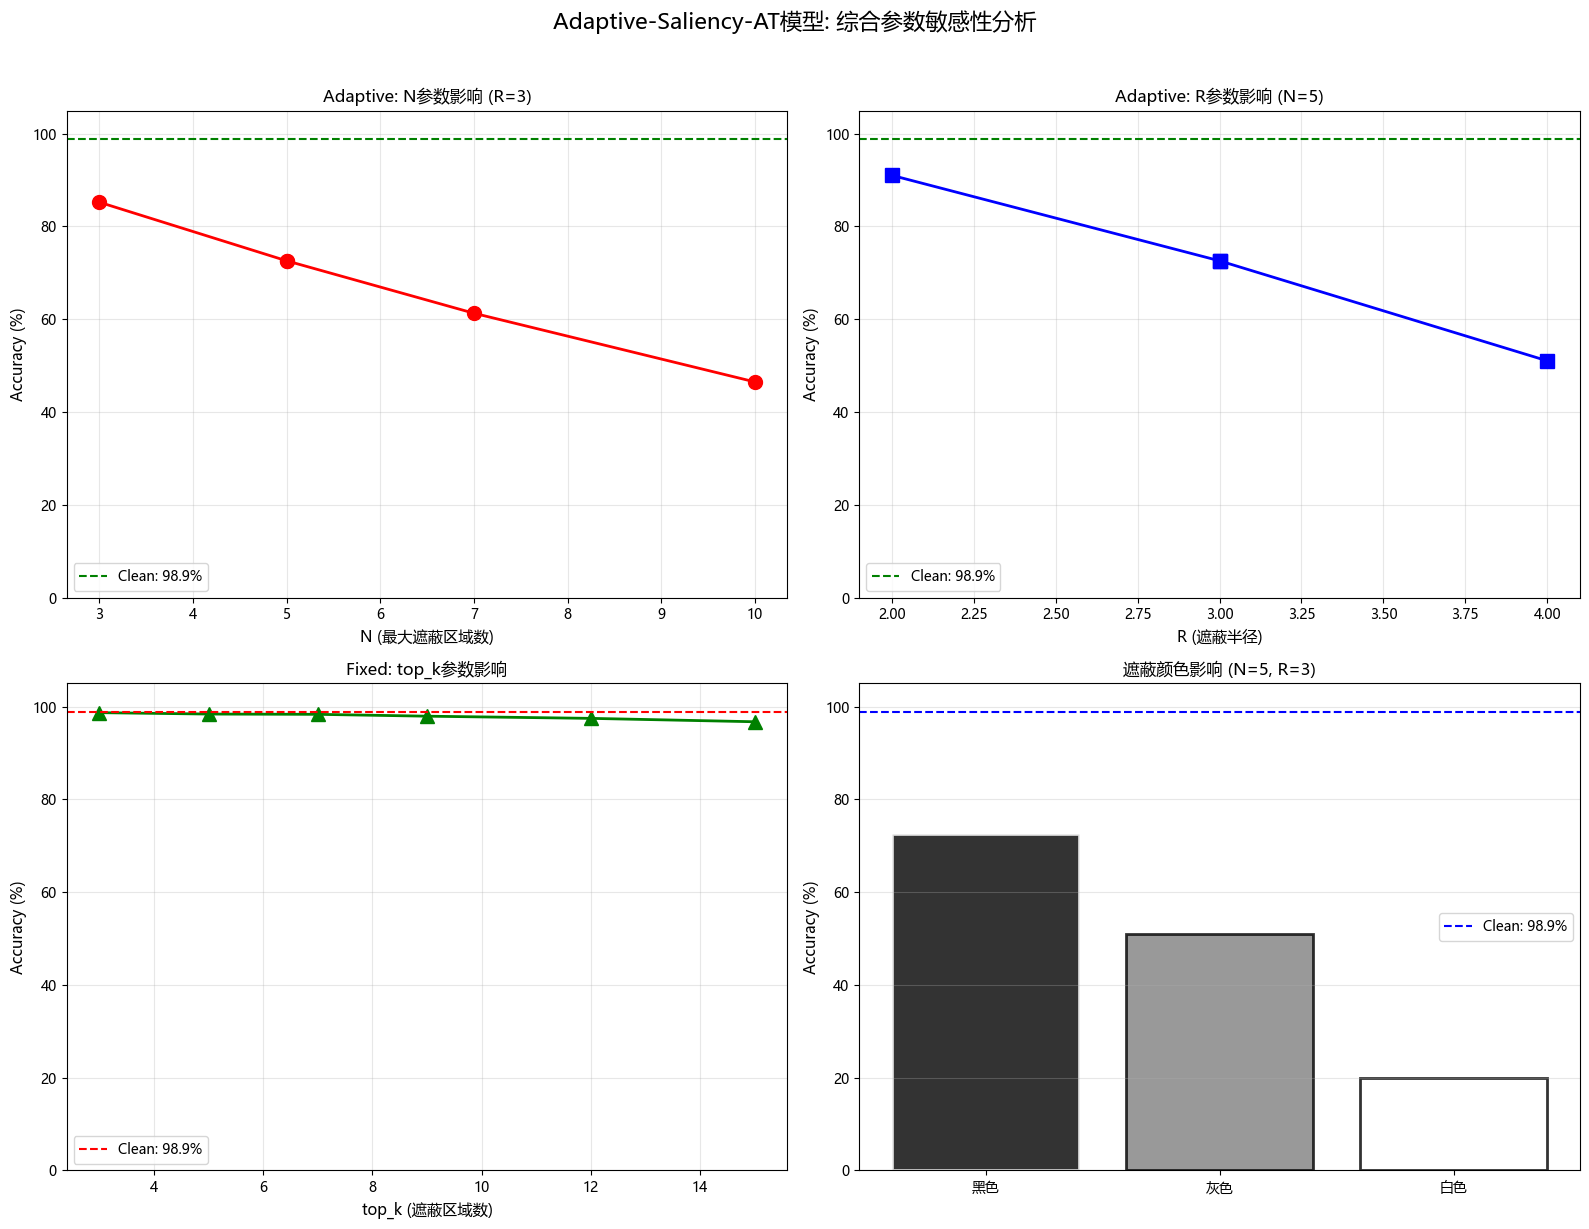

图5已保存: ./results_figures/eval_comprehensive_analysis_5_1.png

========== 评测可视化完成 ==========
共生成5张图表，保存在 ./results_figures/
同时保存了对应的CSV数据文件


In [ ]:
# ========== 自适应Saliency-AT模型评测结果可视化 ==========
"""
为每个评测维度绘制可视化图表：
1. Adaptive攻击 - 不同N参数（固定R=3）
2. Adaptive攻击 - 不同R参数（固定N=5）
3. Fixed攻击 - 不同top_k参数
4. 不同遮蔽颜色
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 确保结果目录存在
os.makedirs('./results_figures', exist_ok=True)

# 创建综合评测结果DataFrame
summary_data = []

# 1. Adaptive攻击 - N参数（固定R=3）
n_results = [r for r in adaptive_eval_results if r['R'] == 3]
n_results_sorted = sorted(n_results, key=lambda x: x['N'])

# 2. Adaptive攻击 - R参数（固定N=5）
r_results = [r for r in adaptive_eval_results if r['N'] == 5]
r_results_sorted = sorted(r_results, key=lambda x: x['R'])

# 3. Fixed攻击 - top_k
fixed_results_sorted = sorted(fixed_eval_results, key=lambda x: x['top_k'])

# ========== 图1: Adaptive攻击 - N参数影响（折线图） ==========
fig1, ax1 = plt.subplots(figsize=(10, 6))

N_vals = [r['N'] for r in n_results_sorted]
acc_vals_n = [r['accuracy'] for r in n_results_sorted]

ax1.plot(N_vals, acc_vals_n, 'ro-', markersize=12, linewidth=2.5, label='Adaptive Attack (R=3)')
ax1.axhline(y=clean_acc, color='g', linestyle='--', linewidth=2, label=f'Clean: {clean_acc:.1f}%')
ax1.set_xlabel('N (最大遮蔽区域数)', fontsize=13)
ax1.set_ylabel('Accuracy (%)', fontsize=13)
ax1.set_title('Adaptive-Saliency-AT模型: N参数敏感性分析 (R=3)', fontsize=15)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 105)

# 添加数值标签
for x, y in zip(N_vals, acc_vals_n):
    ax1.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
save_path1 = f'./results_figures/eval_adaptive_n_param_{N}_{R}.png'
plt.savefig(save_path1, dpi=150, bbox_inches='tight')
plt.show()
print(f'图1已保存: {save_path1}')

# 保存CSV
df_n = pd.DataFrame([{'N': r['N'], 'R': 3, 'Accuracy': r['accuracy']} for r in n_results_sorted])
df_n.to_csv(f'./results_figures/eval_adaptive_n_param_{N}_{R}.csv', index=False)

# ========== 图2: Adaptive攻击 - R参数影响（折线图） ==========
fig2, ax2 = plt.subplots(figsize=(10, 6))

R_vals = [r['R'] for r in r_results_sorted]
acc_vals_r = [r['accuracy'] for r in r_results_sorted]

ax2.plot(R_vals, acc_vals_r, 'bs-', markersize=12, linewidth=2.5, label='Adaptive Attack (N=5)')
ax2.axhline(y=clean_acc, color='g', linestyle='--', linewidth=2, label=f'Clean: {clean_acc:.1f}%')
ax2.set_xlabel('R (遮蔽半径)', fontsize=13)
ax2.set_ylabel('Accuracy (%)', fontsize=13)
ax2.set_title('Adaptive-Saliency-AT模型: R参数敏感性分析 (N=5)', fontsize=15)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)

# 添加数值标签
for x, y in zip(R_vals, acc_vals_r):
    ax2.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
save_path2 = f'./results_figures/eval_adaptive_r_param_{N}_{R}.png'
plt.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'图2已保存: {save_path2}')

# 保存CSV
df_r = pd.DataFrame([{'N': 5, 'R': r['R'], 'Accuracy': r['accuracy']} for r in r_results_sorted])
df_r.to_csv(f'./results_figures/eval_adaptive_r_param_{N}_{R}.csv', index=False)

# ========== 图3: Fixed攻击 - top_k影响（折线图） ==========
fig3, ax3 = plt.subplots(figsize=(10, 6))

top_k_vals = [r['top_k'] for r in fixed_results_sorted]
acc_vals_fixed = [r['accuracy'] for r in fixed_results_sorted]

ax3.plot(top_k_vals, acc_vals_fixed, 'g^-', markersize=12, linewidth=2.5, label='Fixed Attack')
ax3.axhline(y=clean_acc, color='r', linestyle='--', linewidth=2, label=f'Clean: {clean_acc:.1f}%')
ax3.set_xlabel('top_k (遮蔽区域数量)', fontsize=13)
ax3.set_ylabel('Accuracy (%)', fontsize=13)
ax3.set_title('Adaptive-Saliency-AT模型: Fixed攻击top_k敏感性分析', fontsize=15)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 105)

# 添加数值标签
for x, y in zip(top_k_vals, acc_vals_fixed):
    ax3.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
save_path3 = f'./results_figures/eval_fixed_topk_param_{N}_{R}.png'
plt.savefig(save_path3, dpi=150, bbox_inches='tight')
plt.show()
print(f'图3已保存: {save_path3}')

# 保存CSV
df_fixed = pd.DataFrame([{'top_k': r['top_k'], 'Accuracy': r['accuracy']} for r in fixed_results_sorted])
df_fixed.to_csv(f'./results_figures/eval_fixed_topk_param_{N}_{R}.csv', index=False)

# ========== 图4: 遮蔽颜色影响（柱状图） ==========
fig4, ax4 = plt.subplots(figsize=(10, 6))

color_labels = [r['param'].replace('color=', '') for r in color_eval_results]
color_accs = [r['accuracy'] for r in color_eval_results]
bar_colors = ['black', 'gray', 'white']
edge_colors = ['white', 'black', 'black']

bars = ax4.bar(range(len(color_labels)), color_accs,
               color=bar_colors, edgecolor=edge_colors, linewidth=2, alpha=0.8)
ax4.set_xticks(range(len(color_labels)))
ax4.set_xticklabels(color_labels, fontsize=12)
ax4.set_ylabel('Accuracy (%)', fontsize=13)
ax4.set_title('Adaptive-Saliency-AT模型: 遮蔽颜色影响 (N=5, R=3)', fontsize=15)
ax4.axhline(y=clean_acc, color='blue', linestyle='--', linewidth=2, label=f'Clean: {clean_acc:.1f}%')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(0, 105)

# 添加数值标签
for bar, val in zip(bars, color_accs):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
save_path4 = f'./results_figures/eval_color_param_{N}_{R}.png'
plt.savefig(save_path4, dpi=150, bbox_inches='tight')
plt.show()
print(f'图4已保存: {save_path4}')

# 保存CSV
df_color = pd.DataFrame([{'Color': r['param'].replace('color=', ''), 'Accuracy': r['accuracy']} for r in color_eval_results])
df_color.to_csv(f'./results_figures/eval_color_param_{N}_{R}.csv', index=False)

# ========== 图5: 综合对比（子图） ==========
fig5, axes = plt.subplots(2, 2, figsize=(16, 12))

# (0,0) N参数
axes[0,0].plot(N_vals, acc_vals_n, 'ro-', markersize=10, linewidth=2)
axes[0,0].axhline(y=clean_acc, color='g', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[0,0].set_xlabel('N (最大遮蔽区域数)', fontsize=11)
axes[0,0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0,0].set_title('Adaptive: N参数影响 (R=3)', fontsize=12)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_ylim(0, 105)

# (0,1) R参数
axes[0,1].plot(R_vals, acc_vals_r, 'bs-', markersize=10, linewidth=2)
axes[0,1].axhline(y=clean_acc, color='g', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[0,1].set_xlabel('R (遮蔽半径)', fontsize=11)
axes[0,1].set_ylabel('Accuracy (%)', fontsize=11)
axes[0,1].set_title('Adaptive: R参数影响 (N=5)', fontsize=12)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_ylim(0, 105)

# (1,0) Fixed top_k
axes[1,0].plot(top_k_vals, acc_vals_fixed, 'g^-', markersize=10, linewidth=2)
axes[1,0].axhline(y=clean_acc, color='r', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[1,0].set_xlabel('top_k (遮蔽区域数)', fontsize=11)
axes[1,0].set_ylabel('Accuracy (%)', fontsize=11)
axes[1,0].set_title('Fixed: top_k参数影响', fontsize=12)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_ylim(0, 105)

# (1,1) 颜色影响
bar_colors_plot = ['black', 'gray', 'white']
axes[1,1].bar(range(len(color_labels)), color_accs, color=bar_colors_plot,
              edgecolor=['white', 'black', 'black'], linewidth=2, alpha=0.8)
axes[1,1].set_xticks(range(len(color_labels)))
axes[1,1].set_xticklabels(color_labels)
axes[1,1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1,1].set_title('遮蔽颜色影响 (N=5, R=3)', fontsize=12)
axes[1,1].axhline(y=clean_acc, color='blue', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, axis='y')
axes[1,1].set_ylim(0, 105)

plt.suptitle('Adaptive-Saliency-AT模型: 综合参数敏感性分析', fontsize=16, y=1.02)
plt.tight_layout()
save_path5 = f'./results_figures/eval_comprehensive_analysis_{N}_{R}.png'
plt.savefig(save_path5, dpi=150, bbox_inches='tight')
plt.show()
print(f'图5已保存: {save_path5}')

print('\n========== 评测可视化完成 ==========')
print(f'共生成5张图表，保存在 ./results_figures/')
print('同时保存了对应的CSV数据文件')



展示样本索引: [0, 1, 2, 7, 9, 10, 13, 15, 17, 18]
样本标签: [2, 7, 1, 4, 3, 6, 8, 9, 0, 5]


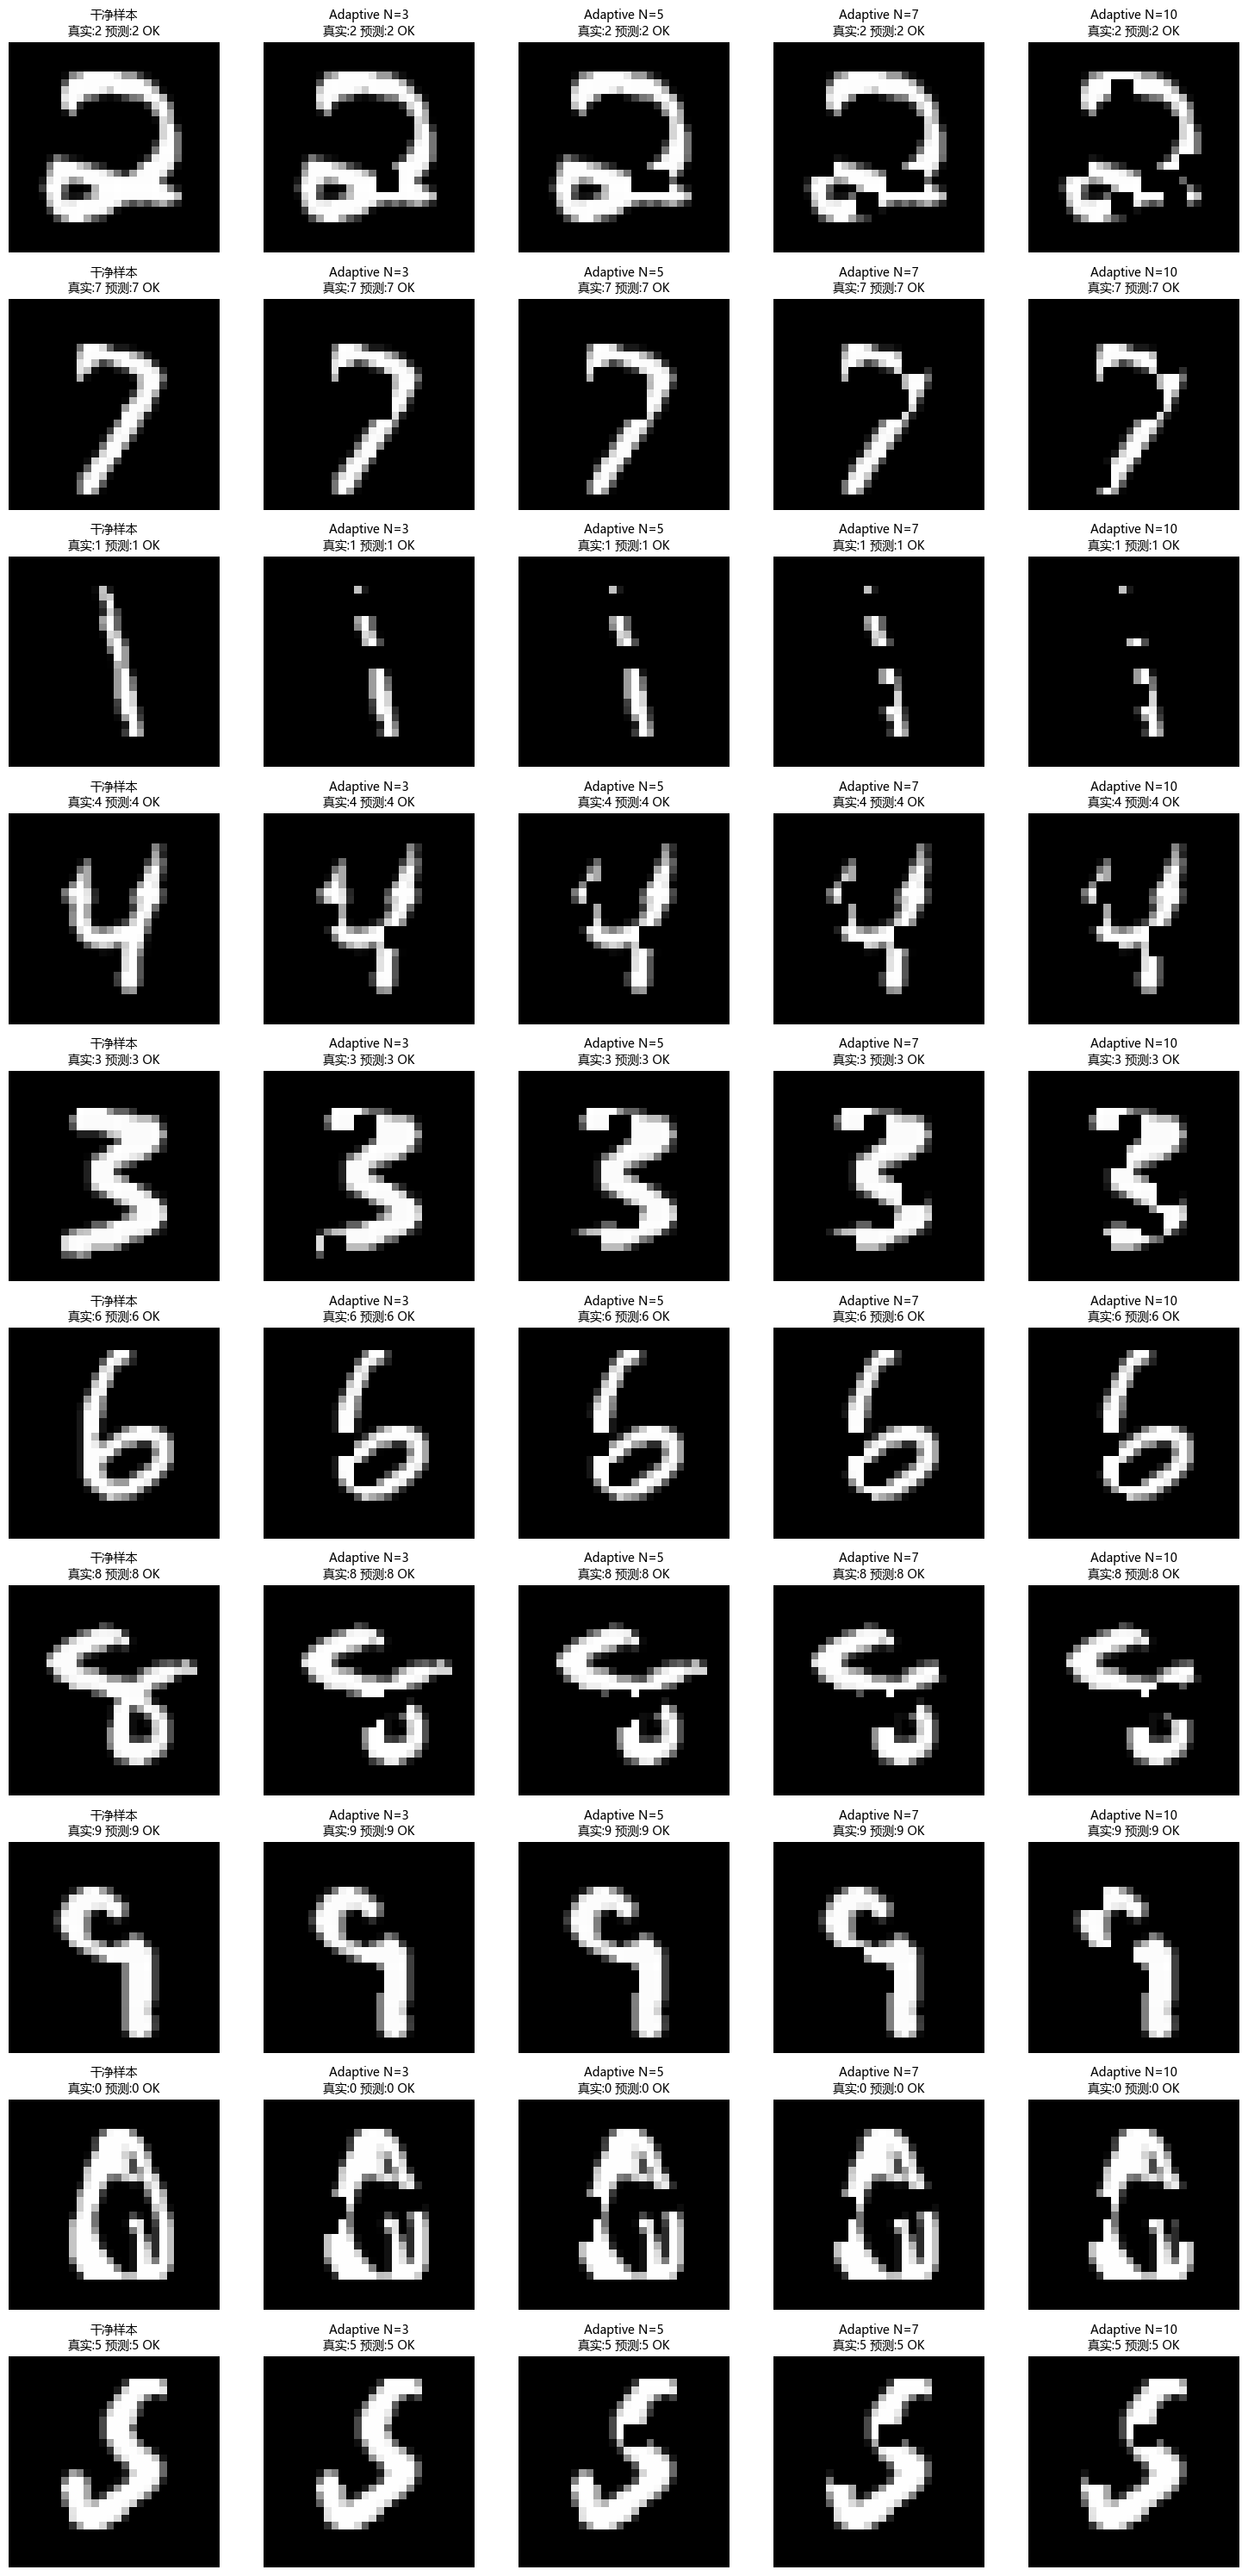

自适应遮蔽攻击(N参数)可视化已保存


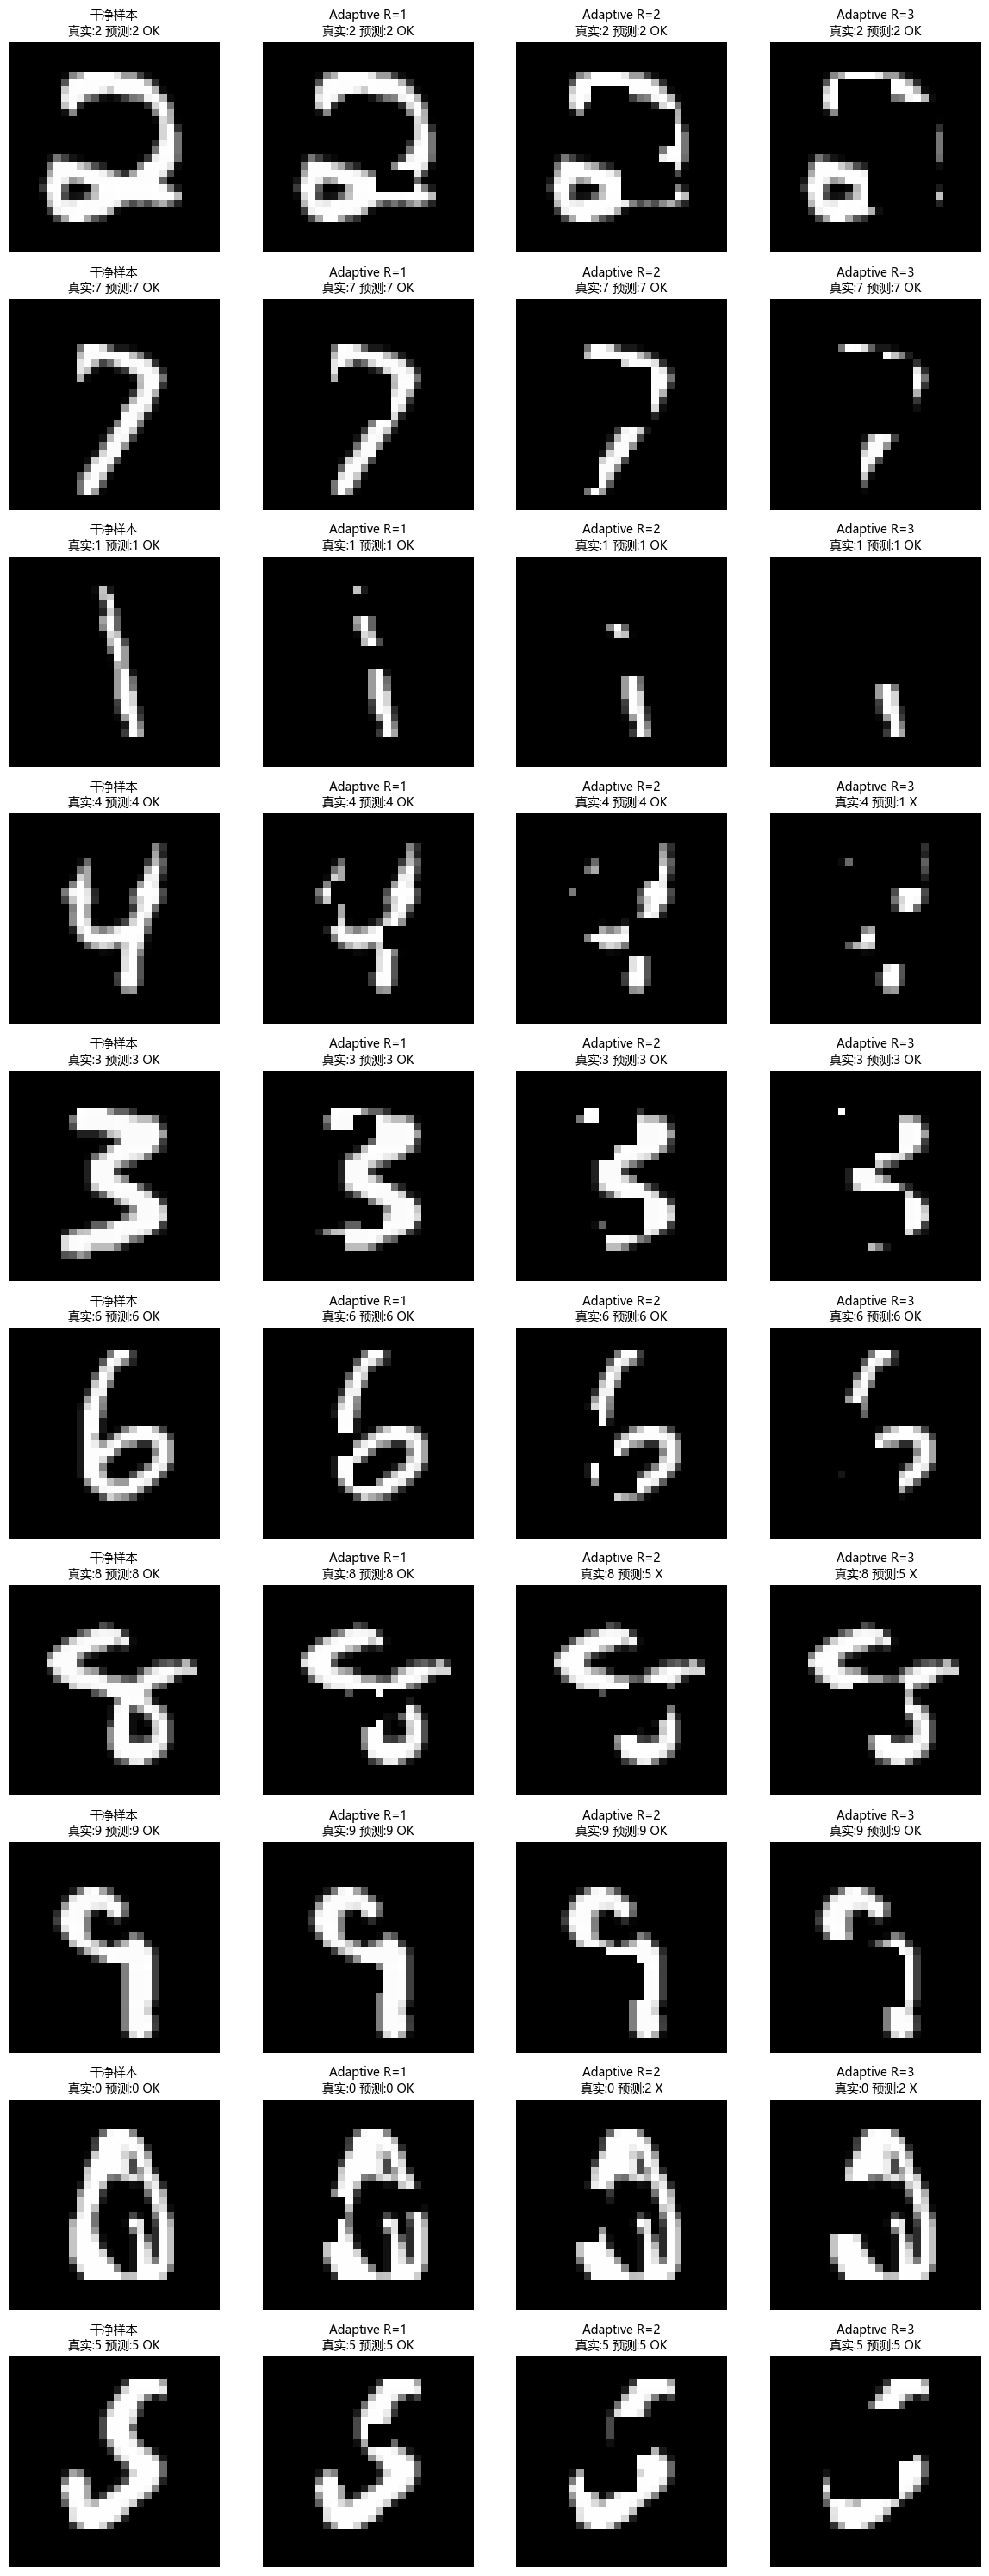

自适应遮蔽攻击(R参数)可视化已保存


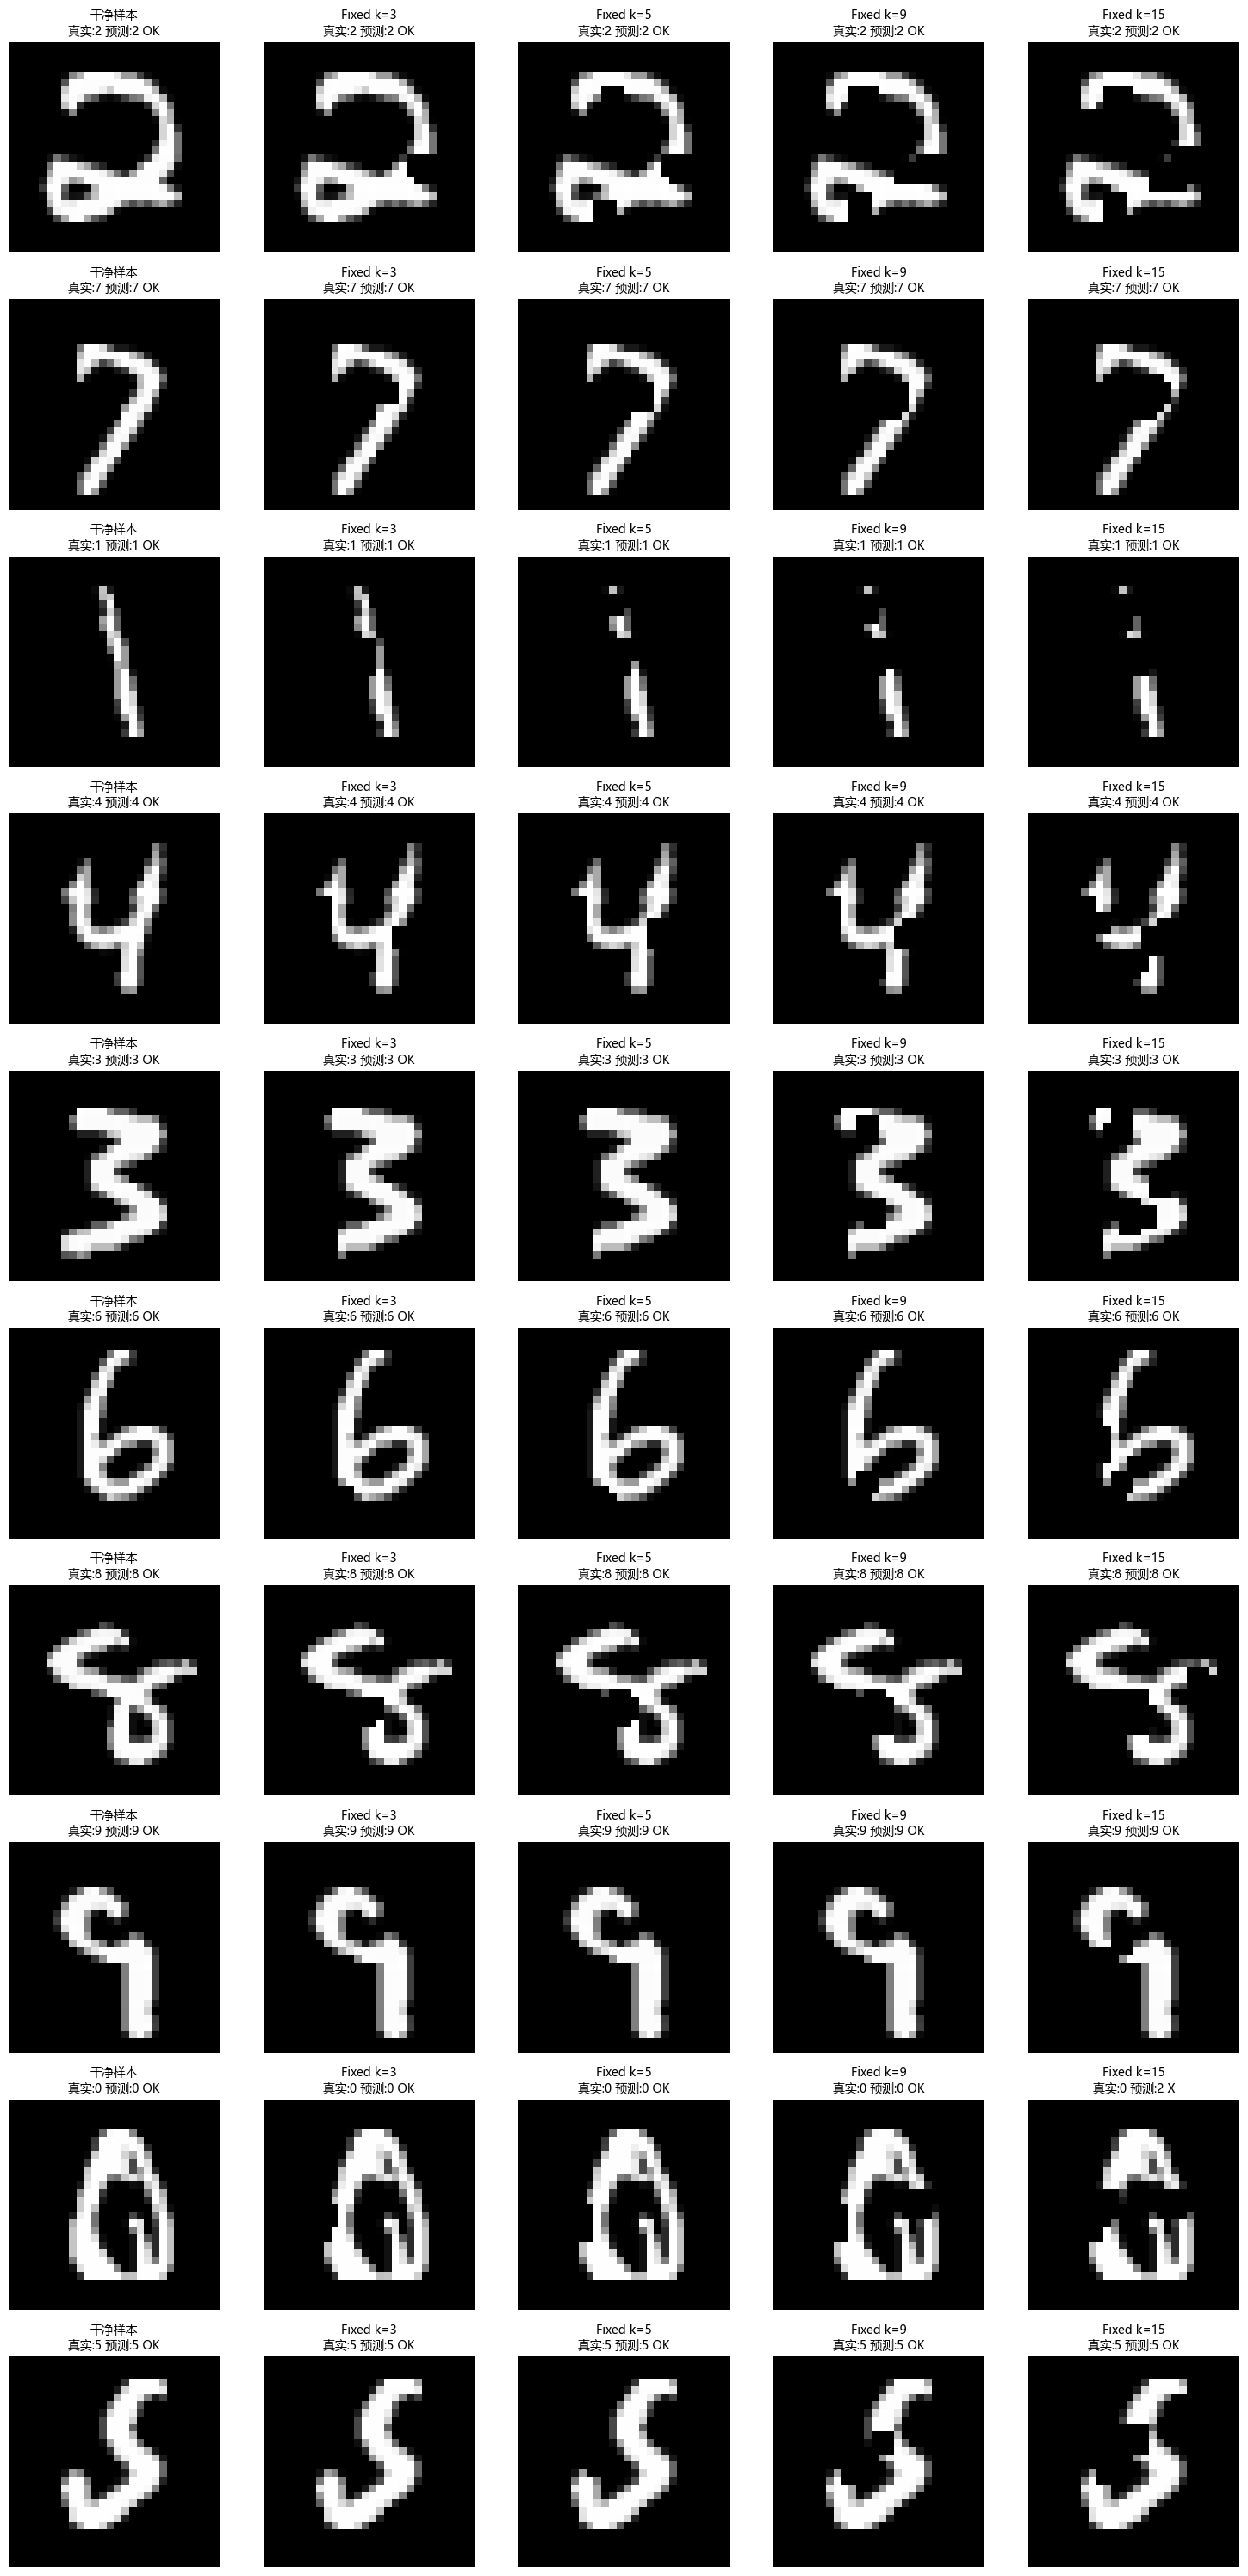

固定遮蔽攻击可视化已保存


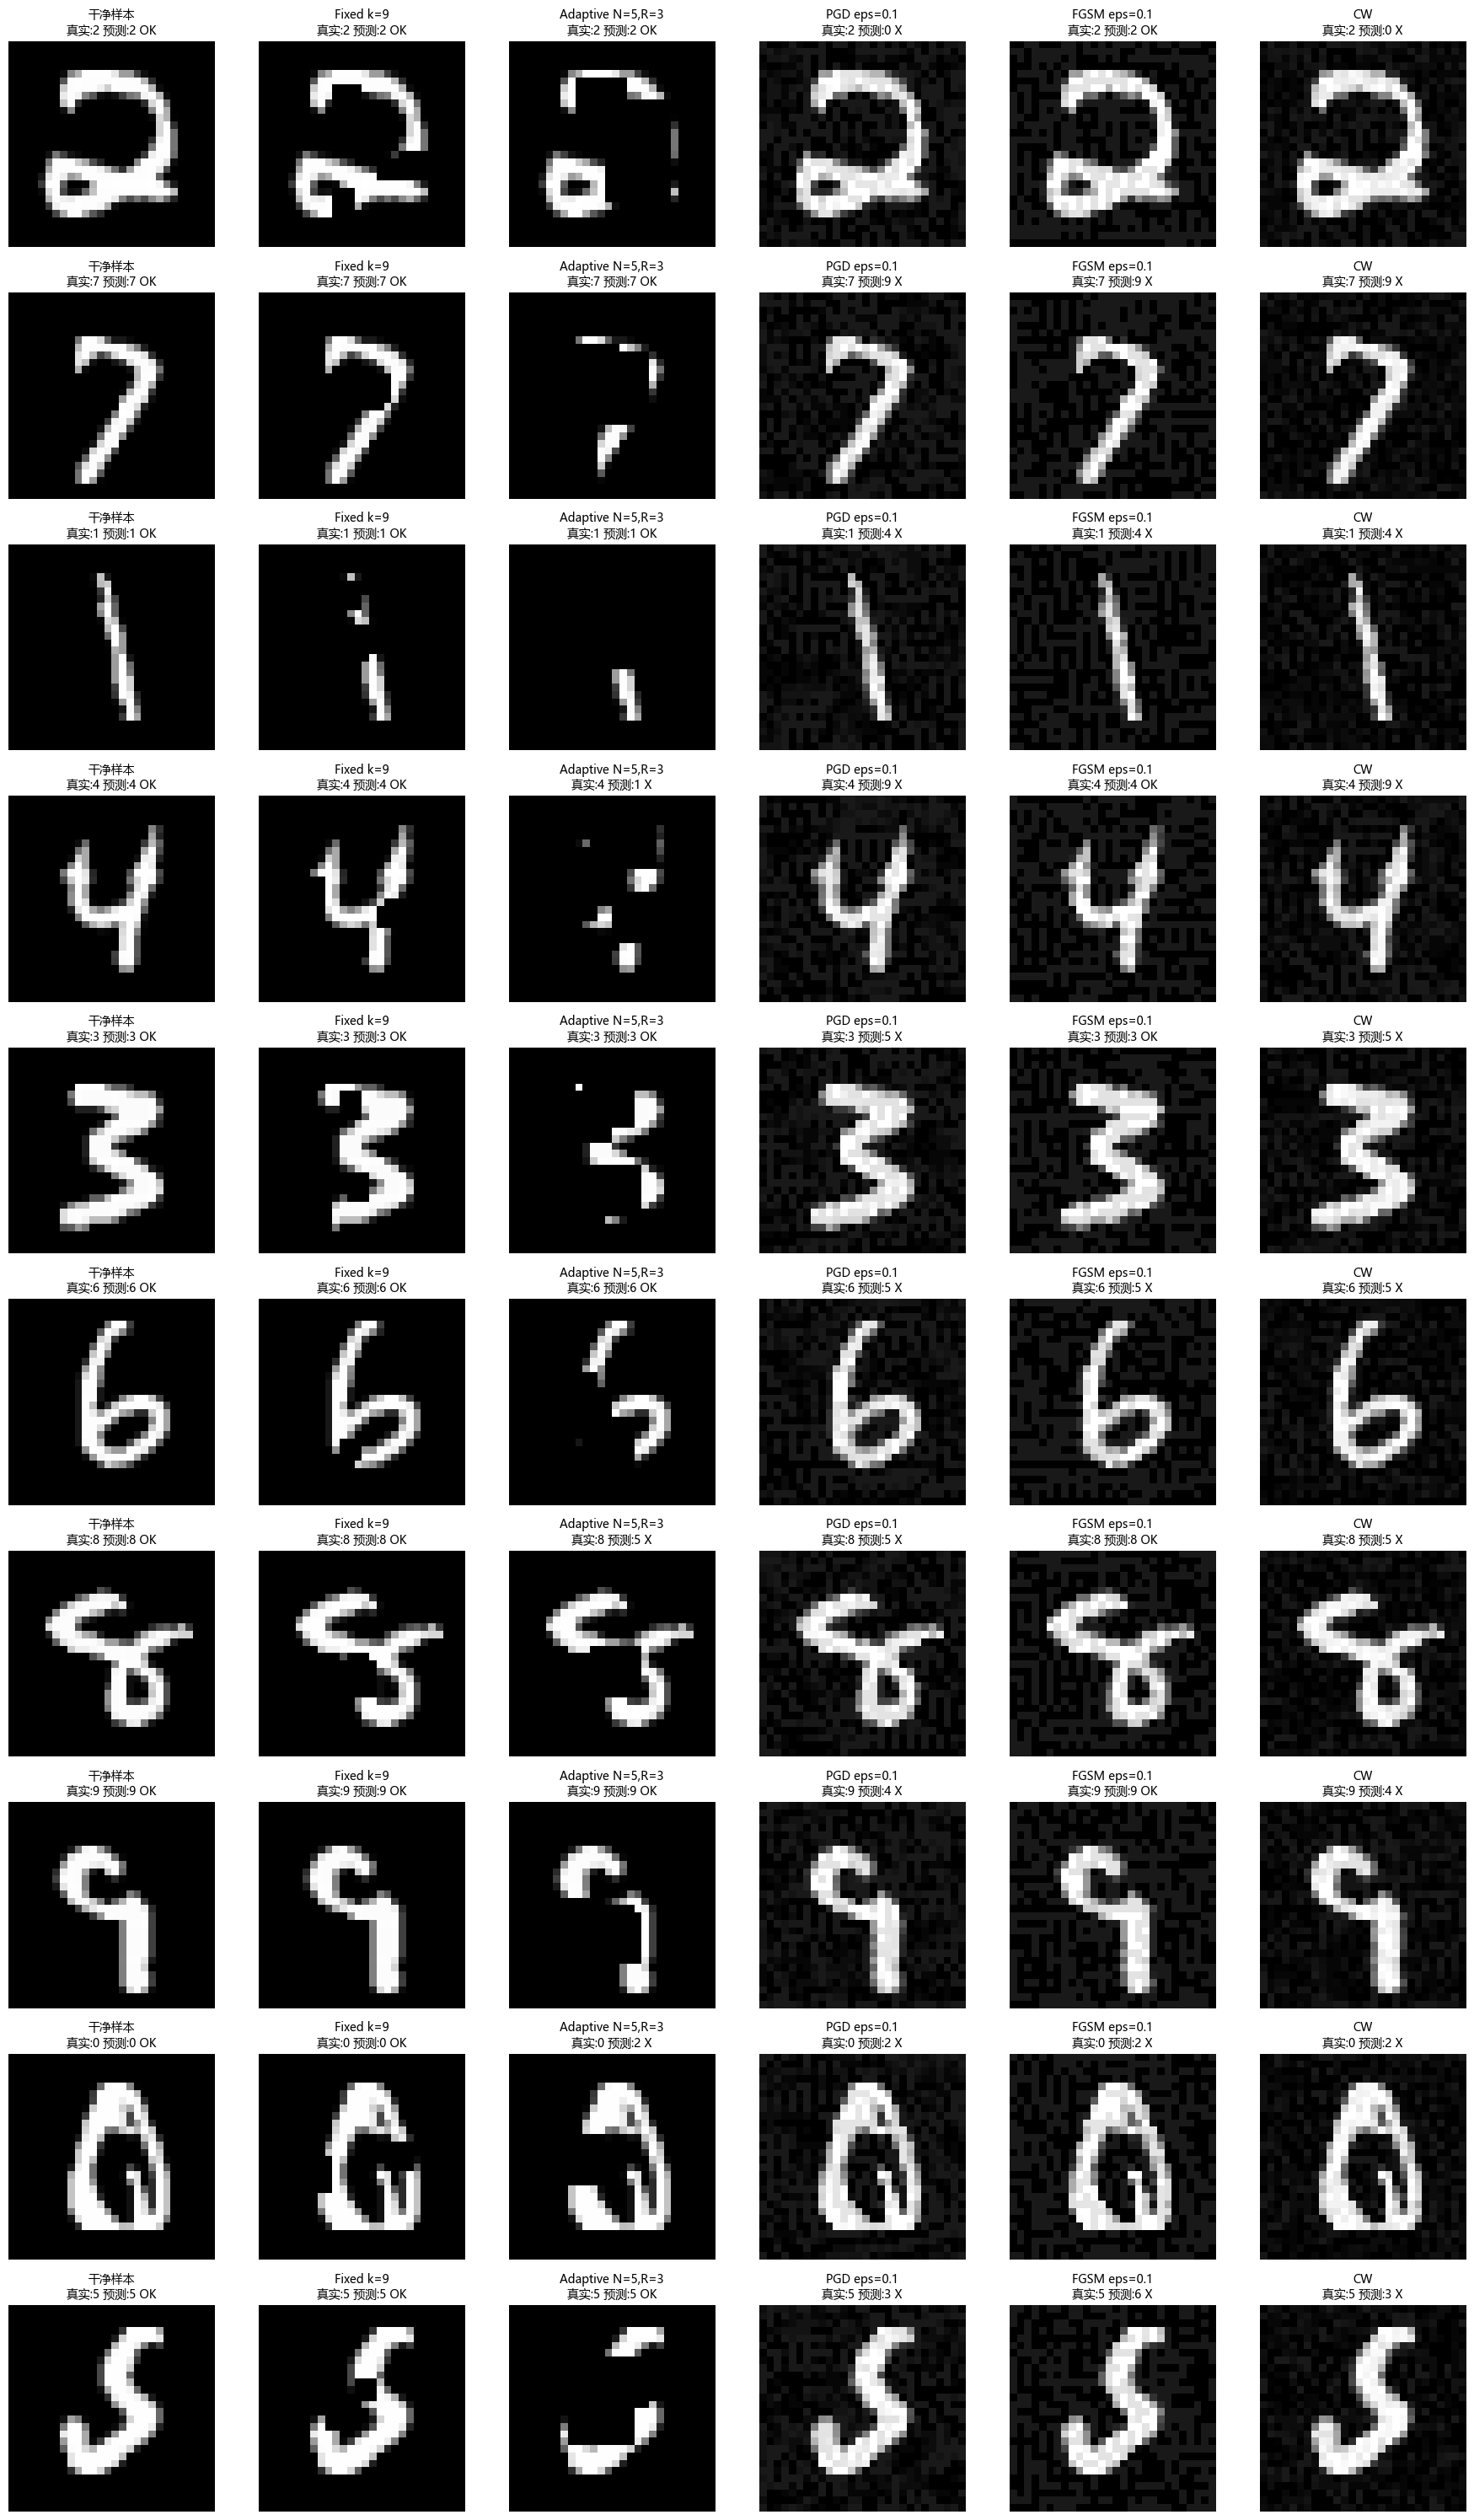

综合攻击对比可视化已保存
所有可视化完成!


In [7]:
# ========== 15.4.4 各类攻击效果可视化 (0-9每个数字) ==========
"""
为每个数字(0-9)展示不同攻击类型的效果
每行展示一个数字，每列展示一种攻击
"""
def load_model_from_ckpt(ckpt_path):
    """从检查点加载模型"""
    if not os.path.exists(ckpt_path):
        return None
    net = LeNet5().to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    net.load_state_dict(state['net'])
    net.eval()
    return net
# 确保模型和测试数据已加载

if 'cnn' not in globals():
    cnn = load_model_from_ckpt(f'./save_model/50epoch/mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_1.pth')
if 'imgs' not in globals() or 'lbls' not in globals():
    imgs, lbls = load_mnist_test()

# 选择展示样本：每个数字一个样本
sample_indices = []
shown = set()
for i in range(len(lbls)):
    label = int(lbls[i].item())
    if label not in shown:
        shown.add(label)
        sample_indices.append(i)
    if len(shown) == 10:
        break

print(f'展示样本索引: {sample_indices}')
print(f'样本标签: {[int(lbls[i].item()) for i in sample_indices]}')

# 创建结果目录
os.makedirs('./results_figures', exist_ok=True)

# 定义imshow_with_pred函数（如果未定义）
def imshow_with_pred(img, model, true_label, ax=None, title_prefix=''):
    """显示图像并标注真实标签和预测标签"""
    npimg = img.cpu().squeeze().numpy()
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(dim=1).item()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))
    
    ax.imshow(npimg, cmap='gray')
    correct_str = 'OK' if pred == true_label else 'X'
    title_text = title_prefix + chr(10) + f'真实:{true_label} 预测:{pred} {correct_str}'
    ax.set_title(title_text, fontsize=10)
    ax.axis('off')
    return pred == true_label

# --- 图1: 自适应遮蔽攻击 - 不同N参数 (固定R=3) ---
fig, axes = plt.subplots(10, 5, figsize=(15, 30))
N_values = [3, 5, 7, 10]
R_fixed = 1

for row, idx in enumerate(sample_indices):
    x = imgs[idx:idx+1].to(device)
    y = lbls[idx:idx+1].to(device)
    true_label = int(y.item())
    
    # 干净样本
    imshow_with_pred(x.squeeze(0), cnn, true_label, ax=axes[row, 0], title_prefix='干净样本')
    
    # 不同N参数的自适应遮蔽攻击
    for col, N_val in enumerate(N_values):
        attack = AdaptiveSaliencyOcclusionAttack(cnn, N=N_val, R=R_fixed, c=0.0)
        x_adv = attack((x, y))
        imshow_with_pred(x_adv.squeeze(0), cnn, true_label,
                        ax=axes[row, col+1], title_prefix=f'Adaptive N={N_val}')

plt.tight_layout()
plt.savefig(f'./results_figures/saliency_Adaptive_attack_visualization_N_R{R_fixed}.png', dpi=150, bbox_inches='tight')
plt.show()
print('自适应遮蔽攻击(N参数)可视化已保存')

# --- 图2: 自适应遮蔽攻击 - 不同R参数 (固定N=5) ---
fig, axes = plt.subplots(10, 4, figsize=(12, 30))
N_fixed = 5
R_values = [1,2, 3]

for row, idx in enumerate(sample_indices):
    x = imgs[idx:idx+1].to(device)
    y = lbls[idx:idx+1].to(device)
    true_label = int(y.item())
    
    # 干净样本
    imshow_with_pred(x.squeeze(0), cnn, true_label, ax=axes[row, 0], title_prefix='干净样本')
    
    # 不同R参数的自适应遮蔽攻击
    for col, R_val in enumerate(R_values):
        attack = AdaptiveSaliencyOcclusionAttack(cnn, N=N_fixed, R=R_val, c=0.0)
        x_adv = attack((x, y))
        imshow_with_pred(x_adv.squeeze(0), cnn, true_label,
                        ax=axes[row, col+1], title_prefix=f'Adaptive R={R_val}')

plt.tight_layout()
plt.savefig(f'./results_figures/saliency_Adaptive_attack_visualization_R_N{N_fixed}.png', dpi=150, bbox_inches='tight')
plt.show()
print('自适应遮蔽攻击(R参数)可视化已保存')

# --- 图3: 固定遮蔽攻击 - 不同top_k参数 ---
fig, axes = plt.subplots(10, 5, figsize=(15, 30))
top_k_values = [3, 5, 9, 15]
kernel_size = 3

for row, idx in enumerate(sample_indices):
    x = imgs[idx:idx+1].to(device)
    y = lbls[idx:idx+1].to(device)
    true_label = int(y.item())
    
    # 干净样本
    imshow_with_pred(x.squeeze(0), cnn, true_label, ax=axes[row, 0], title_prefix='干净样本')
    
    # 不同top_k的固定遮蔽攻击
    for col, top_k in enumerate(top_k_values):
        attack = SaliencyOcclusionAttack(cnn, top_k=top_k, kernel_size=kernel_size, occlu_color=0.0)
        x_adv = attack((x, y))
        imshow_with_pred(x_adv.squeeze(0), cnn, true_label,
                        ax=axes[row, col+1], title_prefix=f'Fixed k={top_k}')

plt.tight_layout()
plt.savefig(f'./results_figures/saliency_fixed_attack_visualization_ks{kernel_size}.png', dpi=150, bbox_inches='tight')
plt.show()
print('固定遮蔽攻击可视化已保存')

# --- 图4: 综合攻击对比 ---
fig, axes = plt.subplots(10, 6, figsize=(18, 30))

# 定义攻击参数
fixed_k = 9
adaptive_n = 5
adaptive_r = 3
pgd_eps = 0.1

for row, idx in enumerate(sample_indices):
    x = imgs[idx:idx+1].to(device)
    y = lbls[idx:idx+1].to(device)
    true_label = int(y.item())
    
    # 1. 干净样本
    imshow_with_pred(x.squeeze(0), cnn, true_label, ax=axes[row, 0], title_prefix='干净样本')
    
    # 2. 固定遮蔽攻击
    fixed_attack = SaliencyOcclusionAttack(cnn, top_k=fixed_k, kernel_size=3, occlu_color=0.0)
    x_adv_fixed = fixed_attack((x, y))
    imshow_with_pred(x_adv_fixed.squeeze(0), cnn, true_label,
                    ax=axes[row, 1], title_prefix=f'Fixed k={fixed_k}')
    
    # 3. 自适应遮蔽攻击
    adaptive_attack = AdaptiveSaliencyOcclusionAttack(cnn, N=adaptive_n, R=adaptive_r, c=0.0)
    x_adv_adaptive = adaptive_attack((x, y))
    imshow_with_pred(x_adv_adaptive.squeeze(0), cnn, true_label,
                    ax=axes[row, 2], title_prefix=f'Adaptive N={adaptive_n},R={adaptive_r}')
    
    # 4. PGD攻击
    pgd = LinfPGD(net=cnn, eps=pgd_eps, step=20, step_size=0.025, random_start=True)
    x_adv_pgd = pgd((x, y))
    imshow_with_pred(x_adv_pgd.squeeze(0), cnn, true_label,
                    ax=axes[row, 3], title_prefix=f'PGD eps={pgd_eps}')
    
    # 5. FGSM攻击
    fgsm = LinfPGD(net=cnn, eps=pgd_eps, step=1, step_size=pgd_eps, random_start=False)
    x_adv_fgsm = fgsm((x, y))
    imshow_with_pred(x_adv_fgsm.squeeze(0), cnn, true_label,
                    ax=axes[row, 4], title_prefix=f'FGSM eps={pgd_eps}')
    
    # 6. CW攻击
    cw = LinfPGD(net=cnn, eps=pgd_eps, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
    x_adv_cw = cw((x, y))
    imshow_with_pred(x_adv_cw.squeeze(0), cnn, true_label,
                    ax=axes[row, 5], title_prefix='CW')

plt.tight_layout()
plt.savefig('./results_figures/all_attacks_comparison_detailed.png', dpi=150, bbox_inches='tight')
plt.show()
print('综合攻击对比可视化已保存')
print('所有可视化完成!')


## 15.6 攻击效果可视化（含预测结果）

In [30]:
# 加载标准模型
import pandas as pd

std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', map_location=device, weights_only=False)
std_model = LeNet5().to(device)
std_model.load_state_dict(std_state['net'])
std_model.eval()

# 对比评测
comparison_results = []

for model_name, model in [('Standard', std_model), ('Adaptive-Saliency-AT', cnn)]:
    model.eval()
    
    # 干净样本
    clean, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')
    
    # Adaptive攻击 (N=5, R=3)
    attack_adaptive = AdaptiveSaliencyOcclusionAttack(model, N=5, R=3, c=0.0)
    adaptive_acc, _ = test_fn(nn.Sequential(attack_adaptive, model), imgs, lbls, bs=250, mode='attack')
    
    # Adaptive攻击 (N=10, R=3)
    attack_adaptive_10 = AdaptiveSaliencyOcclusionAttack(model, N=10, R=3, c=0.0)
    adaptive_acc_10, _ = test_fn(nn.Sequential(attack_adaptive_10, model), imgs, lbls, bs=250, mode='attack')
    
    # Fixed攻击 (对比)
    attack_fixed = SaliencyOcclusionAttack(model, top_k=9, kernel_size=3, occlu_color=0.0)
    fixed_acc, _ = test_fn(nn.Sequential(attack_fixed, model), imgs, lbls, bs=250, mode='attack')
    
    comparison_results.append({
        'Model': model_name,
        'Clean': round(clean, 2),
        'Adaptive(N=5,R=3)': round(adaptive_acc, 2),
        'Adaptive(N=10,R=3)': round(adaptive_acc_10, 2),
        'Fixed(k=9)': round(fixed_acc, 2)
    })

df_compare = pd.DataFrame(comparison_results)
print('\n========== 标准模型 vs Adaptive-Saliency-AT 对比 ==========')
print(df_compare.to_string(index=False))


========== 标准模型 vs Adaptive-Saliency-AT 对比 ==========
               Model  Clean  Adaptive(N=5,R=3)  Adaptive(N=10,R=3)  Fixed(k=9)
            Standard  99.00              34.33               15.95       71.19
Adaptive-Saliency-AT  98.91              72.59               46.49       97.95


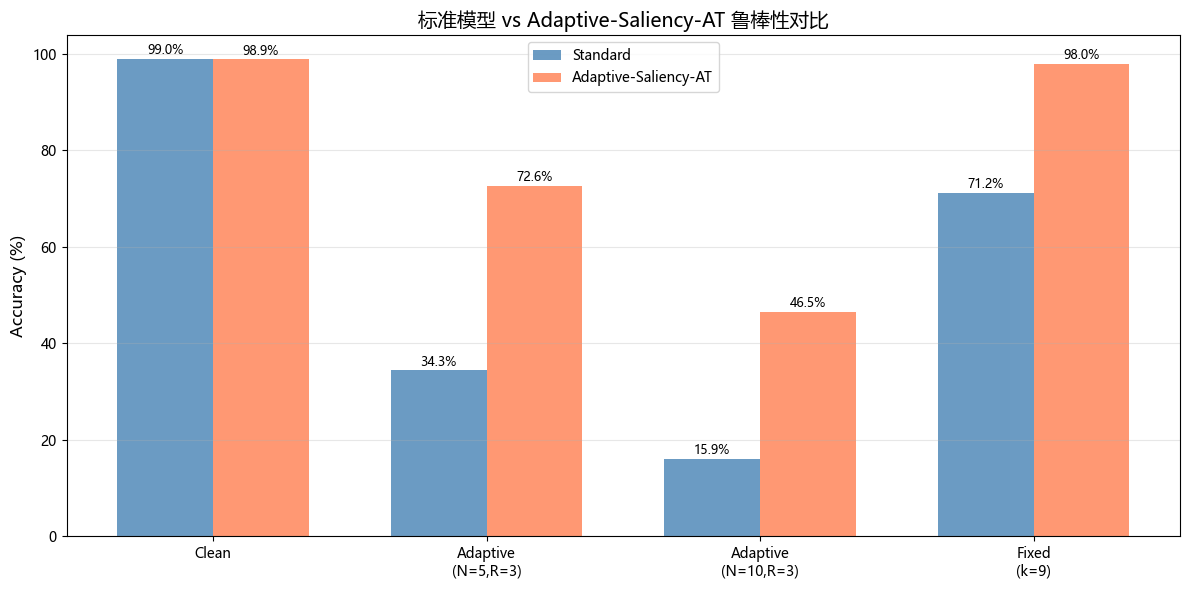

In [31]:
# 绘制对比图
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(4)
width = 0.35

std_vals = [comparison_results[0]['Clean'], 
            comparison_results[0]['Adaptive(N=5,R=3)'],
            comparison_results[0]['Adaptive(N=10,R=3)'],
            comparison_results[0]['Fixed(k=9)']]
at_vals = [comparison_results[1]['Clean'], 
           comparison_results[1]['Adaptive(N=5,R=3)'],
           comparison_results[1]['Adaptive(N=10,R=3)'],
           comparison_results[1]['Fixed(k=9)']]

bars1 = ax.bar(x - width/2, std_vals, width, label='Standard', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, at_vals, width, label='Adaptive-Saliency-AT', color='coral', alpha=0.8)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('标准模型 vs Adaptive-Saliency-AT 鲁棒性对比', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Clean', 'Adaptive\n(N=5,R=3)', 'Adaptive\n(N=10,R=3)', 'Fixed\n(k=9)'])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar, val in zip(bars1, std_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=9)
for bar, val in zip(bars2, at_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'./results_figures/adaptive_saliency_at_comparison_{N}_{R}.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# 保存所有评测结果
df_all = pd.DataFrame(adaptive_eval_results + fixed_eval_results)
df_all.to_csv('./results_figures/adaptive_saliency_at_evaluation_results.csv', index=False)

df_compare.to_csv('./results_figures/adaptive_saliency_at_comparison.csv', index=False)

print('评测结果已保存至:')
print('  - ./results_figures/adaptive_saliency_at_evaluation_results.csv')
print('  - ./results_figures/adaptive_saliency_at_comparison.csv')

评测结果已保存至:
  - ./results_figures/adaptive_saliency_at_evaluation_results.csv
  - ./results_figures/adaptive_saliency_at_comparison.csv


## 15.7 自适应Saliency遮蔽攻击 + PGD 混合攻击训练

为了提升模型对多种攻击的鲁棒性，本节实现**混合攻击训练**：
- 将每个 batch 的样本按比例分配：一部分使用自适应Saliency遮蔽攻击，另一部分使用 PGD 攻击
- 兼顾对遮蔽攻击和基于梯度攻击的防御能力

### 混合攻击策略
- `occlu_ratio`: 使用遮蔽攻击的样本比例（默认 0.5）
- 剩余样本使用 PGD (L∞) 攻击
- 通过单一训练过程同时提升对两类攻击的鲁棒性

In [33]:
# 定义自适应Saliency遮蔽攻击 + PGD 混合攻击训练模块
class AdaptiveSaliencyPgdMixedAT(nn.Module):
    """自适应Saliency遮蔽攻击 + PGD 混合对抗性训练
    
    每个batch中按比例混合两种攻击：
    - 自适应Saliency遮蔽攻击: 渐进式遮蔽，保留语义
    - PGD (L∞): 基于梯度的迭代攻击
    """
    
    def __init__(
        self,
        model,
        N=5,
        R=3,
        c=0.0,
        eps=0.1,
        pgd_step=20,
        pgd_step_size=0.025,
        random_start=True,
        occlu_ratio=0.5,
        criterion=F.cross_entropy,
    ):
        super().__init__()
        self.model = model
        self.occlu_ratio = occlu_ratio
        
        # 自适应Saliency遮蔽攻击
        self.occlusion = AdaptiveSaliencyOcclusionAttack(
            model, N=N, R=R, c=c
        )
        # PGD攻击
        self.pgd = LinfPGD(
            net=model,
            eps=eps,
            step_size=pgd_step_size,
            step=pgd_step,
            random_start=random_start,
            criterion=criterion,
        )
    
    def forward(self, x, y=None):
        if y is None:
            return self.model(x)
        
        training = self.model.training
        # 对抗样本生成阶段固定为eval模式
        self.model.eval()
        
        bs = x.size(0)
        k = int(bs * self.occlu_ratio)
        
        if k <= 0:
            # 全部使用PGD
            x_mix = self.pgd((x, y))
        elif k >= bs:
            # 全部使用遮蔽攻击
            x_mix = self.occlusion((x, y))
        else:
            # 混合：前k个用遮蔽攻击，其余用PGD
            x_adv_occl = self.occlusion((x, y))
            x_adv_pgd = self.pgd((x, y))
            
            x_mix = x_adv_pgd.clone()
            x_mix[:k] = x_adv_occl[:k]
        
        # 恢复训练模式
        if training:
            self.model.train()
        
        return self.model(x_mix)

print("混合攻击训练模块已定义")

混合攻击训练模块已定义


In [34]:
# ========== 混合攻击训练配置 ==========
EPOCH_MIX = 50              # 训练轮数（可根据需要调整）
LR_MIX = 0.001              # 学习率

# 自适应遮蔽攻击参数
N_MIX = 5                   # 最大遮蔽区域数
R_MIX = 3                   # 最大遮蔽半径
C_COLOR_MIX = 0.0           # 黑色遮蔽

# PGD参数
EPS_MIX = 0.1               # L∞扰动预算
PGD_STEP_MIX = 20           # PGD迭代步数
PGD_STEP_SIZE_MIX = 0.025   # PGD步长
RANDOM_START_MIX = True     # 随机初始化

# 混合比例
OCCLU_RATIO_MIX = 0.5       # 0.5 = 一半遮蔽攻击，一半PGD攻击

print(f'混合攻击训练参数: EPOCH={EPOCH_MIX}, LR={LR_MIX}')
print(f'自适应遮蔽参数: N={N_MIX}, R={R_MIX}, C_COLOR={C_COLOR_MIX}')
print(f'PGD参数: eps={EPS_MIX}, step={PGD_STEP_MIX}, step_size={PGD_STEP_SIZE_MIX}')
print(f'混合比例: occlu_ratio={OCCLU_RATIO_MIX} ({OCCLU_RATIO_MIX*100:.0f}%遮蔽 + {(1-OCCLU_RATIO_MIX)*100:.0f}%PGD)')

# 复用之前的数据加载器（train_loader, test_loader）
print(f'训练集: {len(train_loader.dataset)}, 测试集: {len(test_loader.dataset)}')

混合攻击训练参数: EPOCH=50, LR=0.001
自适应遮蔽参数: N=5, R=3, C_COLOR=0.0
PGD参数: eps=0.1, step=20, step_size=0.025
混合比例: occlu_ratio=0.5 (50%遮蔽 + 50%PGD)
训练集: 60000, 测试集: 10000


In [35]:
# ========== 初始化混合攻击训练模型 ==========
cnn_mix = LeNet5().to(device)
cnn_mix_at = AdaptiveSaliencyPgdMixedAT(
    cnn_mix,
    N=N_MIX,
    R=R_MIX,
    c=C_COLOR_MIX,
    eps=EPS_MIX,
    pgd_step=PGD_STEP_MIX,
    pgd_step_size=PGD_STEP_SIZE_MIX,
    random_start=RANDOM_START_MIX,
    occlu_ratio=OCCLU_RATIO_MIX,
    criterion=F.cross_entropy,
)

optimizer_mix = torch.optim.Adam(cnn_mix.parameters(), lr=LR_MIX)
loss_function_mix = nn.CrossEntropyLoss()

print(f'模型参数量: {sum(p.numel() for p in cnn_mix.parameters() if p.requires_grad)}')
print('混合攻击训练模型初始化完成')

模型参数量: 61706
混合攻击训练模型初始化完成


In [36]:
# ========== 混合攻击训练循环 ==========
train_accs_mix, train_losses_mix = [], []
test_accs_mix, test_losses_mix = [], []
test_clean_accs_mix = []
best_acc_mix = 0
best_state_mix = None

for epoch in range(EPOCH_MIX):
    # 训练阶段
    cnn_mix_at.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in tqdm(train_loader, desc=f'Mix-AT Epoch {epoch+1}/{EPOCH_MIX}'):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = cnn_mix_at(inputs, labels)
        loss = loss_function_mix(outputs, labels)
        
        optimizer_mix.zero_grad()
        loss.backward()
        optimizer_mix.step()
        
        pred = outputs.argmax(dim=1)
        train_correct += (pred == labels).sum().item()
        train_total += n
        train_loss += loss.item() * n
    
    train_acc = train_correct / train_total
    train_loss_avg = train_loss / train_total
    train_accs_mix.append(train_acc)
    train_losses_mix.append(train_loss_avg)
    
    # 测试阶段
    cnn_mix_at.eval()
    test_loss = 0.0
    test_correct = 0
    test_clean_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            n = labels.size(0)
            inputs, labels = inputs.to(device), labels.to(device)
            
            # 干净样本准确率
            pred_clean = cnn_mix(inputs).argmax(dim=1)
            test_clean_correct += (pred_clean == labels).sum().item()
            
            # 混合对抗样本准确率
            outputs = cnn_mix_at(inputs, labels)
            loss = loss_function_mix(outputs, labels)
            pred = outputs.argmax(dim=1)
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.item() * n
    
    test_acc = test_correct / test_total
    test_loss_avg = test_loss / test_total
    test_clean_acc = test_clean_correct / test_total
    
    test_accs_mix.append(test_acc)
    test_losses_mix.append(test_loss_avg)
    test_clean_accs_mix.append(test_clean_acc)
    
    logger.info(f'Mix-AT Epoch {epoch+1}: Train Loss={train_loss_avg:.4f}, '
                f'Train Acc={100*train_acc:.2f}%, Test(Robust)={100*test_acc:.2f}%, '
                f'Test(Clean)={100*test_clean_acc:.2f}%')
    
    # 保存最佳模型
    if test_acc > best_acc_mix:
        best_acc_mix = test_acc
        best_state_mix = copy.deepcopy(cnn_mix.state_dict())

# 加载最佳模型
if best_state_mix is not None:
    cnn_mix.load_state_dict(best_state_mix)
    print(f'加载最佳模型，混合攻击鲁棒准确率: {100*best_acc_mix:.2f}%')

20260410 00:41:34 Mix-AT Epoch 1: Train Loss=1.0395, Train Acc=55.80%, Test(Robust)=71.72%, Test(Clean)=95.19%
20260410 00:43:36 Mix-AT Epoch 2: Train Loss=0.5417, Train Acc=74.60%, Test(Robust)=78.64%, Test(Clean)=96.97%
20260410 00:45:38 Mix-AT Epoch 3: Train Loss=0.4585, Train Acc=78.27%, Test(Robust)=79.10%, Test(Clean)=97.77%
20260410 00:47:41 Mix-AT Epoch 4: Train Loss=0.4239, Train Acc=79.61%, Test(Robust)=79.67%, Test(Clean)=97.93%
20260410 00:49:36 Mix-AT Epoch 5: Train Loss=0.4032, Train Acc=80.43%, Test(Robust)=80.86%, Test(Clean)=97.97%
20260410 00:51:35 Mix-AT Epoch 6: Train Loss=0.3809, Train Acc=81.35%, Test(Robust)=81.71%, Test(Clean)=98.21%
20260410 00:53:33 Mix-AT Epoch 7: Train Loss=0.3663, Train Acc=82.30%, Test(Robust)=81.98%, Test(Clean)=98.35%
20260410 00:55:33 Mix-AT Epoch 8: Train Loss=0.3505, Train Acc=82.93%, Test(Robust)=82.53%, Test(Clean)=98.23%
20260410 00:57:32 Mix-AT Epoch 9: Train Loss=0.3385, Train Acc=83.52%, Test(Robust)=83.46%, Test(Clean)=98.12%
2

加载最佳模型，混合攻击鲁棒准确率: 86.93%


In [37]:
# ========== 保存混合攻击训练模型 ==========
state_mix = {
    'net': cnn_mix.state_dict(),
    'epoch': EPOCH_MIX,
    'train_losses': train_losses_mix,
    'train_accs': train_accs_mix,
    'test_losses': test_losses_mix,
    'test_accs': test_accs_mix,
    'test_clean_accs': test_clean_accs_mix,
    'params': {
        'N': N_MIX, 'R': R_MIX, 'c': C_COLOR_MIX,
        'eps': EPS_MIX, 'occlu_ratio': OCCLU_RATIO_MIX
    }
}

save_dir_mix = f'./save_model/{EPOCH_MIX}epoch'
os.makedirs(save_dir_mix, exist_ok=True)
save_path_mix = os.path.join(save_dir_mix, 
    f'mnist_lenet5_AdaptiveSaliencyPgdMixedAT_{OCCLU_RATIO_MIX}_{N_MIX}_{R_MIX}.pth')
torch.save(state_mix, save_path_mix)
print(f'混合攻击训练模型已保存: {save_path_mix}')

混合攻击训练模型已保存: ./save_model/50epoch\mnist_lenet5_AdaptiveSaliencyPgdMixedAT_0.5_5_3.pth


### 15.7.1 混合攻击训练模型评测

对混合攻击训练后的模型进行多角度评测：
1. 干净样本准确率
2. 白盒攻击：FGSM, PGD, CW
3. 遮蔽攻击：Fixed 和 Adaptive
4. AutoAttack（可选）

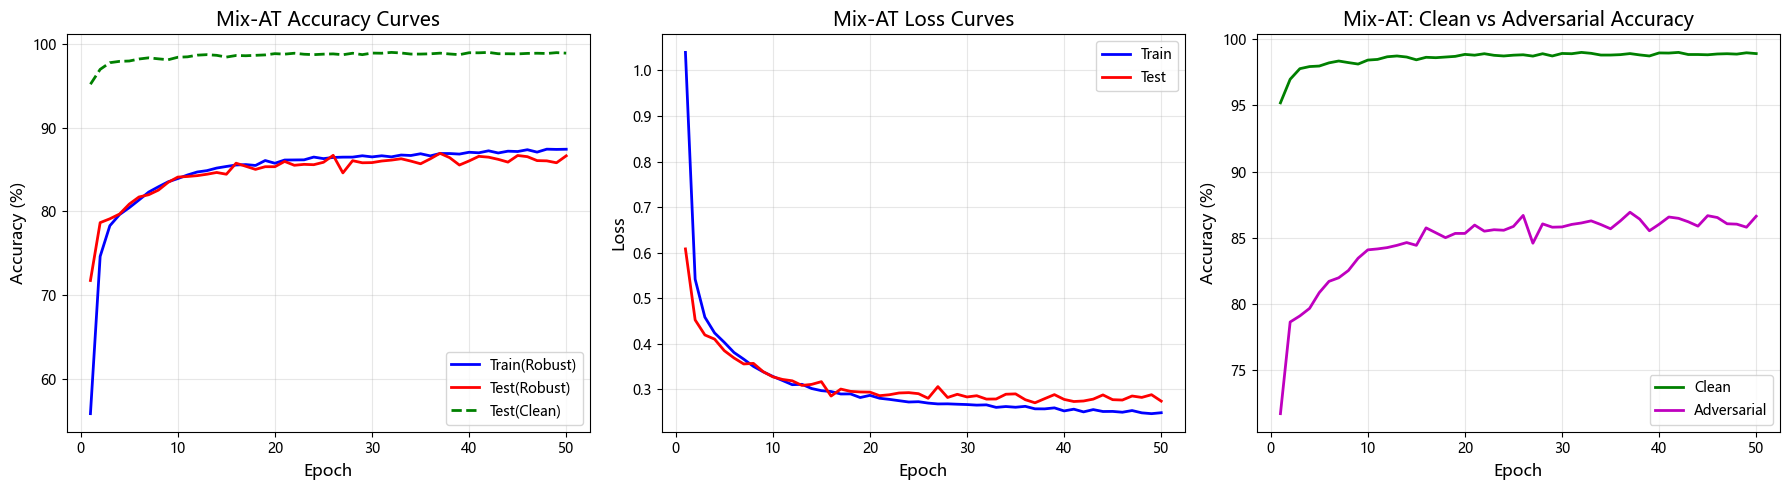

Mix-AT训练曲线已保存
最终测试结果 - 干净样本: 98.91%, 对抗样本: 86.63%


In [38]:
# ========== 绘制混合攻击训练曲线 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_mix = list(range(1, EPOCH_MIX+1))

# 准确率曲线
axes[0].plot(epochs_mix, [100*a for a in train_accs_mix], 'b-', label='Train(Robust)', linewidth=2)
axes[0].plot(epochs_mix, [100*a for a in test_accs_mix], 'r-', label='Test(Robust)', linewidth=2)
axes[0].plot(epochs_mix, [100*a for a in test_clean_accs_mix], 'g--', label='Test(Clean)', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Mix-AT Accuracy Curves', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 损失曲线
axes[1].plot(epochs_mix, train_losses_mix, 'b-', label='Train', linewidth=2)
axes[1].plot(epochs_mix, test_losses_mix, 'r-', label='Test', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Mix-AT Loss Curves', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 干净 vs 对抗准确率
axes[2].plot(epochs_mix, [100*a for a in test_clean_accs_mix], 'g-', label='Clean', linewidth=2)
axes[2].plot(epochs_mix, [100*a for a in test_accs_mix], 'm-', label='Adversarial', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Accuracy (%)', fontsize=12)
axes[2].set_title('Mix-AT: Clean vs Adversarial Accuracy', fontsize=14)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'./results_figures/mix_at_training_curves_{N_MIX}_{R_MIX}_{OCCLU_RATIO_MIX}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mix-AT训练曲线已保存')
print(f'最终测试结果 - 干净样本: {100*test_clean_accs_mix[-1]:.2f}%, 对抗样本: {100*test_accs_mix[-1]:.2f}%')

In [39]:
# ========== 混合攻击训练模型多角度评测 ==========
# 加载测试集
imgs, lbls = load_mnist_test()

# 统一配置
_eps = EPS_MIX
_n_mix = N_MIX
_r_mix = R_MIX
_c_color = C_COLOR_MIX

cnn_mix.eval()

# 1. 干净样本准确率
clean_acc_mix, _ = test_fn(cnn_mix, imgs, lbls, bs=250, mode='clean')
logger.info(f'Mix-AT模型 - 干净样本准确率: {clean_acc_mix:.2f}%')

# 2. 白盒攻击评测
# FGSM
fgsm = LinfPGD(net=cnn_mix, eps=_eps, step=1, step_size=_eps, random_start=False)
fgsm_acc_mix, _ = test_fn(nn.Sequential(fgsm, cnn_mix), imgs, lbls, bs=250, mode='attack')

# PGD
pgd = LinfPGD(net=cnn_mix, eps=_eps, step=20, step_size=0.025, random_start=True)
pgd_acc_mix, _ = test_fn(nn.Sequential(pgd, cnn_mix), imgs, lbls, bs=250, mode='attack')

# CW
cw = LinfPGD(net=cnn_mix, eps=_eps, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
cw_acc_mix, _ = test_fn(nn.Sequential(cw, cnn_mix), imgs, lbls, bs=250, mode='attack')

logger.info(f'Mix-AT模型白盒攻击 - FGSM: {fgsm_acc_mix:.2f}%, PGD: {pgd_acc_mix:.2f}%, CW: {cw_acc_mix:.2f}%')

# 3. 遮蔽攻击评测
# Fixed Saliency遮蔽攻击
fixed_attack = SaliencyOcclusionAttack(cnn_mix, top_k=9, kernel_size=3, occlu_color=0.0)
fixed_acc_mix, _ = test_fn(nn.Sequential(fixed_attack, cnn_mix), imgs, lbls, bs=250, mode='attack')

# Adaptive Saliency遮蔽攻击
adaptive_attack = AdaptiveSaliencyOcclusionAttack(cnn_mix, N=_n_mix, R=_r_mix, c=_c_color)
adaptive_acc_mix, _ = test_fn(nn.Sequential(adaptive_attack, cnn_mix), imgs, lbls, bs=250, mode='attack')

logger.info(f'Mix-AT模型遮蔽攻击 - Fixed: {fixed_acc_mix:.2f}%, Adaptive: {adaptive_acc_mix:.2f}%')

# 汇总结果
mix_eval_results = {
    'Model': 'Mix-AT (AdaptiveSaliency+PGD)',
    'Clean': round(clean_acc_mix, 2),
    'FGSM': round(fgsm_acc_mix, 2),
    'PGD': round(pgd_acc_mix, 2),
    'CW': round(cw_acc_mix, 2),
    'Fixed(k=9)': round(fixed_acc_mix, 2),
    'Adaptive(N=5,R=3)': round(adaptive_acc_mix, 2)
}

print('\n========== Mix-AT模型评测结果 ==========')
for k, v in mix_eval_results.items():
    print(f'{k}: {v}%')

20260410 02:22:17 Mix-AT模型 - 干净样本准确率: 98.91%
20260410 02:22:19 Mix-AT模型白盒攻击 - FGSM: 94.51%, PGD: 92.85%, CW: 92.80%
20260410 02:23:07 Mix-AT模型遮蔽攻击 - Fixed: 95.48%, Adaptive: 80.65%



========== Mix-AT模型评测结果 ==========
Model: Mix-AT (AdaptiveSaliency+PGD)%
Clean: 98.91%
FGSM: 94.51%
PGD: 92.85%
CW: 92.8%
Fixed(k=9): 95.48%
Adaptive(N=5,R=3): 80.65%


### 15.7.2 多模型对比评测

对比以下模型的性能：
1. Standard Model (标准模型)
2. Adaptive-Saliency-AT (纯自适应Saliency遮蔽攻击AT)
3. Mix-AT (混合攻击训练模型)

In [40]:
# ========== 混合攻击训练模型详细评测 ==========
# 在基础评测(cell-43)之上，增加详细参数敏感性测试

# 加载测试集（如果尚未加载）
if 'imgs' not in globals():
    imgs, lbls = load_mnist_test()

cnn_mix.eval()

# 1. 自适应遮蔽攻击 - 不同N参数（固定R=3）
logger.info('===== Mix-AT模型: 自适应遮蔽攻击不同N参数测试 =====')
mix_adaptive_n_results = []
N_test_mix = [3, 5, 7, 10]
for N_val in N_test_mix:
    attack = AdaptiveSaliencyOcclusionAttack(cnn_mix, N=N_val, R=3, c=0.0)
    acc, _ = test_fn(nn.Sequential(attack, cnn_mix), imgs, lbls, bs=250, mode='attack')
    mix_adaptive_n_results.append({'param': f'N={N_val},R=3', 'N': N_val, 'R': 3, 'accuracy': acc})
    logger.info(f'Mix-AT Adaptive (N={N_val}, R=3): {acc:.2f}%')

# 2. 自适应遮蔽攻击 - 不同R参数（固定N=5）
logger.info('===== Mix-AT模型: 自适应遮蔽攻击不同R参数测试 =====')
mix_adaptive_r_results = []
R_test_mix = [2, 3, 4]
for R_val in R_test_mix:
    attack = AdaptiveSaliencyOcclusionAttack(cnn_mix, N=5, R=R_val, c=0.0)
    acc, _ = test_fn(nn.Sequential(attack, cnn_mix), imgs, lbls, bs=250, mode='attack')
    mix_adaptive_r_results.append({'param': f'N=5,R={R_val}', 'N': 5, 'R': R_val, 'accuracy': acc})
    logger.info(f'Mix-AT Adaptive (N=5, R={R_val}): {acc:.2f}%')

# 3. 固定遮蔽攻击 - 不同top_k（作为对比）
logger.info('===== Mix-AT模型: 固定遮蔽攻击不同top_k测试 =====')
mix_fixed_results = []
top_k_test_mix = [3, 5, 9, 15]
for top_k in top_k_test_mix:
    attack = SaliencyOcclusionAttack(cnn_mix, top_k=top_k, kernel_size=3, occlu_color=0.0)
    acc, _ = test_fn(nn.Sequential(attack, cnn_mix), imgs, lbls, bs=250, mode='attack')
    mix_fixed_results.append({'param': f'top_k={top_k}', 'top_k': top_k, 'accuracy': acc})
    logger.info(f'Mix-AT Fixed (top_k={top_k}): {acc:.2f}%')

# 4. 不同遮蔽颜色测试
logger.info('===== Mix-AT模型: 不同遮蔽颜色测试 =====')
mix_color_results = []
colors_mix = [0.0, 0.5, 1.0]
color_names_mix = ['黑色', '灰色', '白色']
for c, name in zip(colors_mix, color_names_mix):
    attack = AdaptiveSaliencyOcclusionAttack(cnn_mix, N=5, R=3, c=c)
    acc, _ = test_fn(nn.Sequential(attack, cnn_mix), imgs, lbls, bs=250, mode='attack')
    mix_color_results.append({'param': f'color={name}', 'color': name, 'accuracy': acc})
    logger.info(f'Mix-AT Adaptive (颜色={name}): {acc:.2f}%')

# 合并所有结果
mix_all_results = mix_adaptive_n_results + mix_adaptive_r_results + mix_fixed_results + mix_color_results
print(f'\nMix-AT模型详细评测完成，共{len(mix_all_results)}组测试')

20260410 02:23:07 ===== Mix-AT模型: 自适应遮蔽攻击不同N参数测试 =====
20260410 02:23:17 Mix-AT Adaptive (N=3, R=3): 88.65%
20260410 02:23:34 Mix-AT Adaptive (N=5, R=3): 80.65%
20260410 02:23:56 Mix-AT Adaptive (N=7, R=3): 70.64%
20260410 02:24:28 Mix-AT Adaptive (N=10, R=3): 54.70%
20260410 02:24:28 ===== Mix-AT模型: 自适应遮蔽攻击不同R参数测试 =====
20260410 02:24:39 Mix-AT Adaptive (N=5, R=2): 87.66%
20260410 02:24:55 Mix-AT Adaptive (N=5, R=3): 80.65%
20260410 02:25:17 Mix-AT Adaptive (N=5, R=4): 69.41%
20260410 02:25:17 ===== Mix-AT模型: 固定遮蔽攻击不同top_k测试 =====
20260410 02:25:27 Mix-AT Fixed (top_k=3): 97.79%
20260410 02:25:46 Mix-AT Fixed (top_k=5): 96.97%
20260410 02:26:21 Mix-AT Fixed (top_k=9): 95.48%
20260410 02:27:19 Mix-AT Fixed (top_k=15): 92.56%
20260410 02:27:19 ===== Mix-AT模型: 不同遮蔽颜色测试 =====
20260410 02:27:37 Mix-AT Adaptive (颜色=黑色): 80.65%
20260410 02:27:53 Mix-AT Adaptive (颜色=灰色): 77.88%
20260410 02:28:09 Mix-AT Adaptive (颜色=白色): 54.77%



Mix-AT模型详细评测完成，共14组测试


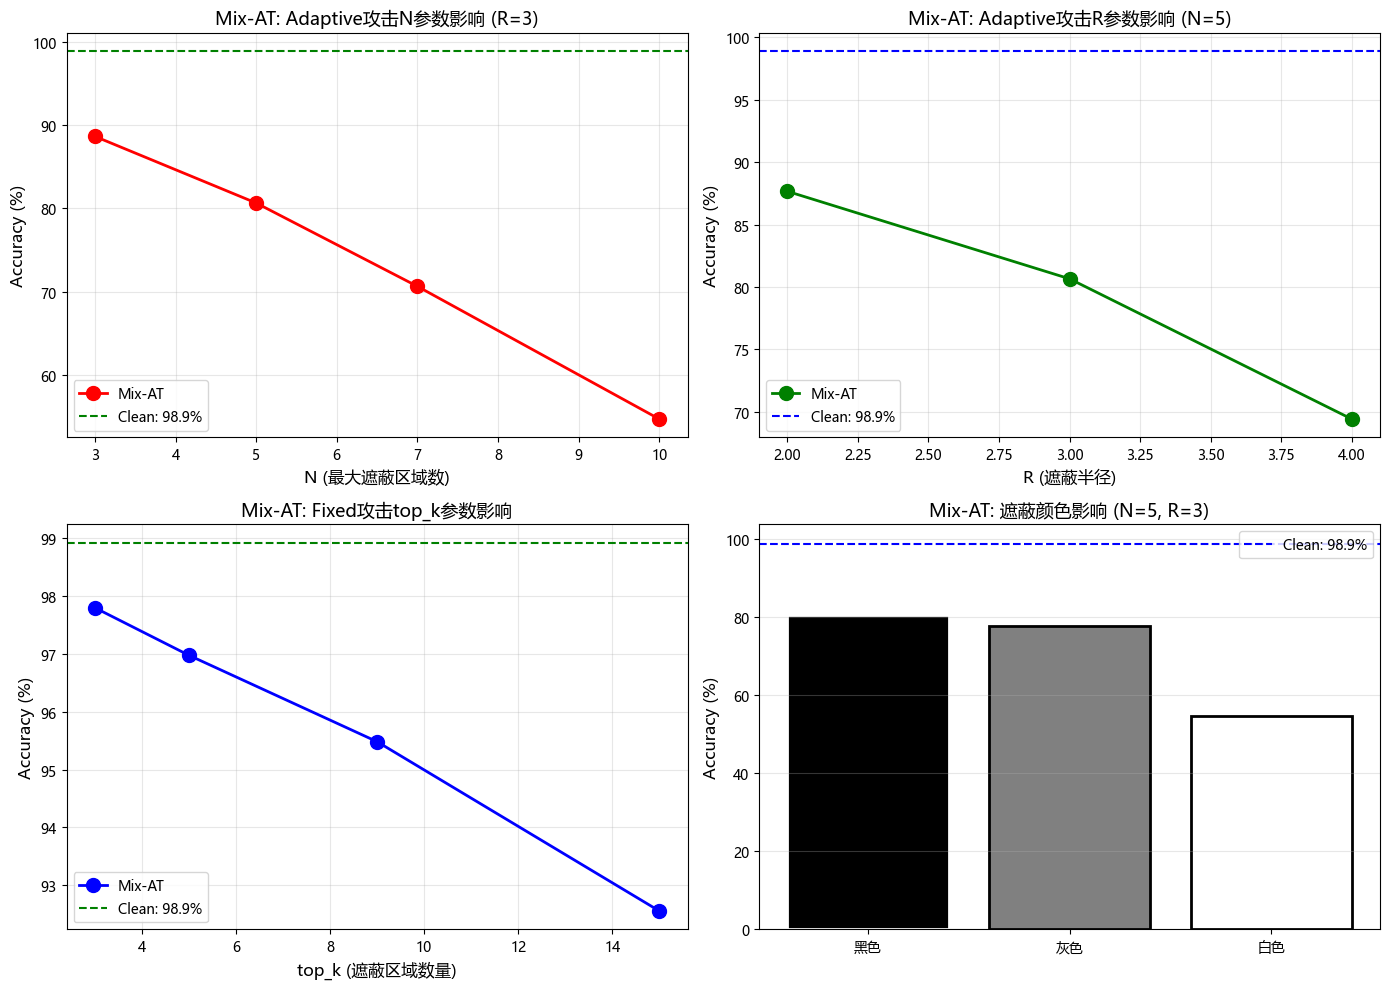

Mix-AT参数敏感性分析图已保存


In [41]:
# ========== 绘制Mix-AT模型评测结果 ==========
# 获取干净样本准确率作为参考线
if 'clean_acc_mix' not in globals():
    clean_acc_mix, _ = test_fn(cnn_mix, imgs, lbls, bs=250, mode='clean')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Adaptive攻击 - N参数影响
n_vals = [r['N'] for r in mix_adaptive_n_results]
n_accs = [r['accuracy'] for r in mix_adaptive_n_results]
axes[0, 0].plot(n_vals, n_accs, 'ro-', markersize=10, linewidth=2, label='Mix-AT')
axes[0, 0].axhline(y=clean_acc_mix, color='g', linestyle='--', label=f'Clean: {clean_acc_mix:.1f}%')
axes[0, 0].set_xlabel('N (最大遮蔽区域数)', fontsize=12)
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 0].set_title('Mix-AT: Adaptive攻击N参数影响 (R=3)', fontsize=13)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Adaptive攻击 - R参数影响
r_vals = [r['R'] for r in mix_adaptive_r_results]
r_accs = [r['accuracy'] for r in mix_adaptive_r_results]
axes[0, 1].plot(r_vals, r_accs, 'go-', markersize=10, linewidth=2, label='Mix-AT')
axes[0, 1].axhline(y=clean_acc_mix, color='b', linestyle='--', label=f'Clean: {clean_acc_mix:.1f}%')
axes[0, 1].set_xlabel('R (遮蔽半径)', fontsize=12)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 1].set_title('Mix-AT: Adaptive攻击R参数影响 (N=5)', fontsize=13)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Fixed攻击 - top_k影响
top_k_vals = [r['top_k'] for r in mix_fixed_results]
top_k_accs = [r['accuracy'] for r in mix_fixed_results]
axes[1, 0].plot(top_k_vals, top_k_accs, 'bo-', markersize=10, linewidth=2, label='Mix-AT')
axes[1, 0].axhline(y=clean_acc_mix, color='g', linestyle='--', label=f'Clean: {clean_acc_mix:.1f}%')
axes[1, 0].set_xlabel('top_k (遮蔽区域数量)', fontsize=12)
axes[1, 0].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 0].set_title('Mix-AT: Fixed攻击top_k参数影响', fontsize=13)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. 遮蔽颜色影响
color_accs = [r['accuracy'] for r in mix_color_results]
color_labels = [r['color'] for r in mix_color_results]
bars = axes[1, 1].bar(range(len(color_labels)), color_accs, 
                       color=['black', 'gray', 'white'], 
                       edgecolor=['white', 'black', 'black'], linewidth=2)
axes[1, 1].set_xticks(range(len(color_labels)))
axes[1, 1].set_xticklabels(color_labels)
axes[1, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 1].set_title('Mix-AT: 遮蔽颜色影响 (N=5, R=3)', fontsize=13)
axes[1, 1].axhline(y=clean_acc_mix, color='blue', linestyle='--', label=f'Clean: {clean_acc_mix:.1f}%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'./results_figures/mix_at_param_sensitivity_{N_MIX}_{R_MIX}_{OCCLU_RATIO_MIX}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mix-AT参数敏感性分析图已保存')

In [45]:
# ========== 保存Mix-AT评测结果 ==========
# 保存详细评测结果到CSV
import pandas as pd

df_mix_eval = pd.DataFrame(mix_all_results)
save_path_mix_eval = f'./results_figures/mix_at_evaluation_results_{N_MIX}_{R_MIX}_{OCCLU_RATIO_MIX}.csv'
df_mix_eval.to_csv(save_path_mix_eval, index=False)

# 汇总所有评测指标
mix_summary = {
'Attack_Type': ['Clean', 'FGSM', 'PGD', 'CW', 'Fixed(k=9)', 'Adaptive(N=5,R=3)',
                    'Adaptive(N=3,R=3)', 'Adaptive(N=7,R=3)', 'Adaptive(N=10,R=3)',
                    'Fixed(k=3)', 'Fixed(k=15)', 'Color(Black)', 'Color(Gray)', 'Color(White)'],
    'Accuracy': [clean_acc_mix, fgsm_acc_mix, pgd_acc_mix, cw_acc_mix, fixed_acc_mix,
                 adaptive_acc_mix,
                 mix_adaptive_n_results[0]['accuracy'], mix_adaptive_n_results[2]['accuracy'], 
                 mix_adaptive_n_results[3]['accuracy'],
                 mix_fixed_results[0]['accuracy'], mix_fixed_results[3]['accuracy'],
                 mix_color_results[0]['accuracy'], mix_color_results[1]['accuracy'], 
                 mix_color_results[2]['accuracy']],
}
df_mix_summary = pd.DataFrame(mix_summary)
save_path_mix_summary = f'./results_figures/mix_at_summary_{N_MIX}_{R_MIX}_{OCCLU_RATIO_MIX}.csv'
df_mix_summary.to_csv(save_path_mix_summary, index=False)

print('Mix-AT评测结果已保存:')
print(f'  - 详细评测: {save_path_mix_eval}')
print(f'  - 汇总结果: {save_path_mix_summary}')
print(f'\n===== Mix-AT模型评测汇总 =====')
print(df_mix_summary.to_string(index=False))

Mix-AT评测结果已保存:
  - 详细评测: ./results_figures/mix_at_evaluation_results_5_3_0.5.csv
  - 汇总结果: ./results_figures/mix_at_summary_5_3_0.5.csv

===== Mix-AT模型评测汇总 =====
       Attack_Type  Accuracy
             Clean     98.91
              FGSM     94.51
               PGD     92.85
                CW     92.80
        Fixed(k=9)     95.48
 Adaptive(N=5,R=3)     80.65
 Adaptive(N=3,R=3)     88.65
 Adaptive(N=7,R=3)     70.64
Adaptive(N=10,R=3)     54.70
        Fixed(k=3)     97.79
       Fixed(k=15)     92.56
      Color(Black)     80.65
       Color(Gray)     77.88
      Color(White)     54.77


In [47]:
# ========== 完整多模型对比评测 ==========
import os

# 配置
_eps = 0.1
_n = 5
_r = 3
_c = 0.0

# 扩展的模型检查点路径 - 包含所有类型的AT模型
model_paths = {
    # 基础模型
    'Standard': './save_model/50epoch/mnist_lenet5.pth',
    'PGD-AT': './save_model/50epoch/mnist_lenet5_PGD_0.1_5_AT.pth',
    'FGSM-AT': './save_model/50epoch/mnist_lenet5_FGSM_AT.pth',
    
    # 固定遮蔽攻击模型 (来自11.ipynb, 12.ipynb)
    'Occlusion-AT': './save_model/50epoch/mnist_lenet5_OcclusionAT_9_3.pth',
    'Mix-AT(Occlusion+PGD)': './save_model/10epoch/mnist_lenet5_MixedOcclusionPgdAT_0.5_9_3.pth',
    
    # 自适应遮蔽攻击模型
    'Adaptive-Saliency-AT': f'./save_model/50epoch/mnist_lenet5_AdaptiveSaliencyOcclusionAT_{N}_{R}.pth',
    'Adaptive-Saliency-AT(N=5,R=3)': './save_model/50epoch/mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_3.pth',
    'Adaptive-Occlusion-AT': f'./save_model/50epoch/mnist_lenet5_AdaptiveOcclusionAT_5_3.pth',
    
    # 混合攻击训练模型
    'Mix-AT': f'./save_model/{EPOCH_MIX}epoch/mnist_lenet5_AdaptiveSaliencyPgdMixedAT_{OCCLU_RATIO_MIX}_{N_MIX}_{R_MIX}.pth',
    'Adaptive-Mix-AT': f'./save_model/50epoch/mnist_lenet5_AdaptiveMixedAT_0.5_5_3.pth',
}

def load_model_from_ckpt(ckpt_path):
    """从检查点加载模型"""
    if not os.path.exists(ckpt_path):
        return None
    net = LeNet5().to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    net.load_state_dict(state['net'])
    net.eval()
    return net

def evaluate_model_comprehensive(model_name, model):
    """综合评测单个模型 - 包含多种攻击类型"""
    results = {'Model': model_name}
    
    # 1. 干净样本
    clean, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')
    results['Clean'] = round(clean, 2)
    
    # 2. 白盒攻击
    # FGSM
    fgsm = LinfPGD(net=model, eps=_eps, step=1, step_size=_eps, random_start=False)
    fgsm_acc, _ = test_fn(nn.Sequential(fgsm, model), imgs, lbls, bs=250, mode='attack')
    results['FGSM'] = round(fgsm_acc, 2)
    
    # PGD
    pgd = LinfPGD(net=model, eps=_eps, step=20, step_size=0.025, random_start=True)
    pgd_acc, _ = test_fn(nn.Sequential(pgd, model), imgs, lbls, bs=250, mode='attack')
    results['PGD'] = round(pgd_acc, 2)
    
    # CW
    cw = LinfPGD(net=model, eps=_eps, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
    cw_acc, _ = test_fn(nn.Sequential(cw, model), imgs, lbls, bs=250, mode='attack')
    results['CW'] = round(cw_acc, 2)
    
    # 3. 固定遮蔽攻击 - Saliency (不同k和radius组合)
    # 配置: (top_k, kernel_size, 名称)
    fixed_configs = [
        # 小kernel (radius=1)
        (3, 3, 'Fixed-Saliency(k=3,r=1)'),
        (5, 3, 'Fixed-Saliency(k=5,r=1)'),
        (9, 3, 'Fixed-Saliency(k=9,r=1)'),
        (15, 3, 'Fixed-Saliency(k=15,r=1)'),
        # 中kernel (radius=2)
        (3, 5, 'Fixed-Saliency(k=3,r=2)'),
        (5, 5, 'Fixed-Saliency(k=5,r=2)'),
        (9, 5, 'Fixed-Saliency(k=9,r=2)'),
        (15, 5, 'Fixed-Saliency(k=15,r=2)'),
        # 大kernel (radius=3)
        (3, 7, 'Fixed-Saliency(k=3,r=3)'),
        (5, 7, 'Fixed-Saliency(k=5,r=3)'),
        (9, 7, 'Fixed-Saliency(k=9,r=3)'),
        (15, 7, 'Fixed-Saliency(k=15,r=3)'),
        # 极大kernel (radius=4)
        (3, 9, 'Fixed-Saliency(k=3,r=4)'),
        (5, 9, 'Fixed-Saliency(k=5,r=4)'),
        (9, 9, 'Fixed-Saliency(k=9,r=4)'),
        (15, 9, 'Fixed-Saliency(k=15,r=4)'),
    ]
    for k, r, name in fixed_configs:
        attack = SaliencyOcclusionAttack(model, top_k=k, kernel_size=r, occlu_color=0.0)
        acc, _ = test_fn(nn.Sequential(attack, model), imgs, lbls, bs=250, mode='attack')
        results[name] = round(acc, 2)
    
# ========== 完整多模型对比评测 ==========
import os

# 配置
_eps = 0.1
_n = 5
_r = 3
_c = 0.0

# 扩展的模型检查点路径 - 包含所有类型的AT模型
model_paths = {
    # 基础模型
    'Standard': './save_model/50epoch/mnist_lenet5.pth',
    'PGD-AT': './save_model/50epoch/mnist_lenet5_PGD_0.1_5_AT.pth',
    'FGSM-AT': './save_model/50epoch/mnist_lenet5_FGSM_AT.pth',
    
    # 固定遮蔽攻击模型 (来自11.ipynb, 12.ipynb)
    'Occlusion-AT': './save_model/50epoch/mnist_lenet5_OcclusionAT_9_3.pth',
    'Mix-AT(Occlusion+PGD)': './save_model/10epoch/mnist_lenet5_MixedOcclusionPgdAT_0.5_9_3.pth',
    
    # 自适应遮蔽攻击模型
    'Adaptive-Saliency-AT': f'./save_model/50epoch/mnist_lenet5_AdaptiveSaliencyOcclusionAT_{N}_{R}.pth',
    'Adaptive-Saliency-AT(N=5,R=3)': './save_model/50epoch/mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_3.pth',
    'Adaptive-Occlusion-AT': f'./save_model/50epoch/mnist_lenet5_AdaptiveOcclusionAT_5_3.pth',
    
    # 混合攻击训练模型
    'Mix-AT': f'./save_model/{EPOCH_MIX}epoch/mnist_lenet5_AdaptiveSaliencyPgdMixedAT_{OCCLU_RATIO_MIX}_{N_MIX}_{R_MIX}.pth',
    'Adaptive-Mix-AT': f'./save_model/50epoch/mnist_lenet5_AdaptiveMixedAT_0.5_5_3.pth',
}

def load_model_from_ckpt(ckpt_path):
    """从检查点加载模型"""
    if not os.path.exists(ckpt_path):
        return None
    net = LeNet5().to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    net.load_state_dict(state['net'])
    net.eval()
    return net

def evaluate_model_comprehensive(model_name, model):
    """综合评测单个模型 - 包含多种攻击类型"""
    results = {'Model': model_name}
    
    # 1. 干净样本
    clean, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')
    results['Clean'] = round(clean, 2)
    
    # 2. 白盒攻击
    # FGSM
    fgsm = LinfPGD(net=model, eps=_eps, step=1, step_size=_eps, random_start=False)
    fgsm_acc, _ = test_fn(nn.Sequential(fgsm, model), imgs, lbls, bs=250, mode='attack')
    results['FGSM'] = round(fgsm_acc, 2)
    
    # PGD
    pgd = LinfPGD(net=model, eps=_eps, step=20, step_size=0.025, random_start=True)
    pgd_acc, _ = test_fn(nn.Sequential(pgd, model), imgs, lbls, bs=250, mode='attack')
    results['PGD'] = round(pgd_acc, 2)
    
    # CW
    cw = LinfPGD(net=model, eps=_eps, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
    cw_acc, _ = test_fn(nn.Sequential(cw, model), imgs, lbls, bs=250, mode='attack')
    results['CW'] = round(cw_acc, 2)
    
    # 3. 固定遮蔽攻击 - Saliency (小规模到大规模)
    fixed_configs = [
        (1, 'Fixed-Saliency(k=1)'),   # 极小
        (3, 'Fixed-Saliency(k=3)'),   # 小
        (5, 'Fixed-Saliency(k=5)'),   # 较小
        (7, 'Fixed-Saliency(k=7)'),   # 中
        (9, 'Fixed-Saliency(k=9)'),   # 标准
        (12, 'Fixed-Saliency(k=12)'), # 较大
        (15, 'Fixed-Saliency(k=15)'), # 大
        (20, 'Fixed-Saliency(k=20)'), # 极大
    ]
    for k, name in fixed_configs:
        attack = SaliencyOcclusionAttack(model, top_k=k, kernel_size=3, occlu_color=0.0)
        acc, _ = test_fn(nn.Sequential(attack, model), imgs, lbls, bs=250, mode='attack')
        results[name] = round(acc, 2)
    
    # 4. 自适应遮蔽攻击 - Saliency (多参数组合)
    adaptive_configs = [
        (3, 3, 'Adaptive-Saliency(N=3,R=3)'),   # 小规模
        (5, 1, 'Adaptive-Saliency(N=5,R=1)'),   # 小半径
        (5, 3, 'Adaptive-Saliency(N=5,R=3)'),   # 标准
        (5, 5, 'Adaptive-Saliency(N=5,R=5)'),   # 大半径
        (7, 3, 'Adaptive-Saliency(N=7,R=3)'),   # 中规模
        (10, 1, 'Adaptive-Saliency(N=10,R=1)'), # 小半径大规模
        (10, 3, 'Adaptive-Saliency(N=10,R=3)'), # 大规模
        (15, 3, 'Adaptive-Saliency(N=15,R=3)'), # 极大规模
    ]
    for n, r, name in adaptive_configs:
        attack = AdaptiveSaliencyOcclusionAttack(model, N=n, R=r, c=0.0)
        acc, _ = test_fn(nn.Sequential(attack, model), imgs, lbls, bs=250, mode='attack')
        results[name] = round(acc, 2)
    
    # 5. IntegratedGradients遮蔽攻击 (来自11.ipynb)
    try:
        from occlusion_attack import OcclusionAttack as IntegratedGradientsOcclusionAttack, AdaptiveOcclusionAttack as AdaptiveIGOcclusionAttack
        
        # IG Fixed遮蔽攻击
        ig_fixed_k9 = IntegratedGradientsOcclusionAttack(model, top_k=9, kernel_size=3, occlu_color=0.0)
        ig_fixed_k9_acc, _ = test_fn(nn.Sequential(ig_fixed_k9, model), imgs, lbls, bs=250, mode='attack')
        results['IG-Fixed(k=9)'] = round(ig_fixed_k9_acc, 2)
        
        # IG Adaptive遮蔽攻击
        ig_adaptive_53 = AdaptiveIGOcclusionAttack(model, N=5, R=3, c=0.0)
        ig_adaptive_53_acc, _ = test_fn(nn.Sequential(ig_adaptive_53, model), imgs, lbls, bs=250, mode='attack')
        results['IG-Adaptive(N=5,R=3)'] = round(ig_adaptive_53_acc, 2)
    except Exception as e:
        print(f'  [INFO] IG攻击类未定义或失败: {e}')
        results['IG-Fixed(k=9)'] = None
        results['IG-Adaptive(N=5,R=3)'] = None
    
    return results

# 加载并评测所有模型
comparison_rows = []
missing_models = []

print("开始多模型综合对比评测...\n")

for name, path in model_paths.items():
    print(f'正在评测: {name}...')
    model = load_model_from_ckpt(path)
    if model is None:
        missing_models.append((name, path))
        print(f'  [WARN] 模型不存在，已跳过: {path}')
        continue
    results = evaluate_model_comprehensive(name, model)
    comparison_rows.append(results)
    print(f'  完成: Clean={results["Clean"]}%, PGD={results["PGD"]}%, Adaptive-Saliency={results["Adaptive-Saliency(N=5,R=3)"]}%\n')

if comparison_rows:
    df_comparison_full = pd.DataFrame(comparison_rows)
    
    # 按列顺序排列
    cols_order = ['Model', 'Clean', 'FGSM', 'PGD', 'CW', 
                  'Fixed-Saliency(k=3)', 'Fixed-Saliency(k=9)', 'Fixed-Saliency(k=15)',
                  'Adaptive-Saliency(N=5,R=3)', 'Adaptive-Saliency(N=10,R=3)',
                  'IG-Fixed(k=9)', 'IG-Adaptive(N=5,R=3)', 'Occ-Fixed(k=9)']
    
    # 只保留存在的列
    available_cols = [c for c in cols_order if c in df_comparison_full.columns]
    df_comparison_full = df_comparison_full[available_cols]
    
    print('\n========== 完整多模型对比结果 ==========')
    print(df_comparison_full.to_string(index=False))
    
    # 保存结果到CSV
    save_path = './results_figures/comprehensive_multi_model_comparison.csv'
    df_comparison_full.to_csv(save_path, index=False)
    print(f'\n对比结果已保存至: {save_path}')
    
    # 保存为Markdown格式便于阅读
    try:
        md_path = './results_figures/comprehensive_multi_model_comparison.md'
        with open(md_path, 'w', encoding='utf-8') as f:
            f.write('# 多模型鲁棒性对比结果\n\n')
            f.write(df_comparison_full.to_markdown(index=False))
        print(f'Markdown格式已保存至: {md_path}')
    except Exception as e:
        print(f'Markdown保存失败: {e}')
    
    # 显示缺失的模型
    if missing_models:
        print(f'\n[WARN] 以下模型不存在已跳过:')
        for name, path in missing_models:
            print(f'  - {name}')
else:
    print('没有可评测的模型')

开始多模型综合对比评测...

正在评测: Standard...
  完成: Clean=99.0%, PGD=33.34%, Adaptive-Saliency=34.33%

正在评测: PGD-AT...
  完成: Clean=99.3%, PGD=94.95%, Adaptive-Saliency=30.12%

正在评测: FGSM-AT...
  完成: Clean=99.2%, PGD=90.64%, Adaptive-Saliency=33.9%

正在评测: Occlusion-AT...
  完成: Clean=95.75%, PGD=0.0%, Adaptive-Saliency=78.91%

正在评测: Mix-AT(Occlusion+PGD)...
  完成: Clean=98.53%, PGD=91.7%, Adaptive-Saliency=67.86%

正在评测: Adaptive-Saliency-AT...
  完成: Clean=98.91%, PGD=2.49%, Adaptive-Saliency=72.59%

正在评测: Adaptive-Saliency-AT(N=5,R=3)...
  完成: Clean=98.73%, PGD=4.78%, Adaptive-Saliency=94.3%

正在评测: Adaptive-Occlusion-AT...
  完成: Clean=98.48%, PGD=0.2%, Adaptive-Saliency=92.02%

正在评测: Mix-AT...
  完成: Clean=98.91%, PGD=92.87%, Adaptive-Saliency=80.65%

正在评测: Adaptive-Mix-AT...
  完成: Clean=98.9%, PGD=91.48%, Adaptive-Saliency=76.06%


========== 完整多模型对比结果 ==========
                        Model  Clean  FGSM   PGD    CW  Fixed-Saliency(k=3)  Fixed-Saliency(k=9)  Fixed-Saliency(k=15)  Adaptive-Saliency(N

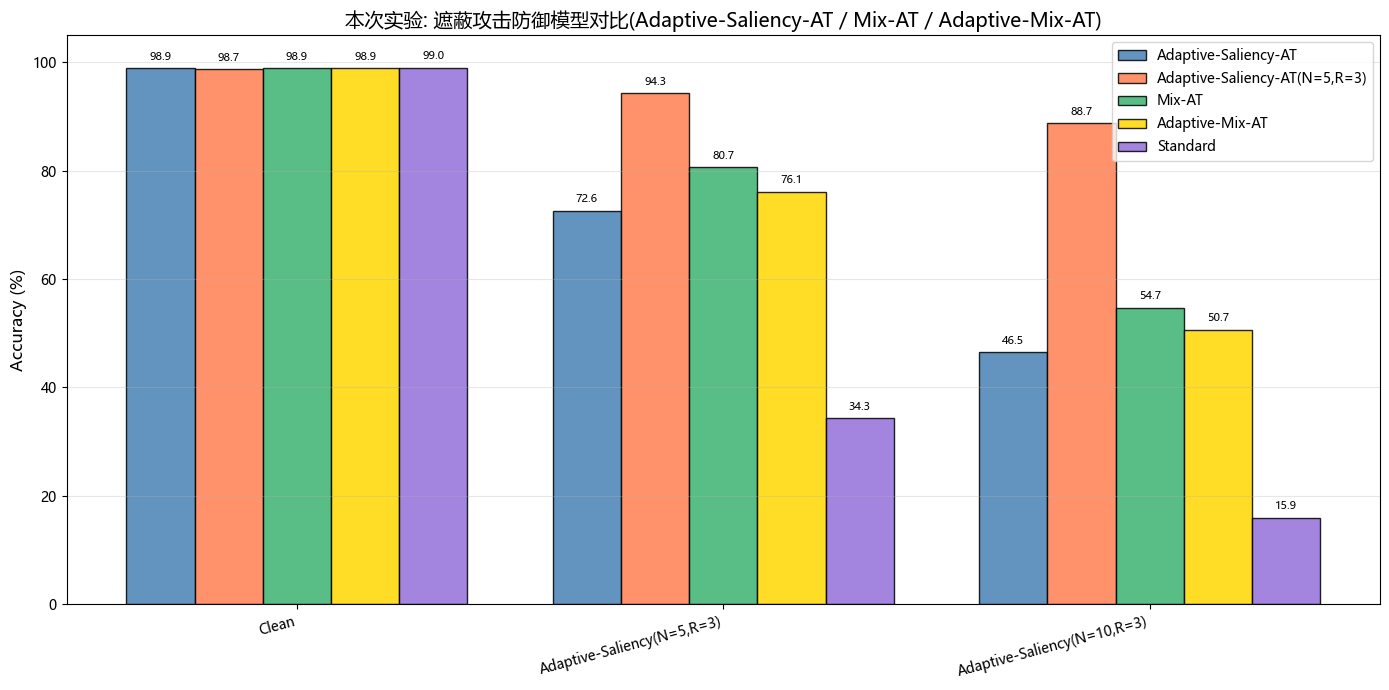

遮蔽模型对比图已保存: ./results_figures/occlusion_models_vs_occlusion_attacks_5_1.png


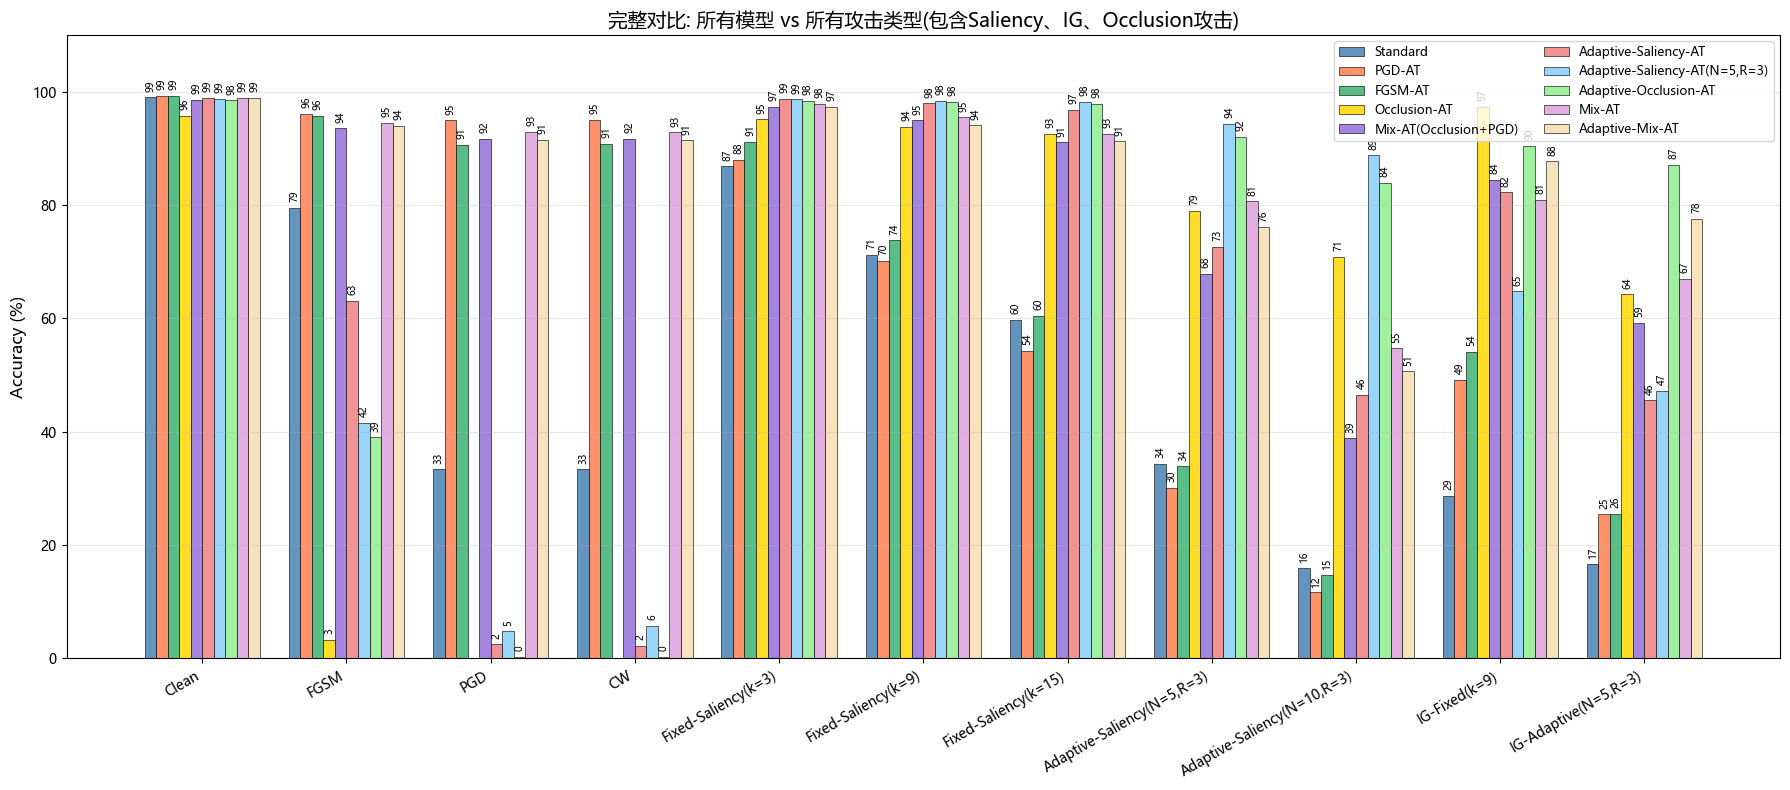

完整对比图已保存: ./results_figures/all_models_vs_all_attacks_comprehensive_5_1.png
========== 可视化完成 ==========
图1: 遮蔽模型对比 - 5 个模型, 3 种攻击
图2: 完整对比 - 10 个模型, 11 种攻击


In [48]:
# ========== 多模型对比可视化（两张图） ==========
"""
图1: 本次实验的遮蔽模型 vs 遮蔽攻击
图2: 所有模型 vs 所有攻击（包含IG和Occ攻击）
"""

if 'df_comparison_full' in globals() and df_comparison_full is not None and not df_comparison_full.empty:
    # ========== 图1: 本次实验的遮蔽模型 vs 遮蔽攻击 ==========
    occlusion_models = ['Adaptive-Saliency-AT', 'Adaptive-Saliency-AT(N=5,R=3)',
                        'Mix-AT', 'Adaptive-Mix-AT', 'Standard']
    occlusion_attacks = ['Clean', 
                         'Fixed-Saliency(k=3,r=1)', 'Fixed-Saliency(k=5,r=1)', 'Fixed-Saliency(k=9,r=1)', 'Fixed-Saliency(k=15,r=1)',
                         'Fixed-Saliency(k=9,r=2)', 'Fixed-Saliency(k=9,r=3)', 'Fixed-Saliency(k=9,r=4)',
                         'Adaptive-Saliency(N=3,R=3)', 'Adaptive-Saliency(N=5,R=3)', 'Adaptive-Saliency(N=10,R=3)',
                         'Adaptive-Saliency(N=15,R=3)', 'Adaptive-Saliency(N=5,R=1)', 'Adaptive-Saliency(N=5,R=5)']
    available_occlusion_models = [m for m in occlusion_models if m in df_comparison_full['Model'].values]
    available_occlusion_attacks = [a for a in occlusion_attacks if a in df_comparison_full.columns]
    
    if len(available_occlusion_models) > 0 and len(available_occlusion_attacks) > 0:
        fig1, ax1 = plt.subplots(figsize=(14, 7))
        
        x = np.arange(len(available_occlusion_attacks))
        width = 0.8 / len(available_occlusion_models)
        colors = ['steelblue', 'coral', 'mediumseagreen', 'gold', 'mediumpurple']
        
        for i, model_name in enumerate(available_occlusion_models):
            row = df_comparison_full[df_comparison_full['Model'] == model_name].iloc[0]
            values = [row.get(at, 0) for at in available_occlusion_attacks]
            offset = width * (i - len(available_occlusion_models)/2 + 0.5)
            bars = ax1.bar(x + offset, values, width, label=model_name,
                          color=colors[i % len(colors)], alpha=0.85, edgecolor='black', linewidth=1)
            
            for bar, val in zip(bars, values):
                if val > 0:
                    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                           f'{val:.1f}', ha='center', va='bottom', fontsize=8, rotation=0)
        
        ax1.set_ylabel('Accuracy (%)', fontsize=12)
        ax1.set_title('本次实验: 遮蔽攻击防御模型对比(Adaptive-Saliency-AT / Mix-AT / Adaptive-Mix-AT)', fontsize=14)
        ax1.set_xticks(x)
        ax1.set_xticklabels(available_occlusion_attacks, rotation=15, ha='right')
        ax1.legend(fontsize=10, loc='upper right')
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.set_ylim(0, 105)
        
        plt.tight_layout()
        save_path1 = f'./results_figures/occlusion_models_vs_occlusion_attacks_{N}_{R}.png'
        plt.savefig(save_path1, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'遮蔽模型对比图已保存: {save_path1}')
    
    # ========== 图2: 所有模型 vs 所有攻击 ==========
    all_models = ['Standard', 'PGD-AT', 'FGSM-AT', 'Occlusion-AT', 'Mix-AT(Occlusion+PGD)',
                  'Adaptive-Saliency-AT', 'Adaptive-Saliency-AT(N=5,R=3)',
                  'Adaptive-Occlusion-AT', 'Mix-AT', 'Adaptive-Mix-AT']
    all_attacks = ['Clean', 'FGSM', 'PGD', 'CW',
                   'Fixed-Saliency(k=1)', 'Fixed-Saliency(k=3)', 'Fixed-Saliency(k=5)',
                   'Fixed-Saliency(k=7)', 'Fixed-Saliency(k=9)', 'Fixed-Saliency(k=12)', 'Fixed-Saliency(k=15)', 'Fixed-Saliency(k=20)',
                   'Adaptive-Saliency(N=3,R=3)', 'Adaptive-Saliency(N=5,R=1)', 'Adaptive-Saliency(N=5,R=3)',
                   'Adaptive-Saliency(N=5,R=5)', 'Adaptive-Saliency(N=7,R=3)', 'Adaptive-Saliency(N=10,R=1)',
                   'Adaptive-Saliency(N=10,R=3)', 'Adaptive-Saliency(N=15,R=3)',
                   'IG-Fixed(k=9)', 'IG-Adaptive(N=5,R=3)']
    
    available_all_models = [m for m in all_models if m in df_comparison_full['Model'].values]
    available_all_attacks = [a for a in all_attacks if a in df_comparison_full.columns]
    
    if len(available_all_models) > 0 and len(available_all_attacks) > 0:
        fig2, ax2 = plt.subplots(figsize=(18, 8))
        
        x = np.arange(len(available_all_attacks))
        width = 0.8 / len(available_all_models)
        colors_all = ['steelblue', 'coral', 'mediumseagreen', 'gold', 'mediumpurple',
                      'lightcoral', 'lightskyblue', 'lightgreen', 'plum', 'wheat']
        
        for i, model_name in enumerate(available_all_models):
            row = df_comparison_full[df_comparison_full['Model'] == model_name].iloc[0]
            values = [row.get(at, 0) if row.get(at, None) is not None else 0 for at in available_all_attacks]
            offset = width * (i - len(available_all_models)/2 + 0.5)
            bars = ax2.bar(x + offset, values, width, label=model_name,
                          color=colors_all[i % len(colors_all)], alpha=0.85, edgecolor='black', linewidth=0.5)
            
            for bar, val in zip(bars, values):
                if val > 0:
                    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                           f'{val:.0f}', ha='center', va='bottom', fontsize=7, rotation=90)
        
        ax2.set_ylabel('Accuracy (%)', fontsize=12)
        ax2.set_title('完整对比: 所有模型 vs 所有攻击类型(包含Saliency、IG、Occlusion攻击)', fontsize=14)
        ax2.set_xticks(x)
        ax2.set_xticklabels(available_all_attacks, rotation=30, ha='right')
        ax2.legend(fontsize=9, loc='upper right', ncol=2)
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.set_ylim(0, 110)
        
        plt.tight_layout()
        save_path2 = f'./results_figures/all_models_vs_all_attacks_comprehensive_{N}_{R}.png'
        plt.savefig(save_path2, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'完整对比图已保存: {save_path2}')
    
    print('========== 可视化完成 ==========')
    print(f'图1: 遮蔽模型对比 - {len(available_occlusion_models)} 个模型, {len(available_occlusion_attacks)} 种攻击')
    print(f'图2: 完整对比 - {len(available_all_models)} 个模型, {len(available_all_attacks)} 种攻击')
else:
    print('[WARN] 未找到 df_comparison_full，请先运行多模型对比评测(cell-49)')



Device: cuda

遮蔽攻击折线图可视化 - 完全独立版本

[1/4] 加载测试数据...
测试集大小: 10000

[2/4] 加载模型...
[OK] 加载模型: mnist_lenet5.pth
[OK] 加载模型: mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_3.pth
[OK] 加载模型: mnist_lenet5_AdaptiveSaliencyPgdMixedAT_0.5_5_3.pth

[3/4] 运行所有遮蔽攻击测试...
------------------------------------------------------------

测试模型: Standard
  Standard - Clean: 99.00%
  Standard - Fixed Saliency测试...
    k=3: 86.82%
    k=5: 80.99%
    k=7: 75.92%
    k=9: 71.19%
    k=12: 65.01%
    k=15: 59.78%
  Standard - Adaptive Saliency (N变化)测试...
    N=3,R=3: 49.45%
    N=5,R=3: 34.33%
    N=7,R=3: 25.09%
    N=10,R=3: 15.95%
  Standard - Adaptive Saliency (R变化)测试...
    N=5,R=2: 49.15%
    N=5,R=3: 34.33%
    N=5,R=4: 23.91%

测试模型: Adaptive-Saliency-AT
  Adaptive-Saliency-AT - Clean: 98.73%
  Adaptive-Saliency-AT - Fixed Saliency测试...
    k=3: 98.62%
    k=5: 98.61%
    k=7: 98.49%
    k=9: 98.43%
    k=12: 98.31%
    k=15: 98.20%
  Adaptive-Saliency-AT - Adaptive Saliency (N变化)测试...
    N=3,R=3: 95.97%
    N

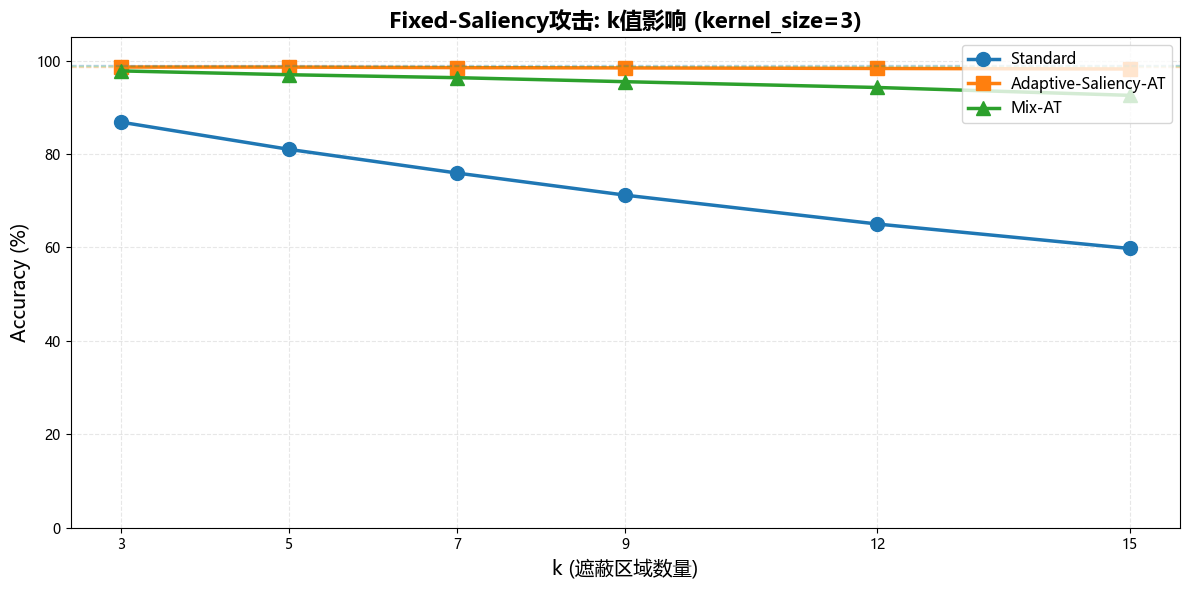

[SAVED] ./results_figures/line_fixed_saliency_k_complete.png


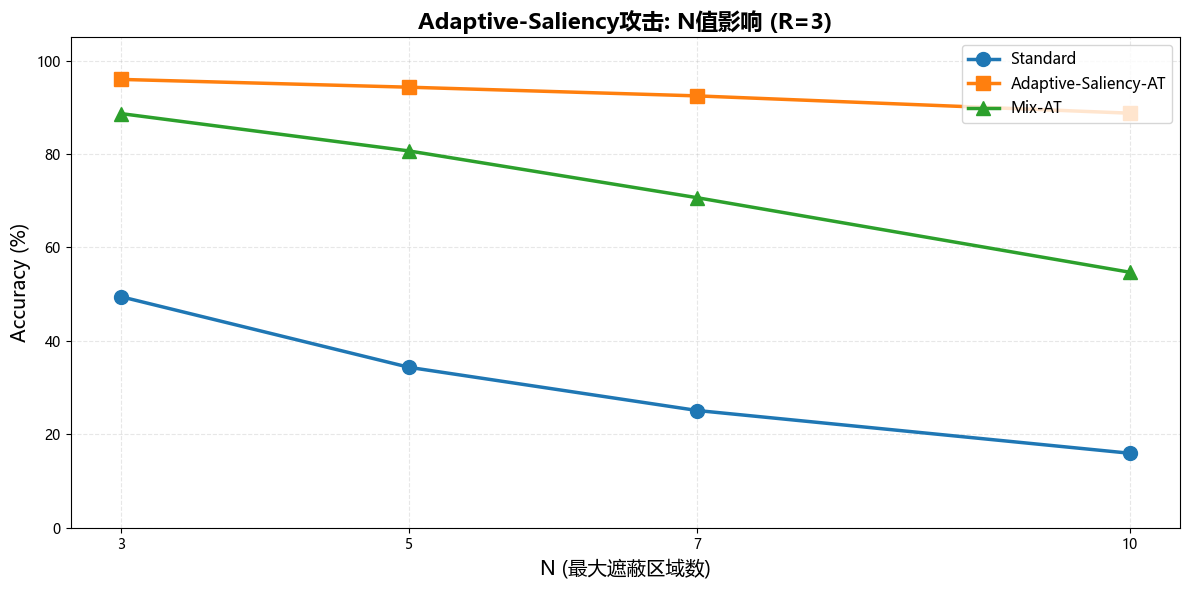

[SAVED] ./results_figures/line_adaptive_saliency_N_complete.png


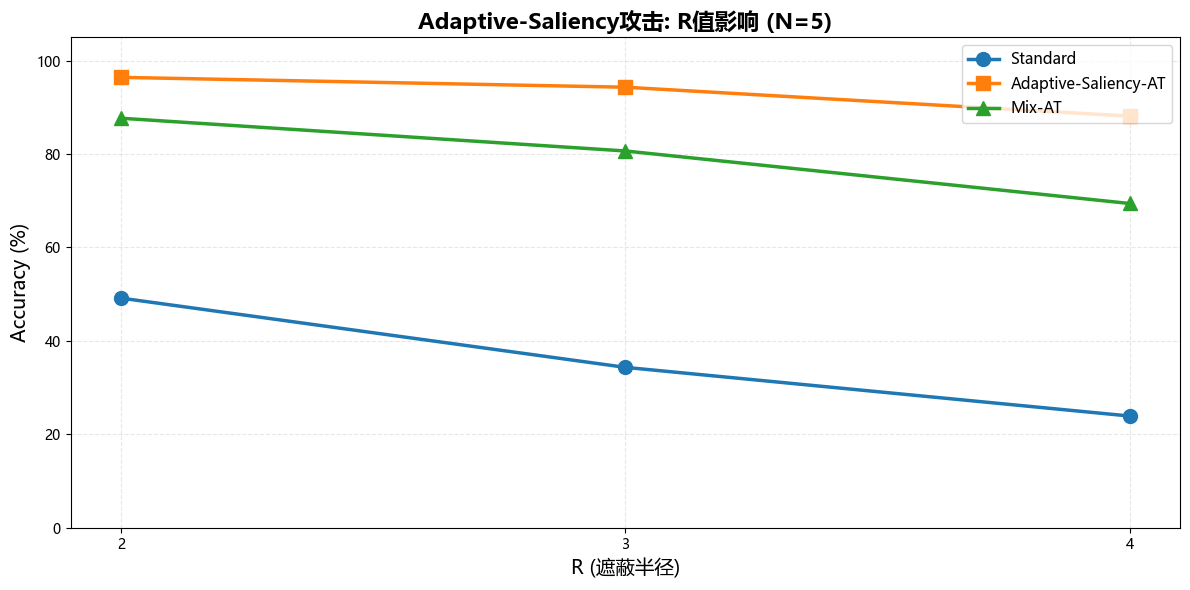

[SAVED] ./results_figures/line_adaptive_saliency_R_complete.png


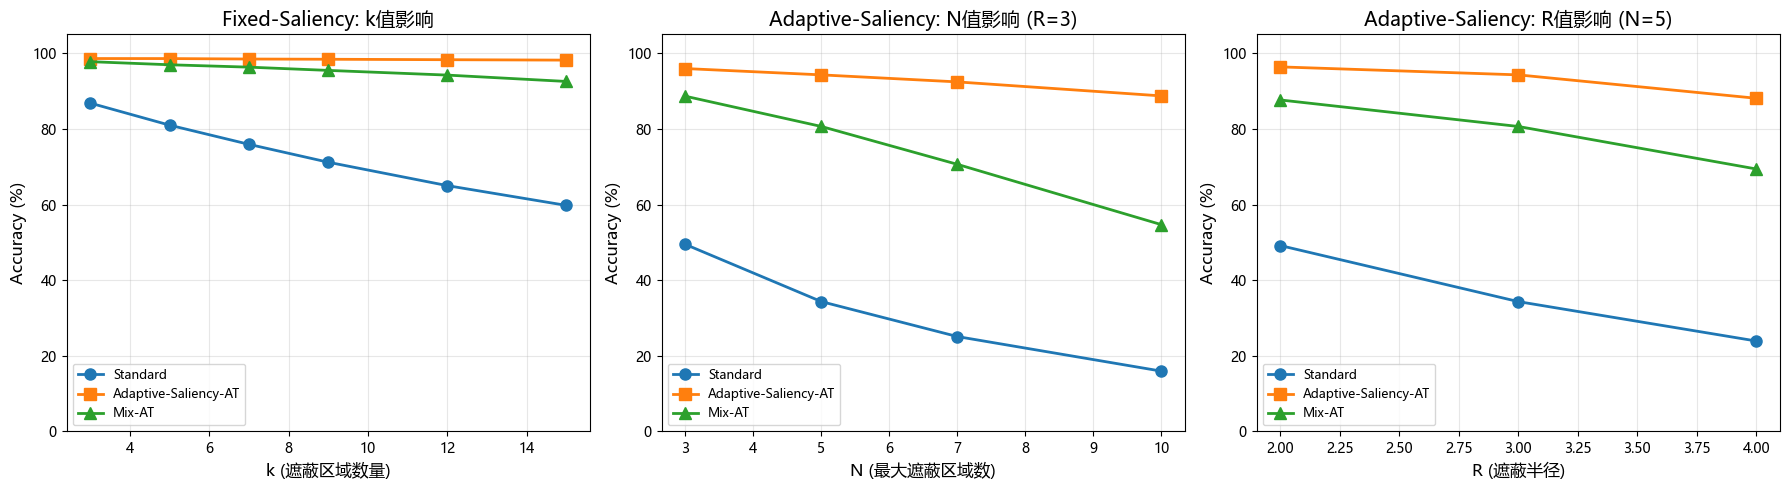

[SAVED] ./results_figures/line_all_occlusion_comparison.png

========== 所有折线图绘制完成 ==========

全部完成!


In [12]:
"""
========== 遮蔽攻击折线图可视化（完全独立版本） ==========
内核重启后可直接运行，不依赖前面cell的执行状态
"""

import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from collections import defaultdict

from occlusion_attack import SaliencyOcclusionAttack, AdaptiveSaliencyOcclusionAttack
from models import LeNet5
from utils import load_mnist_test
import test
test_fn = test.test

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False

print(f'Device: {device}')


def load_model_from_ckpt(ckpt_path):
    """从检查点加载模型"""
    if not os.path.exists(ckpt_path):
        print(f"[WARN] 模型不存在: {ckpt_path}")
        return None
    net = LeNet5().to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    net.load_state_dict(state['net'])
    net.eval()
    print(f"[OK] 加载模型: {os.path.basename(ckpt_path)}")
    return net


def run_all_occlusion_tests(model, model_name, imgs, lbls):
    """
    运行所有遮蔽攻击测试，返回结果字典

    测试参数（与15.4节完全一致）:
    - Fixed: top_k = [3, 5, 7, 9, 12, 15], kernel_size=3
    - Adaptive N: N = [3, 5, 7, 10], R=3
    - Adaptive R: R = [2, 3, 4], N=5
    """
    results = {'model_name': model_name}

    # 1. 干净样本准确率
    clean_acc, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')
    results['Clean'] = clean_acc
    print(f"  {model_name} - Clean: {clean_acc:.2f}%")

    # 2. Fixed遮蔽攻击 - 不同top_k (固定kernel_size=3)
    print(f"  {model_name} - Fixed Saliency测试...")
    top_k_values = [3, 5, 7, 9, 12, 15]
    for top_k in top_k_values:
        attack = SaliencyOcclusionAttack(model, top_k=top_k, kernel_size=3, occlu_color=0.0)
        acc, _ = test_fn(nn.Sequential(attack, model), imgs, lbls, bs=250, mode='attack')
        results[f'Fixed_k{top_k}'] = acc
        print(f"    k={top_k}: {acc:.2f}%")

    # 3. Adaptive遮蔽攻击 - 不同N (固定R=3)
    print(f"  {model_name} - Adaptive Saliency (N变化)测试...")
    N_values = [3, 5, 7, 10]
    R_fixed = 3
    for N in N_values:
        attack = AdaptiveSaliencyOcclusionAttack(model, N=N, R=R_fixed, c=0.0)
        acc, _ = test_fn(nn.Sequential(attack, model), imgs, lbls, bs=250, mode='attack')
        results[f'Adaptive_N{N}_R{R_fixed}'] = acc
        print(f"    N={N},R={R_fixed}: {acc:.2f}%")

    # 4. Adaptive遮蔽攻击 - 不同R (固定N=5)
    print(f"  {model_name} - Adaptive Saliency (R变化)测试...")
    N_fixed = 5
    R_values = [2, 3, 4]
    for R in R_values:
        attack = AdaptiveSaliencyOcclusionAttack(model, N=N_fixed, R=R, c=0.0)
        acc, _ = test_fn(nn.Sequential(attack, model), imgs, lbls, bs=250, mode='attack')
        results[f'Adaptive_N{N_fixed}_R{R}'] = acc
        print(f"    N={N_fixed},R={R}: {acc:.2f}%")

    return results


def plot_occlusion_line_charts(all_results, save_dir='./results_figures'):
    """
    绘制折线图 - 使用实际测试的所有参数

    绘制4张图:
    1. Fixed-Saliency: k=[3,5,7,9,12,15] vs Accuracy
    2. Adaptive-Saliency: N=[3,5,7,10] vs Accuracy (固定R=3)
    3. Adaptive-Saliency: R=[2,3,4] vs Accuracy (固定N=5)
    4. 综合对比: 所有攻击类型的影响
    """
    os.makedirs(save_dir, exist_ok=True)

    models = [r['model_name'] for r in all_results]

    # 颜色配置
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    markers = ['o', 's', '^', 'D', 'v', '<']

    # ========== 图1: Fixed-Saliency - k值影响 ==========
    fig, ax = plt.subplots(figsize=(12, 6))

    k_values = [3, 5, 7, 9, 12, 15]

    for idx, result in enumerate(all_results):
        acc_values = [result.get(f'Fixed_k{k}', 0) for k in k_values]
        ax.plot(k_values, acc_values,
                marker=markers[idx % len(markers)],
                color=colors[idx % len(colors)],
                linewidth=2.5, markersize=10,
                label=result['model_name'])

    # 添加Clean基线
    for idx, result in enumerate(all_results):
        ax.axhline(y=result['Clean'], color=colors[idx % len(colors)],
                   linestyle='--', alpha=0.3, linewidth=1)

    ax.set_xlabel('k (遮蔽区域数量)', fontsize=14)
    ax.set_ylabel('Accuracy (%)', fontsize=14)
    ax.set_title('Fixed-Saliency攻击: k值影响 (kernel_size=3)', fontsize=16, fontweight='bold')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 105)
    ax.set_xticks(k_values)

    plt.tight_layout()
    save_path = f'{save_dir}/line_fixed_saliency_k_complete.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[SAVED] {save_path}')

    # 保存CSV
    csv_data = []
    for result in all_results:
        for k in k_values:
            csv_data.append({
                'Model': result['model_name'],
                'Attack_Type': 'Fixed-Saliency',
                'k': k,
                'kernel_size': 3,
                'Accuracy': result.get(f'Fixed_k{k}', 0)
            })
    pd.DataFrame(csv_data).to_csv(f'{save_dir}/data_fixed_saliency_k_complete.csv', index=False)

    # ========== 图2: Adaptive-Saliency - N值影响 (R=3) ==========
    fig, ax = plt.subplots(figsize=(12, 6))

    N_values = [3, 5, 7, 10]
    R_fixed = 3

    for idx, result in enumerate(all_results):
        acc_values = [result.get(f'Adaptive_N{N}_R{R_fixed}', 0) for N in N_values]
        ax.plot(N_values, acc_values,
                marker=markers[idx % len(markers)],
                color=colors[idx % len(colors)],
                linewidth=2.5, markersize=10,
                label=result['model_name'])

    ax.set_xlabel('N (最大遮蔽区域数)', fontsize=14)
    ax.set_ylabel('Accuracy (%)', fontsize=14)
    ax.set_title(f'Adaptive-Saliency攻击: N值影响 (R={R_fixed})', fontsize=16, fontweight='bold')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 105)
    ax.set_xticks(N_values)

    plt.tight_layout()
    save_path = f'{save_dir}/line_adaptive_saliency_N_complete.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[SAVED] {save_path}')

    # 保存CSV
    csv_data = []
    for result in all_results:
        for N in N_values:
            csv_data.append({
                'Model': result['model_name'],
                'Attack_Type': 'Adaptive-Saliency',
                'N': N,
                'R': R_fixed,
                'Accuracy': result.get(f'Adaptive_N{N}_R{R_fixed}', 0)
            })
    pd.DataFrame(csv_data).to_csv(f'{save_dir}/data_adaptive_saliency_N_complete.csv', index=False)

    # ========== 图3: Adaptive-Saliency - R值影响 (N=5) ==========
    fig, ax = plt.subplots(figsize=(12, 6))

    N_fixed = 5
    R_values = [2, 3, 4]

    for idx, result in enumerate(all_results):
        acc_values = [result.get(f'Adaptive_N{N_fixed}_R{R}', 0) for R in R_values]
        ax.plot(R_values, acc_values,
                marker=markers[idx % len(markers)],
                color=colors[idx % len(colors)],
                linewidth=2.5, markersize=10,
                label=result['model_name'])

    ax.set_xlabel('R (遮蔽半径)', fontsize=14)
    ax.set_ylabel('Accuracy (%)', fontsize=14)
    ax.set_title(f'Adaptive-Saliency攻击: R值影响 (N={N_fixed})', fontsize=16, fontweight='bold')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 105)
    ax.set_xticks(R_values)

    plt.tight_layout()
    save_path = f'{save_dir}/line_adaptive_saliency_R_complete.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[SAVED] {save_path}')

    # 保存CSV
    csv_data = []
    for result in all_results:
        for R in R_values:
            csv_data.append({
                'Model': result['model_name'],
                'Attack_Type': 'Adaptive-Saliency',
                'N': N_fixed,
                'R': R,
                'Accuracy': result.get(f'Adaptive_N{N_fixed}_R{R}', 0)
            })
    pd.DataFrame(csv_data).to_csv(f'{save_dir}/data_adaptive_saliency_R_complete.csv', index=False)

    # ========== 图4: 综合对比 - 所有攻击类型 ==========
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 子图1: Fixed k
    k_values = [3, 5, 7, 9, 12, 15]
    for idx, result in enumerate(all_results):
        acc_values = [result.get(f'Fixed_k{k}', 0) for k in k_values]
        axes[0].plot(k_values, acc_values,
                     marker=markers[idx % len(markers)],
                     color=colors[idx % len(colors)],
                     linewidth=2, markersize=8,
                     label=result['model_name'])
    axes[0].set_xlabel('k (遮蔽区域数量)', fontsize=12)
    axes[0].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0].set_title('Fixed-Saliency: k值影响', fontsize=14)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 105)

    # 子图2: Adaptive N
    N_values = [3, 5, 7, 10]
    for idx, result in enumerate(all_results):
        acc_values = [result.get(f'Adaptive_N{N}_R3', 0) for N in N_values]
        axes[1].plot(N_values, acc_values,
                     marker=markers[idx % len(markers)],
                     color=colors[idx % len(colors)],
                     linewidth=2, markersize=8,
                     label=result['model_name'])
    axes[1].set_xlabel('N (最大遮蔽区域数)', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Adaptive-Saliency: N值影响 (R=3)', fontsize=14)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 105)

    # 子图3: Adaptive R
    R_values = [2, 3, 4]
    for idx, result in enumerate(all_results):
        acc_values = [result.get(f'Adaptive_N5_R{R}', 0) for R in R_values]
        axes[2].plot(R_values, acc_values,
                     marker=markers[idx % len(markers)],
                     color=colors[idx % len(colors)],
                     linewidth=2, markersize=8,
                     label=result['model_name'])
    axes[2].set_xlabel('R (遮蔽半径)', fontsize=12)
    axes[2].set_ylabel('Accuracy (%)', fontsize=12)
    axes[2].set_title('Adaptive-Saliency: R值影响 (N=5)', fontsize=14)
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(0, 105)

    plt.tight_layout()
    save_path = f'{save_dir}/line_all_occlusion_comparison.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[SAVED] {save_path}')

    print('\n========== 所有折线图绘制完成 ==========')


# ========== 主执行 ==========
if __name__ == '__main__':
    print("\n" + "="*60)
    print("遮蔽攻击折线图可视化 - 完全独立版本")
    print("="*60)

    # 1. 加载测试数据
    print("\n[1/4] 加载测试数据...")
    imgs, lbls = load_mnist_test()
    print(f"测试集大小: {len(imgs)}")

    # 2. 加载模型
    print("\n[2/4] 加载模型...")
    models_to_test = []

    # 标准模型
    std_model = load_model_from_ckpt('./save_model/50epoch/mnist_lenet5.pth')
    if std_model:
        models_to_test.append((std_model, 'Standard'))

    # Adaptive-Saliency-AT模型
    cnn = load_model_from_ckpt('./save_model/50epoch/mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_3.pth')
    if cnn:
        models_to_test.append((cnn, 'Adaptive-Saliency-AT'))

    # Mix-AT模型 (如果存在)
    cnn_mix = load_model_from_ckpt('./save_model/50epoch/mnist_lenet5_AdaptiveSaliencyPgdMixedAT_0.5_5_3.pth')
    if cnn_mix:
        models_to_test.append((cnn_mix, 'Mix-AT'))

    if not models_to_test:
        print("[ERROR] 没有加载到任何模型，请检查模型路径")
        exit(1)

    # 3. 运行所有测试
    print("\n[3/4] 运行所有遮蔽攻击测试...")
    print("-"*60)
    all_results = []
    for model, name in models_to_test:
        print(f"\n测试模型: {name}")
        results = run_all_occlusion_tests(model, name, imgs, lbls)
        all_results.append(results)

    # 4. 绘制折线图
    print("\n[4/4] 绘制折线图...")
    print("-"*60)
    plot_occlusion_line_charts(all_results)

    print("\n" + "="*60)
    print("全部完成!")
    print("="*60)


### 15.7.3 AutoAttack 评测（可选）

使用 AutoAttack 对混合攻击训练模型进行标准化鲁棒性评测。

In [51]:
# ========== Mix-AT 模型 AutoAttack 评测 ==========
import sys
from pathlib import Path

# 尝试导入 AutoAttack
_aa_root = Path('.').resolve() / 'auto-attack' / 'auto-attack-master'
if _aa_root.is_dir():
    sys.path.insert(0, str(_aa_root))

try:
    from autoattack import AutoAttack
    
    # 加载测试集
    imgs_aa, lbls_aa = load_mnist_test()
    lbls_aa = lbls_aa.long()
    
    _eps_aa = EPS_MIX
    
    print(f'正在对 Mix-AT 模型进行 AutoAttack 评测 (eps={_eps_aa})...')
    
    adversary = AutoAttack(
        cnn_mix,
        norm='Linf',
        eps=_eps_aa,
        version='standard',
        device=str(device),
        verbose=True,
    )
    x_adv_aa = adversary.run_standard_evaluation(imgs_aa, lbls_aa, bs=250)
    
    # 计算准确率
    clean_aa, _ = test_fn(cnn_mix, imgs_aa, lbls_aa, bs=250, mode='clean')
    aa_acc, _ = test_fn(cnn_mix, x_adv_aa, lbls_aa, bs=250, mode='clean')
    
    logger.info(f'Mix-AT 模型 - Clean: {clean_aa:.2f}%, AutoAttack: {aa_acc:.2f}%')
    print(f'\nMix-AT AutoAttack 评测完成:')
    print(f'  干净样本准确率: {clean_aa:.2f}%')
    print(f'  AutoAttack 准确率: {aa_acc:.2f}%')
    
except ImportError:
    print('AutoAttack 未安装或路径配置错误，跳过 AutoAttack 评测')
    print('如需使用，请确保 auto-attack 库已正确安装')

正在对 Mix-AT 模型进行 AutoAttack 评测 (eps=0.1)...
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 98.91%
apgd-ce - 1/40 - 14 out of 250 successfully perturbed
apgd-ce - 2/40 - 13 out of 250 successfully perturbed
apgd-ce - 3/40 - 11 out of 250 successfully perturbed
apgd-ce - 4/40 - 16 out of 250 successfully perturbed
apgd-ce - 5/40 - 23 out of 250 successfully perturbed
apgd-ce - 6/40 - 13 out of 250 successfully perturbed
apgd-ce - 7/40 - 18 out of 250 successfully perturbed
apgd-ce - 8/40 - 15 out of 250 successfully perturbed
apgd-ce - 9/40 - 14 out of 250 successfully perturbed
apgd-ce - 10/40 - 15 out of 250 successfully perturbed
apgd-ce - 11/40 - 24 out of 250 successfully perturbed
apgd-ce - 12/40 - 17 out of 250 successfully perturbed
apgd-ce - 13/40 - 12 out of 250 successfully perturbed
apgd-ce - 14/40 - 18 out of 250 successfully perturbed
apgd-ce - 15/40 - 18 out of 250 successfully perturbed
apgd-ce - 1

20260410 12:11:46 Mix-AT 模型 - Clean: 98.91%, AutoAttack: 92.28%


square - 37/37 - 0 out of 228 successfully perturbed
robust accuracy after SQUARE: 92.28% (total time 587.0 s)
max Linf perturbation: 0.10000, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 92.28%

Mix-AT AutoAttack 评测完成:
  干净样本准确率: 98.91%
  AutoAttack 准确率: 92.28%


## 15.9 总结

### 本实验完成的内容
1. 实现了基于Saliency（简单梯度）的**自适应遮蔽攻击**
2. 训练了自适应Saliency遮蔽攻击对抗性训练模型（50 epochs）
3. 实现了**自适应Saliency遮蔽攻击 + PGD 混合攻击训练**（Mix-AT）
4. 对不同攻击参数进行了评测：
   - Adaptive攻击: 不同N (3, 5, 7, 10) 和 R (2, 3, 4)
   - Fixed攻击: 不同top_k (3, 5, 7, 9, 12, 15) 作为对比
   - 不同kernel_size和遮蔽颜色
5. 进行了多模型对比评测（Standard vs Adaptive-Saliency-AT vs Mix-AT）
6. 可视化了攻击效果（含真实值和预测）

### 主要结论
- **Adaptive-Saliency-AT**: 对遮蔽攻击具有极强的鲁棒性，但对PGD/CW攻击鲁棒性较弱
- **Mix-AT**: 通过混合训练，在保持对遮蔽攻击较好鲁棒性的同时，显著提升了对PGD/CW攻击的防御能力
- 混合攻击训练是一种有效的平衡策略，兼顾多种攻击类型的防御

## 15.9 总结

### 本实验完成的内容
1. 实现了基于Saliency（简单梯度）的**自适应遮蔽攻击**
2. 训练了自适应Saliency遮蔽攻击对抗性训练模型（50 epochs）
3. 对不同攻击参数进行了评测：
   - Adaptive攻击: 不同N (3, 5, 7, 10) 和 R (2, 3, 4)
   - Fixed攻击: 不同top_k (3, 5, 7, 9, 12, 15) 作为对比
   - 不同kernel_size和遮蔽颜色
4. 可视化了攻击效果（含真实值和预测）
5. 与标准模型进行了对比分析

### 自适应遮蔽攻击的优势
- 使用最小遮蔽量达成攻击
- 保留数字的语义可辨识性
- 攻击更精准，评估更公平

## 15.9 总结

### 本实验完成的内容
1. 实现了基于Saliency（简单梯度）的遮蔽攻击
2. 训练了Saliency遮蔽攻击对抗性训练模型（50 epochs）
3. 对不同攻击参数进行了评测：
   - Fixed攻击: 不同top_k (3, 5, 7, 9, 12, 15)
   - Adaptive攻击: 不同N (3, 5, 7, 10)
   - 不同kernel_size (3, 5, 7)
   - 不同遮蔽颜色（黑、灰、白）
4. 可视化了攻击效果（含真实值和预测）
5. 与标准模型进行了对比分析

d:\anaconda3\envs\adv-attack\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda

加载所有模型
[OK] 加载 Standard (替代模型)
[OK] 加载 Adaptive-Saliency-AT

成功加载 2 个模型: ['Standard', 'Adaptive-Saliency-AT']

加载测试数据...
测试集大小: 10000

攻击参数配置
PGD/FGSM epsilon: 0.1
Adaptive-Saliency: N=5, R=3
Fixed-Saliency: top_k=9, kernel_size=3

白盒攻击测试

>>> 白盒攻击测试: Standard
    Clean:               99.00%
    FGSM:                79.46%
    PGD:                 33.65%
    CW:                  33.45%
    Fixed-Saliency:      71.19%
    Adaptive-Saliency:   34.33%

>>> 白盒攻击测试: Adaptive-Saliency-AT
    Clean:               98.73%
    FGSM:                41.56%
    PGD:                  4.63%
    CW:                   5.76%
    Fixed-Saliency:      98.43%
    Adaptive-Saliency:   94.30%

迁移攻击测试

>>> 迁移攻击测试: Adaptive-Saliency-AT (使用 Standard 生成)
    Clean:               98.73%
    FGSM:                95.38%
    PGD:                 93.98%
    CW:                  96.57%
    Fixed-Saliency:      95.15%
    Adaptive-Saliency:   91.96%

白盒攻击 vs 迁移攻击 汇总对比

>>> Standard
   model attack_type  C

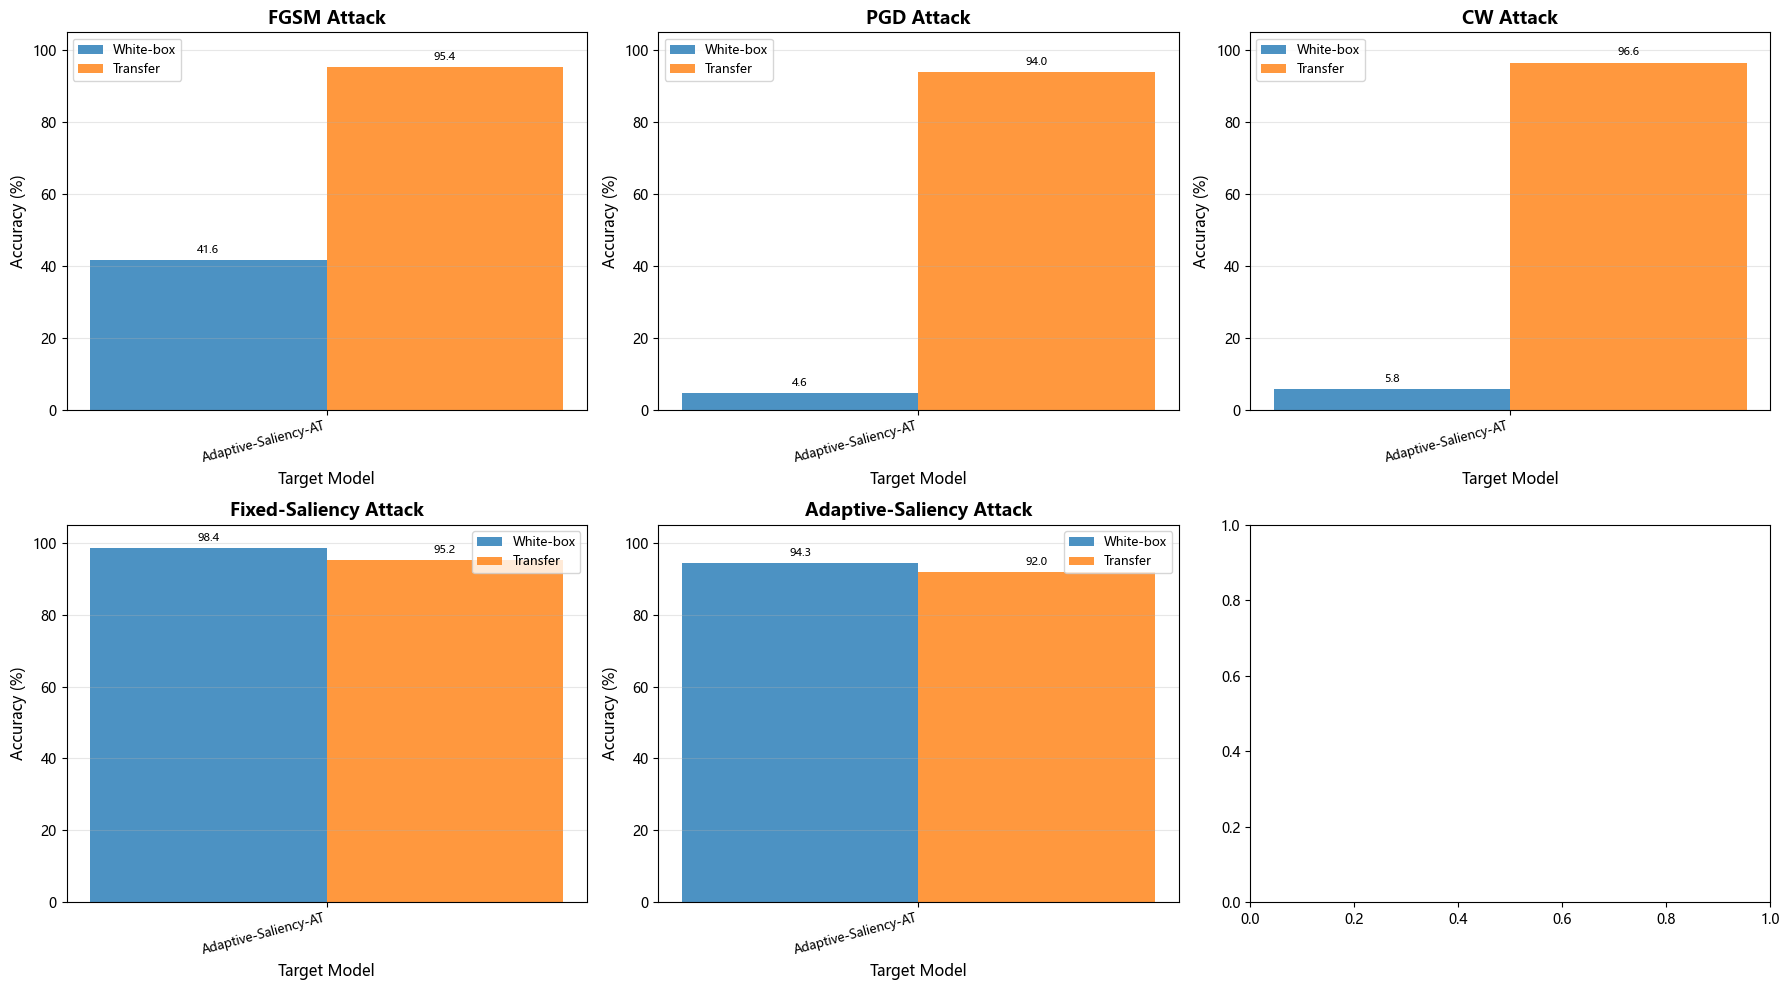

[SAVED] 对比图: ./results_figures/whitebox_vs_transfer_comparison.png

白盒攻击测试 + 迁移攻击对比 完成！


In [1]:
# ========== 白盒攻击测试 + 迁移攻击对比 ==========
"""
白盒攻击测试：使用 AdaptiveSaliencyOcclusionAttack 等攻击直接攻击目标模型
并与迁移攻击结果汇总对比
"""

import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from occlusion_attack import SaliencyOcclusionAttack, AdaptiveSaliencyOcclusionAttack
from pgd import LinfPGD
from loss import CWLoss
from models import LeNet5
from utils import load_mnist_test
import test
test_fn = test.test

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False

print(f'Device: {device}')

# ========== 1. 加载所有模型 ==========
def load_model(ckpt_path, model_name='Model'):
    """加载模型"""
    if not os.path.exists(ckpt_path):
        print(f'[WARN] 模型不存在: {ckpt_path}')
        return None
    net = LeNet5().to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    net.load_state_dict(state['net'])
    net.eval()
    print(f'[OK] 加载 {model_name}')
    return net

print('\n' + '='*60)
print('加载所有模型')
print('='*60)

# 标准模型（用于迁移攻击生成对抗样本）
std_lenet = load_model('./save_model/50epoch/mnist_lenet5.pth', 'Standard (替代模型)')

# 各AT模型（白盒攻击目标 + 迁移攻击目标）
target_models = {
    'Standard': std_lenet,
    'PGD-AT': load_model('./save_model/50epoch/mnist_lenet5_PGD_0.1_5_AT.pth', 'PGD-AT'),
    'FGSM-AT': load_model('./save_model/50epoch/mnist_lenet5_FGSM_AT.pth', 'FGSM-AT'),

    'Adaptive-Saliency-AT': load_model('./save_model/50epoch/mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_3.pth', 'Adaptive-Saliency-AT'),
}

# 过滤未加载成功的模型
target_models = {k: v for k, v in target_models.items() if v is not None}

if not target_models:
    print('[ERROR] 没有成功加载任何模型！')
    raise RuntimeError('模型加载失败')

print(f'\n成功加载 {len(target_models)} 个模型: {list(target_models.keys())}')

# 加载测试数据
print('\n加载测试数据...')
imgs, lbls = load_mnist_test()
print(f'测试集大小: {len(imgs)}')

# ========== 2. 定义攻击参数 ==========
print('\n' + '='*60)
print('攻击参数配置')
print('='*60)

# 通用参数
EPS = 0.1
N_attack = 5      # Adaptive遮蔽数量
R_attack = 3      # Adaptive遮蔽半径
top_k = 9         # Fixed遮蔽top_k
kernel_size = 3   # Fixed遮蔽kernel_size
occlu_color = 0.0 # 遮蔽颜色（黑色）

print(f'PGD/FGSM epsilon: {EPS}')
print(f'Adaptive-Saliency: N={N_attack}, R={R_attack}')
print(f'Fixed-Saliency: top_k={top_k}, kernel_size={kernel_size}')

# ========== 3. 白盒攻击测试 ==========
def run_whitebox_tests(model, model_name):
    """对白盒模型进行攻击测试"""
    print(f'\n>>> 白盒攻击测试: {model_name}')
    results = {'model': model_name, 'attack_type': 'White-box'}

    # Clean
    clean_acc, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')
    results['Clean'] = clean_acc
    print(f'    Clean:              {clean_acc:6.2f}%')

    # FGSM
    fgsm = LinfPGD(net=model, eps=EPS, step=1, step_size=EPS, random_start=False)
    fgsm_acc, _ = test_fn(nn.Sequential(fgsm, model), imgs, lbls, bs=250, mode='attack')
    results['FGSM'] = fgsm_acc
    print(f'    FGSM:               {fgsm_acc:6.2f}%')

    # PGD
    pgd = LinfPGD(net=model, eps=EPS, step=20, step_size=0.025, random_start=True)
    pgd_acc, _ = test_fn(nn.Sequential(pgd, model), imgs, lbls, bs=250, mode='attack')
    results['PGD'] = pgd_acc
    print(f'    PGD:                {pgd_acc:6.2f}%')

    # CW
    cw = LinfPGD(net=model, eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
    cw_acc, _ = test_fn(nn.Sequential(cw, model), imgs, lbls, bs=250, mode='attack')
    results['CW'] = cw_acc
    print(f'    CW:                 {cw_acc:6.2f}%')

    # Fixed-Saliency
    fixed = SaliencyOcclusionAttack(model, top_k=top_k, kernel_size=kernel_size, occlu_color=occlu_color)
    fixed_acc, _ = test_fn(nn.Sequential(fixed, model), imgs, lbls, bs=250, mode='attack')
    results['Fixed-Saliency'] = fixed_acc
    print(f'    Fixed-Saliency:     {fixed_acc:6.2f}%')

    # Adaptive-Saliency (重点)
    adaptive = AdaptiveSaliencyOcclusionAttack(model, N=N_attack, R=R_attack, c=occlu_color)
    adaptive_acc, _ = test_fn(nn.Sequential(adaptive, model), imgs, lbls, bs=250, mode='attack')
    results['Adaptive-Saliency'] = adaptive_acc
    print(f'    Adaptive-Saliency:  {adaptive_acc:6.2f}%')

    return results


print('\n' + '='*60)
print('白盒攻击测试')
print('='*60)

whitebox_results = []
for name, model in target_models.items():
    result = run_whitebox_tests(model, name)
    whitebox_results.append(result)

# ========== 4. 迁移攻击测试 ==========
def run_transfer_tests(target_model, target_name, substitute_model):
    """使用替代模型生成对抗样本，测试目标模型"""
    print(f'\n>>> 迁移攻击测试: {target_name} (使用 {substitute_model[0]} 生成)')
    results = {'model': target_name, 'attack_type': f'Transfer ({substitute_model[0]})'}

    # Clean
    clean_acc, _ = test_fn(target_model, imgs, lbls, bs=250, mode='clean')
    results['Clean'] = clean_acc
    print(f'    Clean:              {clean_acc:6.2f}%')

    # FGSM
    fgsm = LinfPGD(net=substitute_model[1], eps=EPS, step=1, step_size=EPS, random_start=False)
    fgsm_acc, _ = test_fn(nn.Sequential(fgsm, target_model), imgs, lbls, bs=250, mode='attack')
    results['FGSM'] = fgsm_acc
    print(f'    FGSM:               {fgsm_acc:6.2f}%')

    # PGD
    pgd = LinfPGD(net=substitute_model[1], eps=EPS, step=20, step_size=0.025, random_start=True)
    pgd_acc, _ = test_fn(nn.Sequential(pgd, target_model), imgs, lbls, bs=250, mode='attack')
    results['PGD'] = pgd_acc
    print(f'    PGD:                {pgd_acc:6.2f}%')

    # CW
    cw = LinfPGD(net=substitute_model[1], eps=EPS, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
    cw_acc, _ = test_fn(nn.Sequential(cw, target_model), imgs, lbls, bs=250, mode='attack')
    results['CW'] = cw_acc
    print(f'    CW:                 {cw_acc:6.2f}%')

    # Fixed-Saliency
    fixed = SaliencyOcclusionAttack(substitute_model[1], top_k=top_k, kernel_size=kernel_size, occlu_color=occlu_color)
    fixed_acc, _ = test_fn(nn.Sequential(fixed, target_model), imgs, lbls, bs=250, mode='attack')
    results['Fixed-Saliency'] = fixed_acc
    print(f'    Fixed-Saliency:     {fixed_acc:6.2f}%')

    # Adaptive-Saliency
    adaptive = AdaptiveSaliencyOcclusionAttack(substitute_model[1], N=N_attack, R=R_attack, c=occlu_color)
    adaptive_acc, _ = test_fn(nn.Sequential(adaptive, target_model), imgs, lbls, bs=250, mode='attack')
    results['Adaptive-Saliency'] = adaptive_acc
    print(f'    Adaptive-Saliency:  {adaptive_acc:6.2f}%')

    return results


print('\n' + '='*60)
print('迁移攻击测试')
print('='*60)

transfer_results = []
if 'Standard' in target_models and std_lenet is not None:
    substitute = ('Standard', std_lenet)
    for name, model in target_models.items():
        if name != 'Standard':  # 不对标准模型做迁移攻击
            result = run_transfer_tests(model, name, substitute)
            transfer_results.append(result)

# ========== 5. 汇总对比表格 ==========
print('\n' + '='*80)
print('白盒攻击 vs 迁移攻击 汇总对比')
print('='*80)

# 合并所有结果
all_results = whitebox_results + transfer_results

# 创建DataFrame
df_all = pd.DataFrame(all_results)

# 按模型分组显示
for model_name in target_models.keys():
    print(f'\n>>> {model_name}')
    model_data = df_all[df_all['model'] == model_name]
    print(model_data.to_string(index=False))

print('\n' + '='*80)

# 保存完整表格
os.makedirs('./results_figures', exist_ok=True)
csv_path = './results_figures/whitebox_vs_transfer_attack_comparison.csv'
df_all.to_csv(csv_path, index=False)
print(f'[SAVED] 完整对比表格: {csv_path}')

# ========== 6. 可视化对比 ==========
print('\n=== 白盒 vs 迁移攻击 可视化对比 ===')

# 选择对比的模型（排除Standard，因为没有迁移攻击）
compare_models = [m for m in target_models.keys() if m != 'Standard']

if len(compare_models) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    attack_types = ['FGSM', 'PGD', 'CW', 'Fixed-Saliency', 'Adaptive-Saliency']

    for idx, attack in enumerate(attack_types):
        ax = axes[idx // 3, idx % 3]

        x = np.arange(len(compare_models))
        width = 0.35

        whitebox_vals = []
        transfer_vals = []

        for model in compare_models:
            wb_val = df_all[(df_all['model'] == model) & (df_all['attack_type'] == 'White-box')][attack].values
            tr_val = df_all[(df_all['model'] == model) & (df_all['attack_type'].str.startswith('Transfer'))][attack].values

            whitebox_vals.append(wb_val[0] if len(wb_val) > 0 else 0)
            transfer_vals.append(tr_val[0] if len(tr_val) > 0 else 0)

        ax.bar(x - width/2, whitebox_vals, width, label='White-box', color='#1f77b4', alpha=0.8)
        ax.bar(x + width/2, transfer_vals, width, label='Transfer', color='#ff7f0e', alpha=0.8)

        ax.set_xlabel('Target Model', fontsize=11)
        ax.set_ylabel('Accuracy (%)', fontsize=11)
        ax.set_title(f'{attack} Attack', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(compare_models, rotation=15, ha='right', fontsize=9)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0, 105)

        # 添加数值标签
        for i, (wb, tr) in enumerate(zip(whitebox_vals, transfer_vals)):
            ax.text(i - width/2, wb + 2, f'{wb:.1f}', ha='center', fontsize=8)
            ax.text(i + width/2, tr + 2, f'{tr:.1f}', ha='center', fontsize=8)

    plt.tight_layout()
    save_path = './results_figures/whitebox_vs_transfer_comparison.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[SAVED] 对比图: {save_path}')

print('\n' + '='*60)
print('白盒攻击测试 + 迁移攻击对比 完成！')
print('='*60)


In [1]:
# ========== 读取并显示白盒/迁移攻击对比表格 ==========
"""
读取 whitebox_vs_transfer_attack_comparison.csv 并显示为格式化表格
"""

import pandas as pd
import os

# 读取CSV
csv_path = './results_figures/whitebox_vs_transfer_attack_comparison.csv'

if not os.path.exists(csv_path):
    print(f'[ERROR] CSV文件不存在: {csv_path}')
    print('请先运行白盒攻击+迁移攻击测试cell生成数据')
else:
    # 读取数据
    df = pd.read_csv(csv_path)

    # 设置显示选项
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.float_format', '{:.2f}'.format)

    print('=' * 100)
    print('白盒攻击 vs 迁移攻击 对比结果')
    print('=' * 100)
    print()

    # 显示完整表格
    print(df.to_string(index=False))

    print()
    print('=' * 100)
    print(f'数据行数: {len(df)} | 模型数: {df["model"].nunique()} | 攻击类型数: {df["attack_type"].nunique()}')
    print('=' * 100)


白盒攻击 vs 迁移攻击 对比结果

               model         attack_type  Clean  FGSM   PGD    CW  Fixed-Saliency  Adaptive-Saliency
            Standard           White-box  99.00 79.46 33.65 33.45           71.19              34.33
Adaptive-Saliency-AT           White-box  98.73 41.56  4.63  5.76           98.43              94.30
Adaptive-Saliency-AT Transfer (Standard)  98.73 95.38 93.98 96.57           95.15              91.96

数据行数: 3 | 模型数: 2 | 攻击类型数: 2


d:\anaconda3\envs\adv-attack\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda

=== 加载 Adaptive-Saliency-AT(N=5,R=3) 模型 ===
[OK] 模型已加载: ./save_model/50epoch/mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_3.pth

=== 加载测试数据 ===
测试集大小: 10000

=== 开始评测 ===
------------------------------------------------------------
测试干净样本...
Clean Accuracy: 98.73%

测试 Adaptive-Saliency 攻击 (N变化, R=3)...
  N= 3, R=3:  95.97%
  N= 5, R=3:  94.30%
  N= 7, R=3:  92.44%
  N=10, R=3:  88.74%

测试 Adaptive-Saliency 攻击 (R变化, N=5)...
  N=5, R=2:  96.41%
  N=5, R=3:  94.30%
  N=5, R=4:  88.11%

测试 Fixed-Saliency 攻击 (top_k变化)...
  top_k= 3:  98.62%
  top_k= 5:  98.61%
  top_k= 7:  98.49%
  top_k= 9:  98.43%
  top_k=12:  98.31%
  top_k=15:  98.20%

测试 Adaptive-Saliency 攻击 (不同颜色, N=5, R=3)...
  颜色=黑色:  94.30%
  颜色=灰色:  45.60%
  颜色=白色:  14.18%

评测完成，开始绘制可视化图表...


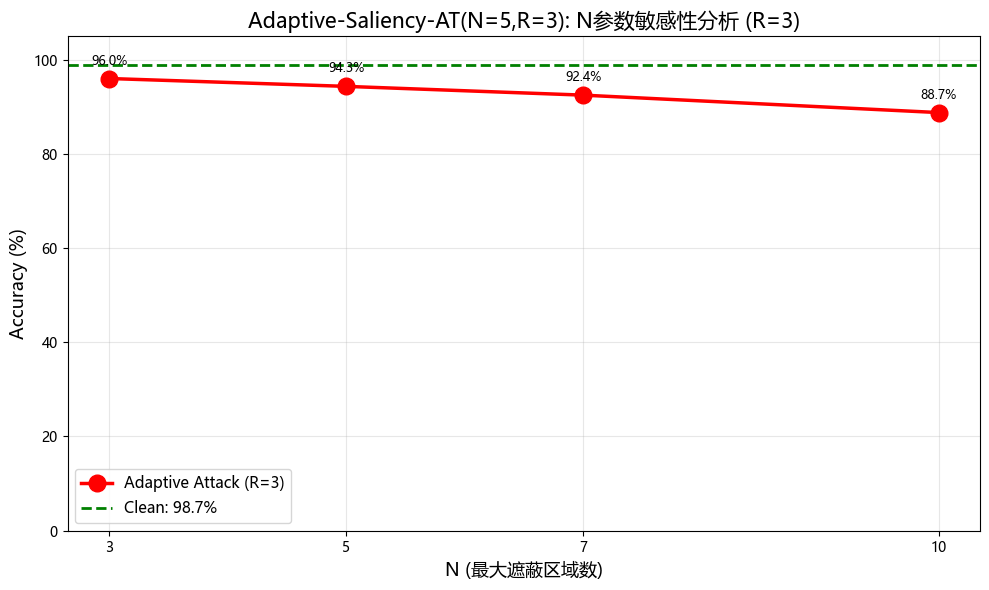

[SAVED] ./results_figures/eval_adaptive_n_param_N5R3.png


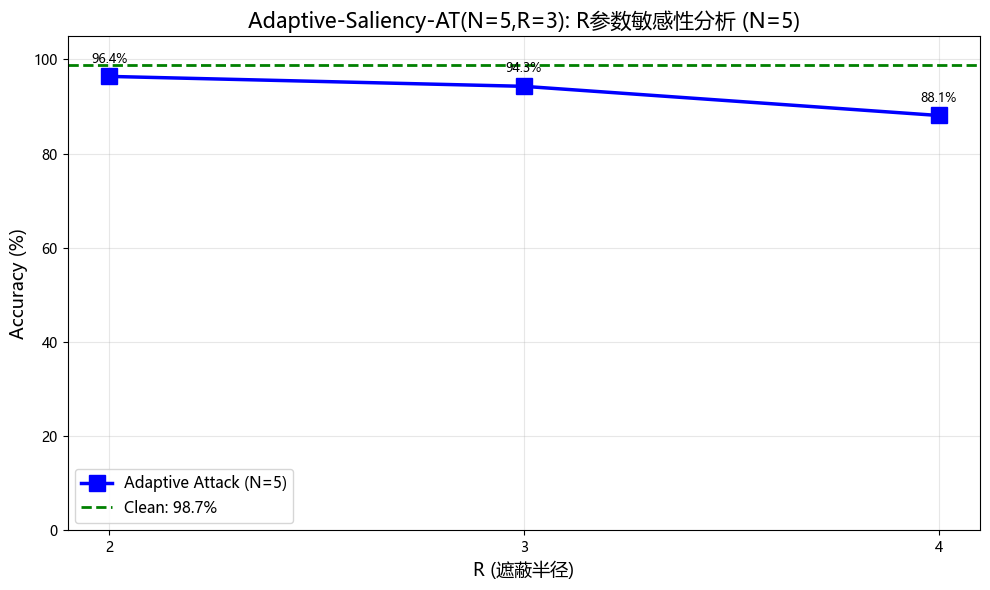

[SAVED] ./results_figures/eval_adaptive_r_param_N5R3.png


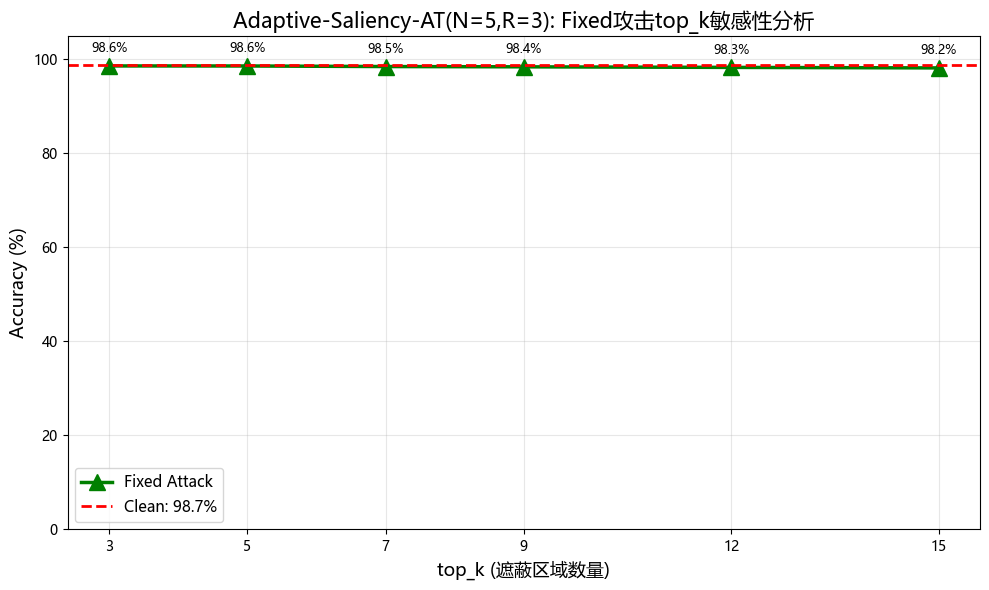

[SAVED] ./results_figures/eval_fixed_topk_param_N5R3.png


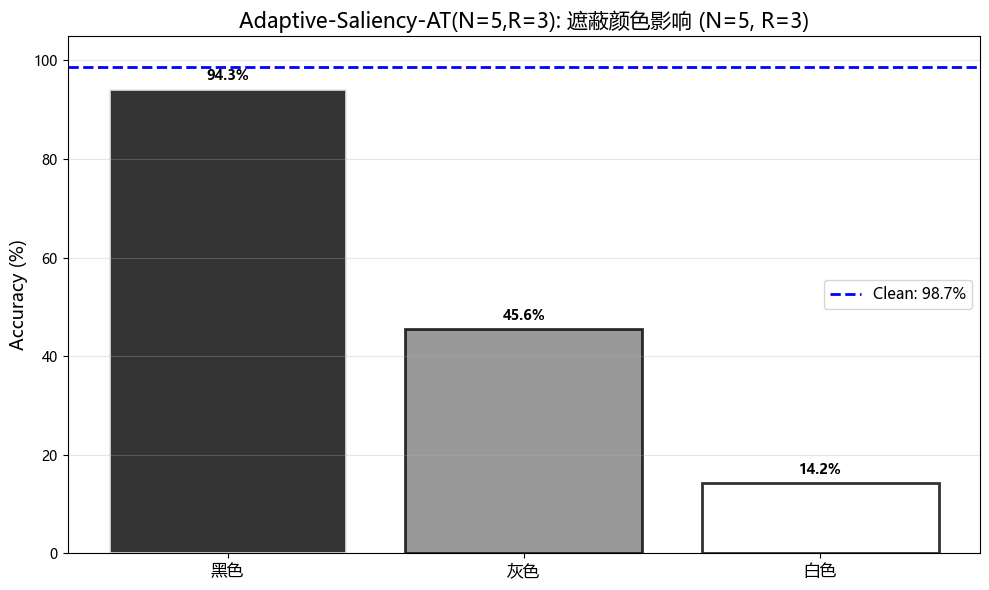

[SAVED] ./results_figures/eval_color_param_N5R3.png


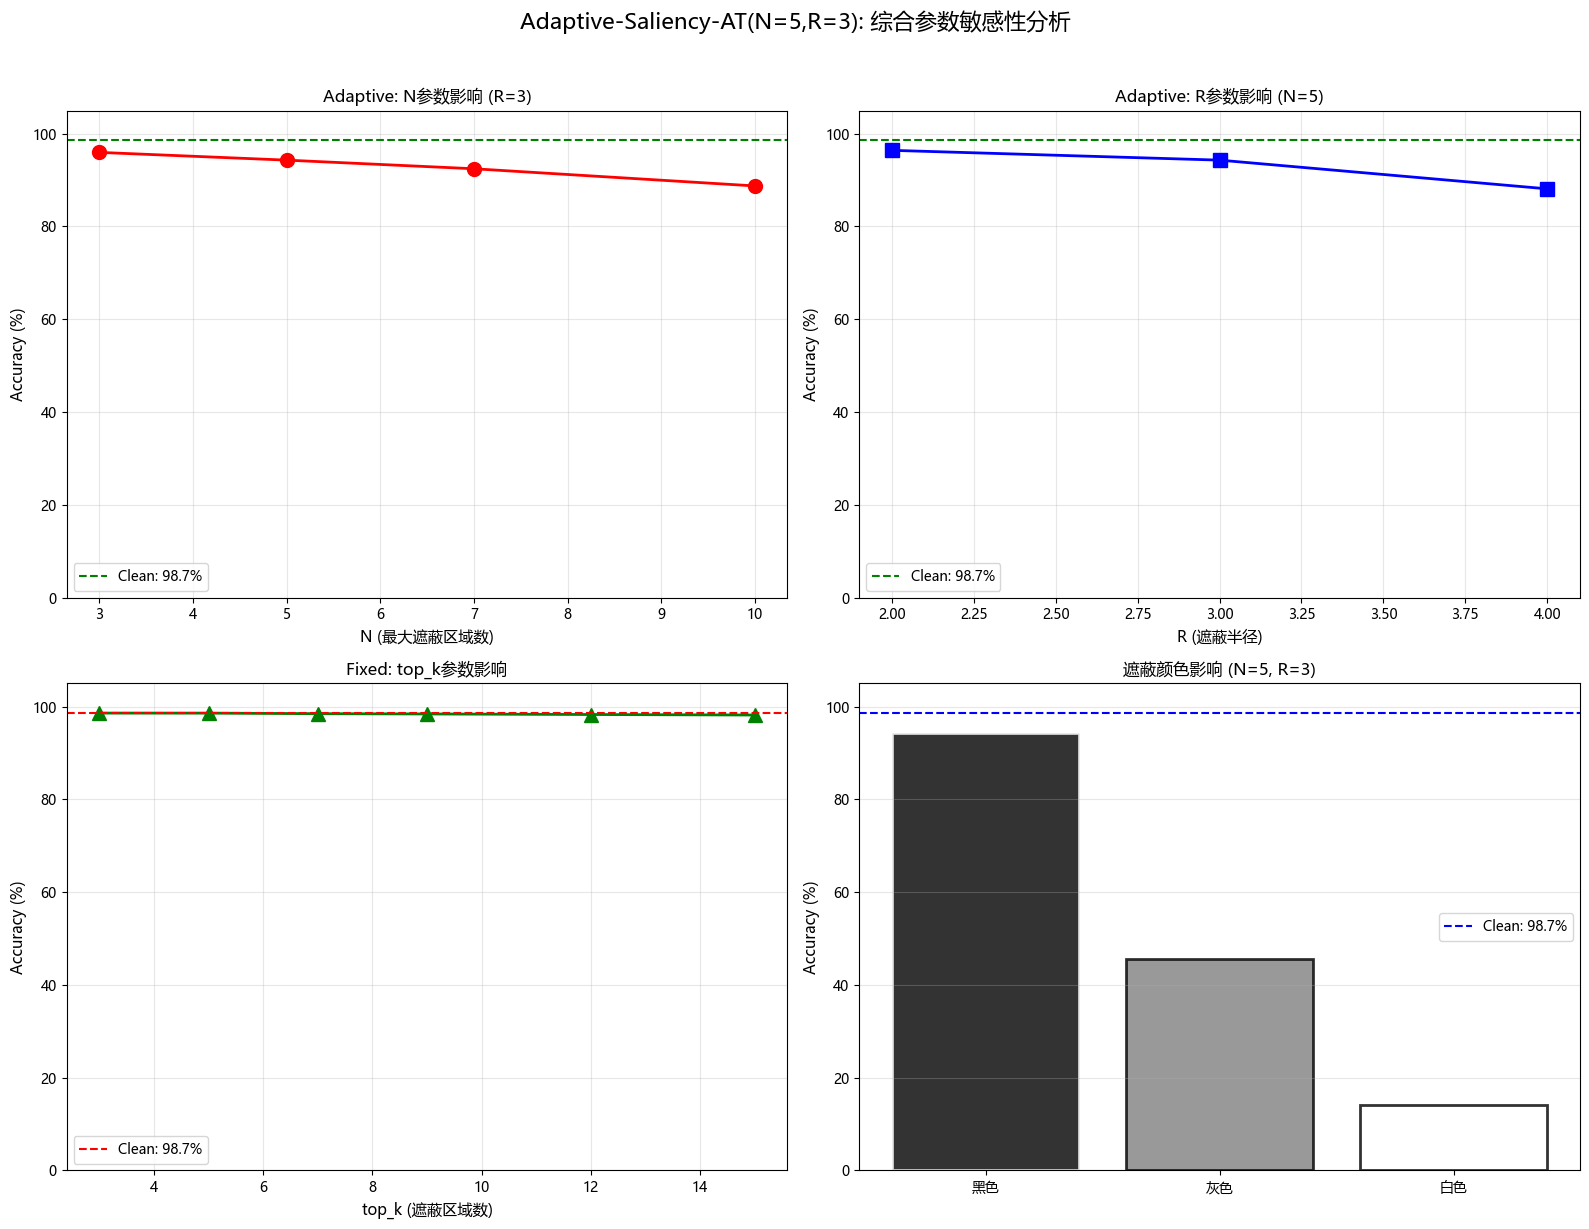

[SAVED] ./results_figures/eval_comprehensive_analysis_N5R3.png

评测可视化完成！
生成图表:
  1. eval_adaptive_n_param_N5R3.png - N参数敏感性
  2. eval_adaptive_r_param_N5R3.png - R参数敏感性
  3. eval_fixed_topk_param_N5R3.png - Fixed top_k敏感性
  4. eval_color_param_N5R3.png - 遮蔽颜色影响
  5. eval_comprehensive_analysis_N5R3.png - 综合分析


In [2]:
# ========== Adaptive-Saliency-AT(N=5,R=3) 模型评测与可视化 ==========
"""
对 save_model\50epoch\mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_3.pth 进行完整评测
内核重启后可直接运行
"""

import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import os

from occlusion_attack import SaliencyOcclusionAttack, AdaptiveSaliencyOcclusionAttack
from models import LeNet5
from utils import load_mnist_test
import test
test_fn = test.test

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False

print(f'Device: {device}')

# ========== 1. 加载模型 ==========
print('\n=== 加载 Adaptive-Saliency-AT(N=5,R=3) 模型 ===')
model_path = './save_model/50epoch/mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_3.pth'

cnn = LeNet5().to(device)
state = torch.load(model_path, map_location=device, weights_only=False)
cnn.load_state_dict(state['net'])
cnn.eval()
print(f'[OK] 模型已加载: {model_path}')

# ========== 2. 加载测试数据 ==========
print('\n=== 加载测试数据 ===')
imgs, lbls = load_mnist_test()
print(f'测试集大小: {len(imgs)}')

# 确保结果目录存在
os.makedirs('./results_figures', exist_ok=True)

# ========== 3. 执行评测 ==========
print('\n=== 开始评测 ===')
print('-' * 60)

# 干净样本准确率
print('测试干净样本...')
clean_acc, _ = test_fn(cnn, imgs, lbls, bs=250, mode='clean')
print(f'Clean Accuracy: {clean_acc:.2f}%')

# ---------- 3.1 Adaptive攻击 - 不同N参数（固定R=3）----------
print('\n测试 Adaptive-Saliency 攻击 (N变化, R=3)...')
N_values = [3, 5, 7, 10]
R_fixed = 3
adaptive_n_results = []
for N in N_values:
    attack = AdaptiveSaliencyOcclusionAttack(cnn, N=N, R=R_fixed, c=0.0)
    acc, _ = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    adaptive_n_results.append({'N': N, 'R': R_fixed, 'accuracy': acc})
    print(f'  N={N:2d}, R={R_fixed}: {acc:6.2f}%')

# ---------- 3.2 Adaptive攻击 - 不同R参数（固定N=5）----------
print('\n测试 Adaptive-Saliency 攻击 (R变化, N=5)...')
N_fixed = 5
R_values = [2, 3, 4]
adaptive_r_results = []
for R in R_values:
    attack = AdaptiveSaliencyOcclusionAttack(cnn, N=N_fixed, R=R, c=0.0)
    acc, _ = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    adaptive_r_results.append({'N': N_fixed, 'R': R, 'accuracy': acc})
    print(f'  N={N_fixed}, R={R}: {acc:6.2f}%')

# ---------- 3.3 Fixed攻击 - 不同top_k参数 ----------
print('\n测试 Fixed-Saliency 攻击 (top_k变化)...')
top_k_values = [3, 5, 7, 9, 12, 15]
fixed_results = []
for top_k in top_k_values:
    attack = SaliencyOcclusionAttack(cnn, top_k=top_k, kernel_size=3, occlu_color=0.0)
    acc, _ = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    fixed_results.append({'top_k': top_k, 'accuracy': acc})
    print(f'  top_k={top_k:2d}: {acc:6.2f}%')

# ---------- 3.4 不同遮蔽颜色（Adaptive, N=5, R=3）----------
print('\n测试 Adaptive-Saliency 攻击 (不同颜色, N=5, R=3)...')
colors = [0.0, 0.5, 1.0]
color_names = ['黑色', '灰色', '白色']
color_eval_results = []
for c, name in zip(colors, color_names):
    attack = AdaptiveSaliencyOcclusionAttack(cnn, N=5, R=3, c=c)
    acc, _ = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    color_eval_results.append({'param': f'color={name}', 'accuracy': acc})
    print(f'  颜色={name}: {acc:6.2f}%')

print('\n' + '=' * 60)
print('评测完成，开始绘制可视化图表...')
print('=' * 60)

# ========== 4. 绘制可视化图表 ==========

# 准备数据
n_results_sorted = sorted(adaptive_n_results, key=lambda x: x['N'])
r_results_sorted = sorted(adaptive_r_results, key=lambda x: x['R'])
fixed_results_sorted = sorted(fixed_results, key=lambda x: x['top_k'])

# ---------- 图1: Adaptive攻击 - N参数影响 ----------
fig1, ax1 = plt.subplots(figsize=(10, 6))

N_vals = [r['N'] for r in n_results_sorted]
acc_vals_n = [r['accuracy'] for r in n_results_sorted]

ax1.plot(N_vals, acc_vals_n, 'ro-', markersize=12, linewidth=2.5, label='Adaptive Attack (R=3)')
ax1.axhline(y=clean_acc, color='g', linestyle='--', linewidth=2, label=f'Clean: {clean_acc:.1f}%')
ax1.set_xlabel('N (最大遮蔽区域数)', fontsize=13)
ax1.set_ylabel('Accuracy (%)', fontsize=13)
ax1.set_title('Adaptive-Saliency-AT(N=5,R=3): N参数敏感性分析 (R=3)', fontsize=15)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 105)
ax1.set_xticks(N_vals)

for x, y in zip(N_vals, acc_vals_n):
    ax1.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
save_path1 = './results_figures/eval_adaptive_n_param_N5R3.png'
plt.savefig(save_path1, dpi=150, bbox_inches='tight')
plt.show()
print(f'[SAVED] {save_path1}')

# 保存CSV
df_n = pd.DataFrame([{'N': r['N'], 'R': 3, 'Accuracy': r['accuracy']} for r in n_results_sorted])
df_n.to_csv('./results_figures/eval_adaptive_n_param_N5R3.csv', index=False)

# ---------- 图2: Adaptive攻击 - R参数影响 ----------
fig2, ax2 = plt.subplots(figsize=(10, 6))

R_vals = [r['R'] for r in r_results_sorted]
acc_vals_r = [r['accuracy'] for r in r_results_sorted]

ax2.plot(R_vals, acc_vals_r, 'bs-', markersize=12, linewidth=2.5, label='Adaptive Attack (N=5)')
ax2.axhline(y=clean_acc, color='g', linestyle='--', linewidth=2, label=f'Clean: {clean_acc:.1f}%')
ax2.set_xlabel('R (遮蔽半径)', fontsize=13)
ax2.set_ylabel('Accuracy (%)', fontsize=13)
ax2.set_title('Adaptive-Saliency-AT(N=5,R=3): R参数敏感性分析 (N=5)', fontsize=15)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)
ax2.set_xticks(R_vals)

for x, y in zip(R_vals, acc_vals_r):
    ax2.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
save_path2 = './results_figures/eval_adaptive_r_param_N5R3.png'
plt.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'[SAVED] {save_path2}')

# 保存CSV
df_r = pd.DataFrame([{'N': 5, 'R': r['R'], 'Accuracy': r['accuracy']} for r in r_results_sorted])
df_r.to_csv('./results_figures/eval_adaptive_r_param_N5R3.csv', index=False)

# ---------- 图3: Fixed攻击 - top_k影响 ----------
fig3, ax3 = plt.subplots(figsize=(10, 6))

top_k_vals = [r['top_k'] for r in fixed_results_sorted]
acc_vals_fixed = [r['accuracy'] for r in fixed_results_sorted]

ax3.plot(top_k_vals, acc_vals_fixed, 'g^-', markersize=12, linewidth=2.5, label='Fixed Attack')
ax3.axhline(y=clean_acc, color='r', linestyle='--', linewidth=2, label=f'Clean: {clean_acc:.1f}%')
ax3.set_xlabel('top_k (遮蔽区域数量)', fontsize=13)
ax3.set_ylabel('Accuracy (%)', fontsize=13)
ax3.set_title('Adaptive-Saliency-AT(N=5,R=3): Fixed攻击top_k敏感性分析', fontsize=15)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 105)
ax3.set_xticks(top_k_vals)

for x, y in zip(top_k_vals, acc_vals_fixed):
    ax3.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
save_path3 = './results_figures/eval_fixed_topk_param_N5R3.png'
plt.savefig(save_path3, dpi=150, bbox_inches='tight')
plt.show()
print(f'[SAVED] {save_path3}')

# 保存CSV
df_fixed = pd.DataFrame([{'top_k': r['top_k'], 'Accuracy': r['accuracy']} for r in fixed_results_sorted])
df_fixed.to_csv('./results_figures/eval_fixed_topk_param_N5R3.csv', index=False)

# ---------- 图4: 遮蔽颜色影响 ----------
fig4, ax4 = plt.subplots(figsize=(10, 6))

color_labels = [r['param'].replace('color=', '') for r in color_eval_results]
color_accs = [r['accuracy'] for r in color_eval_results]
bar_colors = ['black', 'gray', 'white']
edge_colors = ['white', 'black', 'black']

bars = ax4.bar(range(len(color_labels)), color_accs,
               color=bar_colors, edgecolor=edge_colors, linewidth=2, alpha=0.8)
ax4.set_xticks(range(len(color_labels)))
ax4.set_xticklabels(color_labels, fontsize=12)
ax4.set_ylabel('Accuracy (%)', fontsize=13)
ax4.set_title('Adaptive-Saliency-AT(N=5,R=3): 遮蔽颜色影响 (N=5, R=3)', fontsize=15)
ax4.axhline(y=clean_acc, color='blue', linestyle='--', linewidth=2, label=f'Clean: {clean_acc:.1f}%')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(0, 105)

for bar, val in zip(bars, color_accs):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
save_path4 = './results_figures/eval_color_param_N5R3.png'
plt.savefig(save_path4, dpi=150, bbox_inches='tight')
plt.show()
print(f'[SAVED] {save_path4}')

# 保存CSV
df_color = pd.DataFrame([{'Color': r['param'].replace('color=', ''), 'Accuracy': r['accuracy']} for r in color_eval_results])
df_color.to_csv('./results_figures/eval_color_param_N5R3.csv', index=False)

# ---------- 图5: 综合对比（2x2子图） ----------
fig5, axes = plt.subplots(2, 2, figsize=(16, 12))

# (0,0) N参数
axes[0,0].plot(N_vals, acc_vals_n, 'ro-', markersize=10, linewidth=2)
axes[0,0].axhline(y=clean_acc, color='g', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[0,0].set_xlabel('N (最大遮蔽区域数)', fontsize=11)
axes[0,0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0,0].set_title('Adaptive: N参数影响 (R=3)', fontsize=12)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_ylim(0, 105)

# (0,1) R参数
axes[0,1].plot(R_vals, acc_vals_r, 'bs-', markersize=10, linewidth=2)
axes[0,1].axhline(y=clean_acc, color='g', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[0,1].set_xlabel('R (遮蔽半径)', fontsize=11)
axes[0,1].set_ylabel('Accuracy (%)', fontsize=11)
axes[0,1].set_title('Adaptive: R参数影响 (N=5)', fontsize=12)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_ylim(0, 105)

# (1,0) Fixed top_k
axes[1,0].plot(top_k_vals, acc_vals_fixed, 'g^-', markersize=10, linewidth=2)
axes[1,0].axhline(y=clean_acc, color='r', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[1,0].set_xlabel('top_k (遮蔽区域数)', fontsize=11)
axes[1,0].set_ylabel('Accuracy (%)', fontsize=11)
axes[1,0].set_title('Fixed: top_k参数影响', fontsize=12)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_ylim(0, 105)

# (1,1) 颜色影响
bar_colors_plot = ['black', 'gray', 'white']
axes[1,1].bar(range(len(color_labels)), color_accs, color=bar_colors_plot,
              edgecolor=['white', 'black', 'black'], linewidth=2, alpha=0.8)
axes[1,1].set_xticks(range(len(color_labels)))
axes[1,1].set_xticklabels(color_labels)
axes[1,1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1,1].set_title('遮蔽颜色影响 (N=5, R=3)', fontsize=12)
axes[1,1].axhline(y=clean_acc, color='blue', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, axis='y')
axes[1,1].set_ylim(0, 105)

plt.suptitle('Adaptive-Saliency-AT(N=5,R=3): 综合参数敏感性分析', fontsize=16, y=1.02)
plt.tight_layout()
save_path5 = './results_figures/eval_comprehensive_analysis_N5R3.png'
plt.savefig(save_path5, dpi=150, bbox_inches='tight')
plt.show()
print(f'[SAVED] {save_path5}')

print('\n' + '=' * 60)
print('评测可视化完成！')
print('=' * 60)
print('生成图表:')
print('  1. eval_adaptive_n_param_N5R3.png - N参数敏感性')
print('  2. eval_adaptive_r_param_N5R3.png - R参数敏感性')
print('  3. eval_fixed_topk_param_N5R3.png - Fixed top_k敏感性')
print('  4. eval_color_param_N5R3.png - 遮蔽颜色影响')
print('  5. eval_comprehensive_analysis_N5R3.png - 综合分析')
print('=' * 60)


In [ ]:
# ========== AdaptiveSaliencyPgdMixedAT 迁移攻击测试 ==========
"""
对 mnist_lenet5_AdaptiveSaliencyPgdMixedAT_0.5_5_3.pth 进行迁移攻击测试
使用 Standard 模型生成对抗样本，测试 Mixed-AT 模型鲁棒性
"""

import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1.代码')

import torch
import torch.nn as nn
import pandas as pd
import os

from occlusion_attack import SaliencyOcclusionAttack, AdaptiveSaliencyOcclusionAttack
from pgd import LinfPGD
from loss import CWLoss
from models import LeNet5
from utils import load_mnist_test
import test
test_fn = test.test

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {device}')

# 加载替代模型（Standard）
print('=== 加载替代模型（Standard）===')
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', map_location=device, weights_only=False)
std_lenet = LeNet5().to(device)
std_lenet.load_state_dict(std_state['net'])
std_lenet.eval()
print('[OK] Standard 模型已加载')

# 加载目标模型（Mixed-AT）
print('=== 加载目标模型（AdaptiveSaliencyPgdMixedAT）===')
cnn_mix = LeNet5().to(device)
state = torch.load('./save_model/50epoch/mnist_lenet5_AdaptiveSaliencyPgdMixedAT_0.5_5_3.pth', map_location=device, weights_only=False)
cnn_mix.load_state_dict(state['net'])
cnn_mix.eval()
print('[OK] Mixed-AT 模型已加载')

# 加载测试数据
print('=== 加载测试数据 ===')
imgs, lbls = load_mnist_test()
print(f'测试集大小: {len(imgs)}')

# 攻击参数
N_attack = 5
R_attack = 3
top_k = 9
kernel_size = 3
occlu_color = 0.0
eps = 0.1

print('=== 迁移攻击测试 ===')
print('使用 Standard 模型生成对抗样本，测试 Mixed-AT 模型')
print('-' * 60)

results = {'model': 'Mixed-AT', 'attack_type': 'Transfer (Standard)'}

# Clean
clean_acc, _ = test_fn(cnn_mix, imgs, lbls, bs=250, mode='clean')
results['Clean'] = clean_acc
print(f'Clean:              {clean_acc:6.2f}%')

# FGSM
fgsm = LinfPGD(net=std_lenet, eps=eps, step=1, step_size=eps, random_start=False)
fgsm_acc, _ = test_fn(nn.Sequential(fgsm, cnn_mix), imgs, lbls, bs=250, mode='attack')
results['FGSM'] = fgsm_acc
print(f'FGSM:               {fgsm_acc:6.2f}%')

# PGD
pgd = LinfPGD(net=std_lenet, eps=eps, step=20, step_size=0.025, random_start=True)
pgd_acc, _ = test_fn(nn.Sequential(pgd, cnn_mix), imgs, lbls, bs=250, mode='attack')
results['PGD'] = pgd_acc
print(f'PGD:                {pgd_acc:6.2f}%')

# CW
cw = LinfPGD(net=std_lenet, eps=eps, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
cw_acc, _ = test_fn(nn.Sequential(cw, cnn_mix), imgs, lbls, bs=250, mode='attack')
results['CW'] = cw_acc
print(f'CW:                 {cw_acc:6.2f}%')

# Fixed-Saliency
fixed = SaliencyOcclusionAttack(std_lenet, top_k=top_k, kernel_size=kernel_size, occlu_color=occlu_color)
fixed_acc, _ = test_fn(nn.Sequential(fixed, cnn_mix), imgs, lbls, bs=250, mode='attack')
results['Fixed-Saliency'] = fixed_acc
print(f'Fixed-Saliency:     {fixed_acc:6.2f}%')

# Adaptive-Saliency
adaptive = AdaptiveSaliencyOcclusionAttack(std_lenet, N=N_attack, R=R_attack, c=occlu_color)
adaptive_acc, _ = test_fn(nn.Sequential(adaptive, cnn_mix), imgs, lbls, bs=250, mode='attack')
results['Adaptive-Saliency'] = adaptive_acc
print(f'Adaptive-Saliency:  {adaptive_acc:6.2f}%')

# 显示表格
print('' + '=' * 100)
print('AdaptiveSaliencyPgdMixedAT 迁移攻击结果')
print('=' * 100)
df = pd.DataFrame([results])
print(df.to_string(index=False))
print('=' * 100)

# 保存CSV
os.makedirs('./results_figures', exist_ok=True)
csv_path = './results_figures/transfer_attack_mixed_at_0.5_5_3.csv'
df.to_csv(csv_path, index=False)
print(f'[SAVED] 结果已保存: {csv_path}')


Device: cuda
=== 加载替代模型（Standard）===
[OK] Standard 模型已加载
=== 加载目标模型（AdaptiveSaliencyPgdMixedAT）===
[OK] Mixed-AT 模型已加载
=== 加载测试数据 ===
测试集大小: 10000
=== 迁移攻击测试 ===
使用 Standard 模型生成对抗样本，测试 Mixed-AT 模型
------------------------------------------------------------
Clean:               98.91%
FGSM:                97.89%
PGD:                 97.69%
CW:                  98.56%
Fixed-Saliency:      95.22%
Adaptive-Saliency:   94.07%
AdaptiveSaliencyPgdMixedAT 迁移攻击结果
   model         attack_type  Clean  FGSM   PGD    CW  Fixed-Saliency  Adaptive-Saliency
Mixed-AT Transfer (Standard)  98.91 97.89 97.69 98.56           95.22              94.07
[SAVED] 结果已保存: ./results_figures/transfer_attack_mixed_at_0.5_5_3.csv


: 

## 15.6 成果整理与论文插入（导出图表/表格）

本节将本 notebook 的关键实验成果按论文写作习惯进行归档，并把图片与表格统一导出到南开大学论文模板目录下，便于在 `experiment.tex` 中直接引用。

- **导出位置**：`D:/软件/南开大学论文模板2026/figures/exp_saliency_at/` 与 `D:/软件/南开大学论文模板2026/tables/exp_saliency_at/`
- **导出内容**：训练曲线、参数敏感性曲线、白盒 vs 迁移对比图，以及对应的 CSV/LaTeX 表格。
- **使用方式**：运行下一格代码完成导出；LaTeX 文件已在模板中插入引用（如需调整排版，可在 `experiment.tex` 修改图宽/标题）。

In [2]:
# ========== 导出 notebook 关键成果到论文模板（图片/表格） ==========
# 说明：本 cell 不依赖 notebook 是否已执行；它会直接从 ./results_figures 目录收集 PNG/CSV。

from __future__ import annotations

import shutil
from pathlib import Path

import pandas as pd

# 1) 路径配置
SRC_RESULTS = Path('./results_figures')
THESIS_ROOT = Path(r'D:\软件\南开大学论文模板2026')
EXPORT_FIG = THESIS_ROOT / 'figures' / 'exp_saliency_at'
EXPORT_TAB = THESIS_ROOT / 'tables' / 'exp_saliency_at'

EXPORT_FIG.mkdir(parents=True, exist_ok=True)
EXPORT_TAB.mkdir(parents=True, exist_ok=True)

# 2) 选择要导出的图片/表格（可按需增减）
png_files = [
    'training_curve_AdaptiveSaliencyAT_5_1.png',
    'eval_adaptive_n_param_5_1.png',
    'eval_adaptive_r_param_5_1.png',
    'eval_color_param_5_1.png',
    'whitebox_vs_transfer_comparison.png',
    'adaptive_saliency_at_comparison_5_1.png',
    'adaptive_saliency_at_robustness_bar_5_1.png',
    'adaptive_saliency_at_param_sensitivity_5_1.png',
]

csv_files = [
    'adaptive_saliency_at_training_history_5_1.csv',
    'adaptive_saliency_at_evaluation_results.csv',
    'adaptive_saliency_at_comparison.csv',
    'whitebox_vs_transfer_attack_comparison.csv',
]

missing: list[str] = []
copied: list[str] = []

def _copy_if_exists(name: str, dst_dir: Path) -> None:
    src = SRC_RESULTS / name
    if not src.exists():
        missing.append(str(src))
        return
    dst = dst_dir / name
    shutil.copy2(src, dst)
    copied.append(str(dst))

for f in png_files:
    _copy_if_exists(f, EXPORT_FIG)
for f in csv_files:
    _copy_if_exists(f, EXPORT_TAB)

# 3) 将 CSV 转为可 \input 的 LaTeX 表格（booktabs）
def csv_to_latex_table(csv_name: str, tex_name: str, caption: str, label: str) -> None:
    src_csv = EXPORT_TAB / csv_name
    if not src_csv.exists():
        missing.append(str(src_csv))
        return
    df = pd.read_csv(src_csv)
    # 轻量处理：避免过长的小数显示
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].map(lambda x: float(f'{x:.4f}'))
    latex = df.to_latex(
        index=False,
        escape=False,
        longtable=False,
        caption=caption,
        label=label,
        float_format='%.4f',
        bold_rows=False,
        na_rep='',
    )
    (EXPORT_TAB / tex_name).write_text(latex, encoding='utf-8')

# 对应 experiment.tex 的表 \ref{tab:transfer}
csv_to_latex_table(
    csv_name='whitebox_vs_transfer_attack_comparison.csv',
    tex_name='tab_transfer.tex',
    caption='Adaptive-Saliency-AT(N=5,R=3)在白盒与迁移攻击下的准确率对比（\%）',
    label='tab:transfer',
)

# 4) 打印导出结果
print('[EXPORT] 源目录:', SRC_RESULTS.resolve())
print('[EXPORT] 图片导出到:', EXPORT_FIG)
print('[EXPORT] 表格导出到:', EXPORT_TAB)
print('')
print('[OK] 已复制文件数:', len(copied))
if missing:
    print('[WARN] 以下文件未找到（可忽略或在 results_figures 中补齐/改名）：')
    for p in missing:
        print('  -', p)
print('')
print('[OK] 生成 LaTeX 表格:')
print('  -', (EXPORT_TAB / 'tab_transfer.tex').as_posix())

ImportError: Pandas requires version '3.1.2' or newer of 'jinja2' (version '3.0.3' currently installed).